In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Read the final sample

In [2]:
final_sample = pd.read_csv("final_sample.csv")

# Parse key dates
for c in ["date", "option_expiry"]:
    if c in final_sample.columns:
        final_sample[c] = pd.to_datetime(final_sample[c], errors="coerce")

print("final_sample shape:", final_sample.shape)
print("\nColumns:")
print(final_sample.columns.tolist())

display(final_sample.head(3))

final_sample shape: (6136, 61)

Columns:
['pm_market_id', 'date', 'stock_ticker', 'event_id', 'event_slug', 'event_title', 'interval_type', 'option_expiry', 'pm_price_yes', 'stock_close_nocp', 'abs_diff_hours', 'fidelity_used', 'data_regime', 'boundary_no', 'pm_boundary_strike', 'model1_price', 'model2_low', 'model2_high', 'model3_price', 'digital_m1_mid_b1', 'digital_m1_mid_b2', 'digital_m2_high_b1', 'digital_m2_high_b2', 'digital_m2_low_b1', 'digital_m2_low_b2', 'digital_m3_iv_b1', 'digital_m3_iv_b2', 'pm_boundary_strike_b1', 'pm_boundary_strike_b2', 'mispricing_m1_pm_minus_model1', 'mispricing_m3_pm_minus_model3', 'pm_inside_model2_range', 'pm_minus_model2_low', 'pm_minus_model2_high', 'model2_range_width', 'stock_ticker_var', 'interval_type_var', 'event_id_var', 'option_expiry_var', 'tau_days', 'abs_diff_hours_var', 'market_age_days', 'is_expiry_day', 'keep_tau_ge1', 'keep_market_age_ge2', 'keep_loose_sample', 'option_liquidity_max_rel_spread', 'n_boundaries_present', 'boundary_mon

,pm_market_id,date,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,boundary_no,pm_boundary_strike,model1_price,model2_low,model2_high,model3_price,digital_m1_mid_b1,digital_m1_mid_b2,digital_m2_high_b1,digital_m2_high_b2,digital_m2_low_b1,digital_m2_low_b2,digital_m3_iv_b1,digital_m3_iv_b2,pm_boundary_strike_b1,pm_boundary_strike_b2,mispricing_m1_pm_minus_model1,mispricing_m3_pm_minus_model3,pm_inside_model2_range,pm_minus_model2_low,pm_minus_model2_high,model2_range_width,stock_ticker_var,interval_type_var,event_id_var,option_expiry_var,tau_days,abs_diff_hours_var,market_age_days,is_expiry_day,keep_tau_ge1,keep_market_age_ge2,keep_loose_sample,option_liquidity_max_rel_spread,n_boundaries_present,boundary_moneyness_b1,boundary_moneyness_b2,main_moneyness,keep_main_moneyness_sample,any_crossed_quote,max_rel_opt_spread,valid_all_3_models,keep_final_common_sample,abs_mispricing_m1,abs_mispricing_m3,pm_below_model2_range,pm_above_model2_range,model2_range_position_check
0,974364,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9745,270.97,3.006667,720,pre_2026_03_20_halfday,1.0,245.0,1.095,0.59,1.60,0.995149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.1205,-0.020649,True,0.3845,-0.6255,1.01,AAPL,"[x, inf)",112365,2025-12-26,4,3.006667,3,False,True,True,True,0.113935,1,0.100750,NaN,0.100750,True,False,0.113935,True,True,0.1205,0.020649,False,False,1
1,974365,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9700,270.97,3.005833,720,pre_2026_03_20_halfday,1.0,250.0,0.995,0.59,1.40,0.996240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0250,-0.026240,True,0.3800,-0.4300,0.81,AAPL,"[x, inf)",112365,2025-12-26,4,3.005833,3,False,True,True,True,0.124481,1,0.080547,NaN,0.080547,True,False,0.124481,True,True,0.0250,0.026240,False,False,1
2,974366,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9610,270.97,3.002222,720,pre_2026_03_20_halfday,1.0,255.0,0.895,0.61,1.18,1.030676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0660,-0.069676,True,0.3510,-0.2190,0.57,AAPL,"[x, inf)",112365,2025-12-26,4,3.002222,3,False,True,True,True,0.124481,1,0.060745,NaN,0.060745,True,False,0.124481,True,True,0.0660,0.069676,False,False,1


## 2. Coverage tables

In [3]:
coverage_overall = pd.DataFrame({
    "metric": [
        "n_market_day_obs",
        "n_unique_markets",
        "n_unique_events",
        "date_min",
        "date_max",
        "avg_days_per_market",
        "median_days_per_market",
        "avg_markets_per_event",
        "median_markets_per_event",
    ],
    "value": [
        len(final_sample),
        final_sample["pm_market_id"].nunique(),
        final_sample["event_id"].nunique(),
        final_sample["date"].min(),
        final_sample["date"].max(),
        final_sample.groupby("pm_market_id")["date"].nunique().mean(),
        final_sample.groupby("pm_market_id")["date"].nunique().median(),
        final_sample.groupby("event_id")["pm_market_id"].nunique().mean(),
        final_sample.groupby("event_id")["pm_market_id"].nunique().median(),
    ]
})

coverage_by_interval = (
    final_sample.groupby("interval_type")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique"),
    )
    .reset_index()
    .sort_values("n_market_day_obs", ascending=False)
)

coverage_by_stock = (
    final_sample.groupby("stock_ticker")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique"),
    )
    .reset_index()
    .sort_values("n_market_day_obs", ascending=False)
)

display(coverage_overall)
display(coverage_by_interval)
display(coverage_by_stock)

,metric,value
0,n_market_day_obs,6136
1,n_unique_markets,1635
2,n_unique_events,213
3,date_min,2025-12-22 00:00:00
4,date_max,2026-03-26 00:00:00
5,avg_days_per_market,3.752905
6,median_days_per_market,4.0
7,avg_markets_per_event,7.676056
8,median_markets_per_event,8.0


,interval_type,n_market_day_obs,n_unique_markets,n_unique_events
1,"[x, inf)",4041,979,171
2,"[x, y]",1859,592,95
0,"[0, x]",236,64,64


,stock_ticker,n_market_day_obs,n_unique_markets,n_unique_events
8,TSLA,1003,227,24
2,GOOGL,857,227,24
6,NVDA,797,209,25
1,AMZN,776,204,24
0,AAPL,769,211,24
3,META,667,178,23
4,MSFT,615,167,24
7,OPEN,438,157,23
5,NFLX,214,55,22


## Note on PLTR being excluded from the final sample

PLTR was initially matched successfully at the event and market levels, but it was later dropped at the **static boundary-validity** step.

After checking the issue more carefully, the problem appears to come from the **option strike grid used for PLTR**:

- I had assigned an incorrect strike-step assumption for PLTR in the boundary-bracketing procedure.
- In addition, the downloaded PLTR option set did **not** include all available strikes around the relevant PM boundaries.
- As a result, the nearest lower and upper option strikes for many PLTR boundaries appeared much farther away than they should have under the intended design.

Because the pricing method relies on **tight symmetric bracketing** around each PM boundary, this issue makes the PLTR option-based benchmark unreliable in the current dataset.

Therefore, at this stage, I exclude **PLTR** from the main analysis rather than relaxing the bracketing rule only for this stock.

This exclusion should be interpreted as a **data-construction limitation**, not as evidence that PLTR markets are fundamentally unpriceable. With a corrected strike-step specification and a more complete PLTR option download, this stock could be revisited in future robustness work.

In [4]:
# Optional bucketed coverage summaries

final_sample["tau_bucket"] = pd.cut(
    final_sample["tau_days"],
    bins=[0, 1, 3, 7, 14, 30, np.inf],
    labels=["1", "2-3", "4-7", "8-14", "15-30", "31+"],
    right=True
)

final_sample["market_age_bucket"] = pd.cut(
    final_sample["market_age_days"],
    bins=[1, 2, 4, 7, 14, 30, np.inf],
    labels=["2", "3-4", "5-7", "8-14", "15-30", "31+"],
    right=True
)

coverage_by_tau_bucket = (
    final_sample.groupby("tau_bucket", observed=True)
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
    )
    .reset_index()
)

coverage_by_market_age_bucket = (
    final_sample.groupby("market_age_bucket", observed=True)
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
    )
    .reset_index()
)

display(coverage_by_tau_bucket)
display(coverage_by_market_age_bucket)

,tau_bucket,n_market_day_obs,n_unique_markets
0,1,1234,1234
1,2-3,2671,1490
2,4-7,1496,1397
3,8-14,426,107
4,15-30,304,74
5,31+,5,3


,market_age_bucket,n_market_day_obs,n_unique_markets
0,2,76,76
1,3-4,2580,1427
2,5-7,2271,1252
3,8-14,209,65
4,15-30,789,119
5,31+,211,59


## 3. Core variable summary tables

In [5]:
def summarize_variables(df, var_list):
    rows = []
    for v in var_list:
        s = pd.to_numeric(df[v], errors="coerce")
        rows.append({
            "variable": v,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "p10": s.quantile(0.10),
            "p90": s.quantile(0.90),
            "missing_share": s.isna().mean(),
        })
    return pd.DataFrame(rows)

vars_full = [
    "pm_price_yes",
    "model1_price",
    "model3_price",
    "abs_mispricing_m1",
    "abs_mispricing_m3",
    "model2_range_width",
    "tau_days",
    "market_age_days",
    "abs_diff_hours",
    "max_rel_opt_spread",
]

summary_full = summarize_variables(final_sample, vars_full)

final_x_inf = final_sample.loc[
    final_sample["interval_type"] == "[x, inf)"
].copy()

vars_x_inf = vars_full + ["main_moneyness"]
summary_x_inf = summarize_variables(final_x_inf, vars_x_inf)

display(summary_full)
display(summary_x_inf)

,variable,mean,median,std,p10,p90,missing_share
0,pm_price_yes,0.395858,0.285000,0.346716,0.025500,0.960250,0.0
1,model1_price,0.385461,0.234000,0.379365,0.004000,0.975000,0.0
2,model3_price,0.386378,0.228104,0.386429,0.001792,0.990289,0.0
3,abs_mispricing_m1,0.070027,0.037500,0.092226,0.005000,0.175000,0.0
4,abs_mispricing_m3,0.067313,0.038701,0.088390,0.006650,0.158513,0.0
5,model2_range_width,0.436712,0.080000,0.755042,0.008000,1.310000,0.0
6,tau_days,3.936115,3.000000,4.074749,1.000000,9.000000,0.0
7,market_age_days,7.931063,5.000000,7.840981,3.000000,21.000000,0.0
8,abs_diff_hours,2.798537,3.006667,0.763937,3.002778,3.012500,0.0
9,max_rel_opt_spread,0.107463,0.074987,0.103185,0.015504,0.262885,0.0


,variable,mean,median,std,p10,p90,missing_share
0,pm_price_yes,0.523977,0.515000,0.350471,0.044500,0.975500,0.0
1,model1_price,0.522079,0.544000,0.386848,0.013000,1.000000,0.0
2,model3_price,0.522212,0.541006,0.398041,0.006283,0.999494,0.0
3,abs_mispricing_m1,0.070691,0.036000,0.096349,0.005000,0.179500,0.0
4,abs_mispricing_m3,0.072146,0.040311,0.096484,0.006717,0.175026,0.0
5,model2_range_width,0.312689,0.060000,0.551344,0.006000,0.980000,0.0
6,tau_days,4.669636,3.000000,4.795314,1.000000,11.000000,0.0
7,market_age_days,9.819599,5.000000,9.066005,3.000000,26.000000,0.0
8,abs_diff_hours,2.842309,3.006944,0.684865,3.003056,3.012500,0.0
9,max_rel_opt_spread,0.102292,0.066667,0.104818,0.013245,0.265625,0.0


In [6]:
# Signed mispricing summary table (full final sample)

signed_mispricing_summary = summarize_variables(
    final_sample,
    [
        "mispricing_m1_pm_minus_model1",
        "mispricing_m3_pm_minus_model3",
    ]
)

display(signed_mispricing_summary)

,variable,mean,median,std,p10,p90,missing_share
0,mispricing_m1_pm_minus_model1,0.010397,0.006000,0.115334,-0.085000,0.111500,0.0
1,mispricing_m3_pm_minus_model3,0.009480,0.006316,0.110701,-0.080165,0.098559,0.0


## 4. Headline stats table

In [7]:
headline_stats = pd.DataFrame({
    "metric": [
        "Final sample: n_market_day_obs",
        "Final sample: n_unique_markets",
        "Final sample: n_unique_events",
        "[x, inf): n_market_day_obs",
        "[x, inf): share_of_final_sample",
        "Mean abs mispricing Model 1",
        "Median abs mispricing Model 1",
        "Mean abs mispricing Model 3",
        "Median abs mispricing Model 3",
        "Mean Model 2 range width",
        "Median Model 2 range width",
        "Share PM inside Model 2 range",
        "Share PM below Model 2 range",
        "Share PM above Model 2 range",
        "Mean tau_days",
        "Mean market_age_days",
        "Median max_rel_opt_spread",
    ],
    "value": [
        len(final_sample),
        final_sample["pm_market_id"].nunique(),
        final_sample["event_id"].nunique(),
        len(final_x_inf),
        len(final_x_inf) / len(final_sample),
        final_sample["abs_mispricing_m1"].mean(),
        final_sample["abs_mispricing_m1"].median(),
        final_sample["abs_mispricing_m3"].mean(),
        final_sample["abs_mispricing_m3"].median(),
        final_sample["model2_range_width"].mean(),
        final_sample["model2_range_width"].median(),
        final_sample["pm_inside_model2_range"].mean(),
        final_sample["pm_below_model2_range"].mean(),
        final_sample["pm_above_model2_range"].mean(),
        final_sample["tau_days"].mean(),
        final_sample["market_age_days"].mean(),
        final_sample["max_rel_opt_spread"].median(),
    ]
})

display(headline_stats)

,metric,value
0,Final sample: n_market_day_obs,6136.000000
1,Final sample: n_unique_markets,1635.000000
2,Final sample: n_unique_events,213.000000
3,"[x, inf): n_market_day_obs",4041.000000
4,"[x, inf): share_of_final_sample",0.658572
5,Mean abs mispricing Model 1,0.070027
6,Median abs mispricing Model 1,0.037500
7,Mean abs mispricing Model 3,0.067313
8,Median abs mispricing Model 3,0.038701
9,Mean Model 2 range width,0.436712


## Create a trimmed analysis sample

The final sample contains many inherited construction columns that are not needed for the main analysis.

We create a cleaner `analysis_sample` that keeps only:
- identifiers and basic market descriptors,
- the three model outputs,
- mispricing variables,
- Model 2 range-position variables,
- the main factor variables used later in the analysis.

In [8]:
# --------------------------------------------------
# Trim final_sample to a cleaner analysis_sample
# --------------------------------------------------

analysis_cols = [
    # identifiers / descriptors
    "pm_market_id",
    "date",
    "stock_ticker",
    "event_id",
    "event_slug",
    "event_title",
    "interval_type",
    "option_expiry",

    # PM / stock inputs
    "pm_price_yes",
    "stock_close_nocp",
    "abs_diff_hours",
    "fidelity_used",
    "data_regime",

    # model outputs
    "model1_price",
    "model2_low",
    "model2_high",
    "model3_price",

    # Model 1 / Model 3 mispricing
    "mispricing_m1_pm_minus_model1",
    "mispricing_m3_pm_minus_model3",
    "abs_mispricing_m1",
    "abs_mispricing_m3",

    # Model 2 range diagnostics
    "pm_inside_model2_range",
    "pm_below_model2_range",
    "pm_above_model2_range",
    "model2_range_width",
    "pm_minus_model2_low",
    "pm_minus_model2_high",

    # factor / diagnostic variables
    "tau_days",
    "market_age_days",
    "max_rel_opt_spread",
    "main_moneyness",

    # keep boundary-level moneyness info for [x, y] reference work later
    "boundary_moneyness_b1",
    "boundary_moneyness_b2",

    # a few useful structural columns
    "pm_boundary_strike",
    "pm_boundary_strike_b1",
    "pm_boundary_strike_b2",
    "n_boundaries_present",
]

analysis_cols = [c for c in analysis_cols if c in final_sample.columns]

analysis_sample = final_sample[analysis_cols].copy()

print("analysis_sample shape:", analysis_sample.shape)
print("\nanalysis_sample columns:")
print(analysis_sample.columns.tolist())

display(analysis_sample.head(3))

analysis_sample shape: (6136, 37)

analysis_sample columns:
['pm_market_id', 'date', 'stock_ticker', 'event_id', 'event_slug', 'event_title', 'interval_type', 'option_expiry', 'pm_price_yes', 'stock_close_nocp', 'abs_diff_hours', 'fidelity_used', 'data_regime', 'model1_price', 'model2_low', 'model2_high', 'model3_price', 'mispricing_m1_pm_minus_model1', 'mispricing_m3_pm_minus_model3', 'abs_mispricing_m1', 'abs_mispricing_m3', 'pm_inside_model2_range', 'pm_below_model2_range', 'pm_above_model2_range', 'model2_range_width', 'pm_minus_model2_low', 'pm_minus_model2_high', 'tau_days', 'market_age_days', 'max_rel_opt_spread', 'main_moneyness', 'boundary_moneyness_b1', 'boundary_moneyness_b2', 'pm_boundary_strike', 'pm_boundary_strike_b1', 'pm_boundary_strike_b2', 'n_boundaries_present']


,pm_market_id,date,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,model1_price,model2_low,model2_high,model3_price,mispricing_m1_pm_minus_model1,mispricing_m3_pm_minus_model3,abs_mispricing_m1,abs_mispricing_m3,pm_inside_model2_range,pm_below_model2_range,pm_above_model2_range,model2_range_width,pm_minus_model2_low,pm_minus_model2_high,tau_days,market_age_days,max_rel_opt_spread,main_moneyness,boundary_moneyness_b1,boundary_moneyness_b2,pm_boundary_strike,pm_boundary_strike_b1,pm_boundary_strike_b2,n_boundaries_present
0,974364,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9745,270.97,3.006667,720,pre_2026_03_20_halfday,1.095,0.59,1.60,0.995149,-0.1205,-0.020649,0.1205,0.020649,True,False,False,1.01,0.3845,-0.6255,4,3,0.113935,0.100750,0.100750,NaN,245.0,NaN,NaN,1
1,974365,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9700,270.97,3.005833,720,pre_2026_03_20_halfday,0.995,0.59,1.40,0.996240,-0.0250,-0.026240,0.0250,0.026240,True,False,False,0.81,0.3800,-0.4300,4,3,0.124481,0.080547,0.080547,NaN,250.0,NaN,NaN,1
2,974366,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9610,270.97,3.002222,720,pre_2026_03_20_halfday,0.895,0.61,1.18,1.030676,0.0660,-0.069676,0.0660,0.069676,True,False,False,0.57,0.3510,-0.2190,4,3,0.124481,0.060745,0.060745,NaN,255.0,NaN,NaN,1


## Tiny overview tables for timing structure

Because the final sample mixes different Polymarket timestamp regimes, it is useful to show a short summary by:
- `fidelity_used`
- `data_regime`

This helps interpret the distribution of `abs_diff_hours`.

In [9]:
# --------------------------------------------------
# Overview by fidelity_used
# --------------------------------------------------

overview_by_fidelity = (
    analysis_sample.groupby("fidelity_used")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique"),
        mean_abs_diff_hours=("abs_diff_hours", "mean"),
        median_abs_diff_hours=("abs_diff_hours", "median"),
        p10_abs_diff_hours=("abs_diff_hours", lambda s: s.quantile(0.10)),
        p90_abs_diff_hours=("abs_diff_hours", lambda s: s.quantile(0.90)),
        mean_abs_mispricing_m1=("abs_mispricing_m1", "mean"),
        mean_abs_mispricing_m3=("abs_mispricing_m3", "mean"),
        mean_model2_range_width=("model2_range_width", "mean"),
        share_pm_inside_model2_range=("pm_inside_model2_range", "mean"),
    )
    .reset_index()
    .sort_values("fidelity_used")
)

display(overview_by_fidelity)

,fidelity_used,n_market_day_obs,n_unique_markets,n_unique_events,mean_abs_diff_hours,median_abs_diff_hours,p10_abs_diff_hours,p90_abs_diff_hours,mean_abs_mispricing_m1,mean_abs_mispricing_m3,mean_model2_range_width,share_pm_inside_model2_range
0,60,428,133,18,0.008960,0.008889,0.006944,0.010833,0.043471,0.039341,0.437231,0.654206
1,720,5708,1502,195,3.007707,3.007222,3.003889,3.012500,0.072018,0.069410,0.436673,0.555361


In [10]:
# --------------------------------------------------
# Overview by data_regime
# --------------------------------------------------

overview_by_data_regime = (
    analysis_sample.groupby("data_regime")
    .agg(
        n_market_day_obs=("pm_market_id", "size"),
        n_unique_markets=("pm_market_id", "nunique"),
        n_unique_events=("event_id", "nunique"),
        mean_abs_diff_hours=("abs_diff_hours", "mean"),
        median_abs_diff_hours=("abs_diff_hours", "median"),
        p10_abs_diff_hours=("abs_diff_hours", lambda s: s.quantile(0.10)),
        p90_abs_diff_hours=("abs_diff_hours", lambda s: s.quantile(0.90)),
        mean_abs_mispricing_m1=("abs_mispricing_m1", "mean"),
        mean_abs_mispricing_m3=("abs_mispricing_m3", "mean"),
        mean_model2_range_width=("model2_range_width", "mean"),
        share_pm_inside_model2_range=("pm_inside_model2_range", "mean"),
    )
    .reset_index()
    .sort_values("data_regime")
)

display(overview_by_data_regime)

,data_regime,n_market_day_obs,n_unique_markets,n_unique_events,mean_abs_diff_hours,median_abs_diff_hours,p10_abs_diff_hours,p90_abs_diff_hours,mean_abs_mispricing_m1,mean_abs_mispricing_m3,mean_model2_range_width,share_pm_inside_model2_range
0,post_2026_03_20_finer,428,133,18,0.008960,0.008889,0.006944,0.010833,0.043471,0.039341,0.437231,0.654206
1,pre_2026_03_20_halfday,5708,1502,195,3.007707,3.007222,3.003889,3.012500,0.072018,0.069410,0.436673,0.555361


### Interpretation note for the writeup

Counts by interval type and counts by stock are coverage summaries.

Event counts across groups do not add up to the overall total, because an event can contribute multiple markets and can appear in grouped summaries in different ways.

## Plan of analysis workflow
1. Sample overview: done.
2. Univariate analysis:
   mainly on [x, inf). also do for [0, x] and display in report if the result is interesting. not do for [x, y]
   mispricing & abs mispricing (we will display the more interesting one in our research report) vs:
   - days to expiry
   - market age
   - option illiquidity: max relative option bid ask spread.
   - moneyness. For this one, we may also do for [0, x]
   - abs_different_hours
   For each, we do:
    - scatter plot
    - mean plot, if x-axis is discrete (days & age). need also plot the num of observations
        - For abs_different_hours, it's primirily 0.0 or 3.0. So we manually put x-axis into bins and do the mean plot or bin plot.
        - For (illiquidity, moneyness), also make x-axis into bins and do the mean plot
    - regression, if x-axis is continuous (illiquidity, moneyness), and also put the regression line into the plot.
3. Model comparison:
   - Find a typical market (with longer valid history) and plot the three models agains time. We put the three models in one plot: a bold line for model 1 price, a thinner line for model 3, and a range generated by model 2. Also a red solid line for the real PM price.
   - Across markets, compare distribution of model 1 misprice and model 3 misprice (and also do for abs_misprice). We may use tables or plots, need to confirm
   - Use model 2, report:
       - inside-range share
       - below-range share
       - above-range share
       - range width
     of the full sample and different subsamples
4. compare across stocks. report for each stock:
   - num of observations
   - distribution stats of mispricing & abs mispricing: number of observations, mean/median signed mispricing, mean/median absolute mispricing, inside-range share.
5. for interesting and key results above, we may also do for [x,y] and [0,x]
   - e.g., mean misprice and abs misprice
6. combined regressions: on all three interval types, respectively.
   - Y: mispricing and abs mispricing from model 1, in separate regressions
     we won't use outside-range indicator for Model 2 unless they perform well in analysis above.
   - Xs: days to expiry, market age, option illiquidity, moneyness, abs_diff_hours, stock fixed effects
       - for abs-diff_hours, although it is highly related with time, I don't want to use the binned time dummies. Just keep it.
       - use robust SE
   
   

## 2. Univariate analysis

This section performs univariate analysis of Model 1 mispricing and absolute Model 1 mispricing
against the main explanatory dimensions.

Main analysis sample:
- `[x, inf)`

Later, the same functions can be reused for:
- `[0, x]`

Variables studied:
- `tau_days`
- `market_age_days`
- `max_rel_opt_spread`
- `main_moneyness`
- `abs_diff_hours`

For each variable:
- scatter plot
- mean plot with observation counts
- regression with robust SE for continuous variables (`max_rel_opt_spread`, `main_moneyness`)
- save all plots with clear names
- store all numeric results for later summary tables

In [11]:
import os
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [12]:
# --------------------------------------------------
# Choose working sample
# --------------------------------------------------

if "analysis_sample" in globals():
    base_sample = analysis_sample.copy()
else:
    base_sample = final_sample.copy()

print("base_sample shape:", base_sample.shape)
display(base_sample.head(3))

base_sample shape: (6136, 37)


,pm_market_id,date,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,model1_price,model2_low,model2_high,model3_price,mispricing_m1_pm_minus_model1,mispricing_m3_pm_minus_model3,abs_mispricing_m1,abs_mispricing_m3,pm_inside_model2_range,pm_below_model2_range,pm_above_model2_range,model2_range_width,pm_minus_model2_low,pm_minus_model2_high,tau_days,market_age_days,max_rel_opt_spread,main_moneyness,boundary_moneyness_b1,boundary_moneyness_b2,pm_boundary_strike,pm_boundary_strike_b1,pm_boundary_strike_b2,n_boundaries_present
0,974364,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9745,270.97,3.006667,720,pre_2026_03_20_halfday,1.095,0.59,1.60,0.995149,-0.1205,-0.020649,0.1205,0.020649,True,False,False,1.01,0.3845,-0.6255,4,3,0.113935,0.100750,0.100750,NaN,245.0,NaN,NaN,1
1,974365,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9700,270.97,3.005833,720,pre_2026_03_20_halfday,0.995,0.59,1.40,0.996240,-0.0250,-0.026240,0.0250,0.026240,True,False,False,0.81,0.3800,-0.4300,4,3,0.124481,0.080547,0.080547,NaN,250.0,NaN,NaN,1
2,974366,2025-12-22,AAPL,112365,aapl-above-on-december-26-2025,Will Apple (AAPL) finish week of December 22 a...,"[x, inf)",2025-12-26,0.9610,270.97,3.002222,720,pre_2026_03_20_halfday,0.895,0.61,1.18,1.030676,0.0660,-0.069676,0.0660,0.069676,True,False,False,0.57,0.3510,-0.2190,4,3,0.124481,0.060745,0.060745,NaN,255.0,NaN,NaN,1


In [13]:
# --------------------------------------------------
# Output folders
# --------------------------------------------------

SECTION2_DIR = "section2_univariate_outputs"
PLOT_DIR = os.path.join(SECTION2_DIR, "plots")
TABLE_DIR = os.path.join(SECTION2_DIR, "tables")

os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("Plot folder :", PLOT_DIR)
print("Table folder:", TABLE_DIR)

Plot folder : section2_univariate_outputs/plots
Table folder: section2_univariate_outputs/tables


In [14]:
# --------------------------------------------------
# Helper functions: cleaner, more uniform plot layout
# --------------------------------------------------

FIG_W = 7.0
FIG_H = 4.6

TITLE_FS = 18
LABEL_FS = 15
TICK_FS = 13

SCATTER_ALPHA = 0.18
SCATTER_SIZE = 10
LINE_WIDTH = 2.4
BAR_ALPHA = 0.22


def short_interval_label(interval_label: str) -> str:
    return interval_label.replace("[x, inf)", "[x, inf)") \
                         .replace("[0, x]", "[0, x]") \
                         .replace("[x, y]", "[x, y]")


def short_y_title(y_label: str) -> str:
    mapping = {
        "Model 1 mispricing": "Model 1 mispricing",
        "Absolute Model 1 mispricing": "Absolute Model 1 mispricing",
    }
    return mapping.get(y_label, y_label)


def short_x_title(x_label: str) -> str:
    mapping = {
        "Days to expiry": "Days to expiry",
        "Market age (days since open)": "Market age",
        "Max relative option spread": "Max relative option spread",
        "Main moneyness": "Main moneyness",
        "Absolute time difference (hours)": "Absolute time difference (hours)",
    }
    return mapping.get(x_label, x_label)


def make_plot_title(interval_label: str, y_label: str, x_label: str, prefix: str = "") -> str:
    left = short_interval_label(interval_label)
    y_txt = short_y_title(y_label)
    x_txt = short_x_title(x_label)

    if prefix:
        return f"{left}: {prefix} {y_txt}\nvs {x_txt}"
    else:
        return f"{left}: {y_txt}\nvs {x_txt}"


def slugify(text: str) -> str:
    text = str(text)
    text = text.replace("[x, inf)", "x_inf")
    text = text.replace("[0, x]", "0_x")
    text = text.replace("[x, y]", "x_y")
    text = re.sub(r"[^A-Za-z0-9_]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text.lower()


def get_interval_sample(df: pd.DataFrame, interval_type: str) -> pd.DataFrame:
    return df.loc[df["interval_type"] == interval_type].copy()


def make_quantile_bin_summary(df: pd.DataFrame, x_col: str, y_col: str, q: int = 20) -> pd.DataFrame:
    temp = df[[x_col, y_col]].dropna().copy()
    if temp.empty:
        return pd.DataFrame()

    temp["bin"] = pd.qcut(temp[x_col], q=q, duplicates="drop")

    out = (
        temp.groupby("bin", observed=True)
        .agg(
            x_mean=(x_col, "mean"),
            x_min=(x_col, "min"),
            x_max=(x_col, "max"),
            y_mean=(y_col, "mean"),
            y_median=(y_col, "median"),
            y_std=(y_col, "std"),
            n_obs=(y_col, "size"),
        )
        .reset_index()
        .sort_values("x_mean")
        .reset_index(drop=True)
    )
    return out


def make_discrete_summary(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    temp = df[[x_col, y_col]].dropna().copy()
    if temp.empty:
        return pd.DataFrame()

    out = (
        temp.groupby(x_col, observed=True)
        .agg(
            x_value=(x_col, "first"),
            y_mean=(y_col, "mean"),
            y_median=(y_col, "median"),
            y_std=(y_col, "std"),
            n_obs=(y_col, "size"),
        )
        .reset_index(drop=True)
        .sort_values("x_value")
        .reset_index(drop=True)
    )
    return out


def make_manual_bin_summary(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    bins,
    labels=None
) -> pd.DataFrame:
    temp = df[[x_col, y_col]].dropna().copy()
    if temp.empty:
        return pd.DataFrame()

    temp["bin"] = pd.cut(
        temp[x_col],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    out = (
        temp.groupby("bin", observed=True)
        .agg(
            x_mean=(x_col, "mean"),
            x_min=(x_col, "min"),
            x_max=(x_col, "max"),
            y_mean=(y_col, "mean"),
            y_median=(y_col, "median"),
            y_std=(y_col, "std"),
            n_obs=(y_col, "size"),
        )
        .reset_index()
    )
    return out


def run_simple_ols_hc1(df: pd.DataFrame, x_col: str, y_col: str):
    temp = df[[x_col, y_col]].dropna().copy()
    if temp.empty:
        return None

    X = sm.add_constant(temp[x_col])
    y = temp[y_col]
    model = sm.OLS(y, X).fit(cov_type="HC1")
    return model


def auto_bar_width_from_x(x_vals):
    x_vals = np.asarray(x_vals, dtype=float)
    x_vals = x_vals[np.isfinite(x_vals)]

    if len(x_vals) <= 1:
        return 0.6

    diffs = np.diff(np.sort(np.unique(x_vals)))
    diffs = diffs[diffs > 0]

    if len(diffs) == 0:
        return 0.6

    return 0.8 * diffs.min()


def save_scatter_plot(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    interval_label: str,
    x_label: str,
    y_label: str,
    out_path: str,
    regression_model=None,
    jitter_x: bool = False,
    show_plot: bool = True,
):
    temp = df[[x_col, y_col]].dropna().copy()
    if temp.empty:
        print(f"Skip scatter: no data for {x_col} vs {y_col}")
        return

    x_vals = temp[x_col].to_numpy(dtype=float)
    y_vals = temp[y_col].to_numpy(dtype=float)

    if jitter_x:
        rng = np.random.default_rng(0)
        x_plot = x_vals + rng.uniform(-0.15, 0.15, size=len(x_vals))
    else:
        x_plot = x_vals

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    ax.scatter(x_plot, y_vals, alpha=SCATTER_ALPHA, s=SCATTER_SIZE)

    if regression_model is not None:
        x_line = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 200)
        X_line = sm.add_constant(pd.Series(x_line, name=x_col))
        y_line = regression_model.predict(X_line)
        ax.plot(x_line, y_line, linewidth=LINE_WIDTH)

    ax.set_xlabel(x_label, fontsize=LABEL_FS)
    ax.set_ylabel(y_label, fontsize=LABEL_FS)
    ax.set_title(make_plot_title(interval_label, y_label, x_label), fontsize=TITLE_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)

    plt.savefig(out_path, dpi=200, bbox_inches="tight")

    if show_plot:
        plt.show()

    plt.close()


def save_mean_count_plot(
    summary_df: pd.DataFrame,
    x_plot_col: str,
    y_plot_col: str,
    count_col: str,
    interval_label: str,
    x_label: str,
    y_label: str,
    out_path: str,
    x_tick_labels=None,
    show_plot: bool = True,
):
    if summary_df.empty:
        print(f"Skip mean-count plot: empty summary for {x_label} vs {y_label}")
        return

    fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)

    if x_tick_labels is not None:
        x_vals = np.arange(len(summary_df), dtype=float)
        bar_width = 0.8
    else:
        x_vals = summary_df[x_plot_col].to_numpy(dtype=float)
        bar_width = auto_bar_width_from_x(x_vals)

    ax1.plot(x_vals, summary_df[y_plot_col].to_numpy(dtype=float), marker="o", linewidth=LINE_WIDTH)
    ax1.set_ylabel(f"Mean {y_label}", fontsize=LABEL_FS)
    ax1.set_xlabel(x_label, fontsize=LABEL_FS)
    ax1.set_title(make_plot_title(interval_label, y_label, x_label, prefix="Mean"), fontsize=TITLE_FS)
    ax1.tick_params(axis="both", labelsize=TICK_FS)

    ax2 = ax1.twinx()
    ax2.bar(x_vals, summary_df[count_col].to_numpy(dtype=float), alpha=BAR_ALPHA, width=bar_width)
    ax2.set_ylabel("Number of observations", fontsize=LABEL_FS)
    ax2.tick_params(axis="y", labelsize=TICK_FS)

    if x_tick_labels is not None:
        ax1.set_xticks(x_vals)
        ax1.set_xticklabels(x_tick_labels, rotation=35, ha="right", fontsize=TICK_FS)

    plt.savefig(out_path, dpi=200, bbox_inches="tight")

    if show_plot:
        plt.show()

    plt.close()

In [15]:
# --------------------------------------------------
# Variable specs for section 2
# --------------------------------------------------

Y_SPECS = [
    {
        "y_col": "mispricing_m1_pm_minus_model1",
        "y_label": "Model 1 mispricing",
        "y_short": "mispricing_m1",
    },
    {
        "y_col": "abs_mispricing_m1",
        "y_label": "Absolute Model 1 mispricing",
        "y_short": "abs_mispricing_m1",
    },
]

X_SPECS = [
    {
        "x_col": "tau_days",
        "x_label": "Days to expiry",
        "x_short": "tau_days",
        "x_type": "discrete",
        "jitter_x": True,
        "run_regression": False,
    },
    {
        "x_col": "market_age_days",
        "x_label": "Market age (days since open)",
        "x_short": "market_age_days",
        "x_type": "discrete",
        "jitter_x": True,
        "run_regression": False,
    },
    {
        "x_col": "max_rel_opt_spread",
        "x_label": "Max relative option spread",
        "x_short": "max_rel_opt_spread",
        "x_type": "continuous",
        "n_bins": 20,
        "jitter_x": False,
        "run_regression": True,
    },
    {
        "x_col": "main_moneyness",
        "x_label": "Main moneyness",
        "x_short": "main_moneyness",
        "x_type": "continuous",
        "n_bins": 20,
        "jitter_x": False,
        "run_regression": True,
    },
    {
        "x_col": "abs_diff_hours",
        "x_label": "Absolute time difference (hours)",
        "x_short": "abs_diff_hours",
        "x_type": "manual_bin",
        "bins": [0.0, 0.5, 1.5, 2.5, 3.5],
        "labels": ["0-0.5", "0.5-1.5", "1.5-2.5", "2.5-3.5"],
        "jitter_x": False,
        "run_regression": True,
    },
]

In [16]:
# --------------------------------------------------
# Master function for section 2
# --------------------------------------------------

def run_section2_univariate(
    df: pd.DataFrame,
    interval_type: str,
    y_specs,
    x_specs,
    plot_dir: str,
    table_dir: str,
    prefix: str = "s2"
):
    interval_df = get_interval_sample(df, interval_type)
    interval_tag = slugify(interval_type)

    print(f"Running section 2 for {interval_type}")
    print("Sample shape:", interval_df.shape)

    regression_rows = []
    binned_tables = []
    sample_rows = []

    for yspec in y_specs:
        y_col = yspec["y_col"]
        y_label = yspec["y_label"]
        y_short = yspec["y_short"]

        for xspec in x_specs:
            x_col = xspec["x_col"]
            x_label = xspec["x_label"]
            x_short = xspec["x_short"]
            x_type = xspec["x_type"]
            jitter_x = xspec.get("jitter_x", False)
            run_regression = xspec.get("run_regression", False)

            temp = interval_df[[x_col, y_col]].dropna().copy()
            n_obs = len(temp)

            sample_rows.append({
                "interval_type": interval_type,
                "x_col": x_col,
                "y_col": y_col,
                "n_obs": n_obs,
            })

            # -------- scatter plot --------
            reg_model = None
            if run_regression and n_obs > 0:
                reg_model = run_simple_ols_hc1(interval_df, x_col, y_col)

                if reg_model is not None:
                    regression_rows.append({
                        "interval_type": interval_type,
                        "x_col": x_col,
                        "y_col": y_col,
                        "n_obs": int(reg_model.nobs),
                        "intercept": reg_model.params.get("const", np.nan),
                        "slope": reg_model.params.get(x_col, np.nan),
                        "se_intercept_hc1": reg_model.bse.get("const", np.nan),
                        "se_slope_hc1": reg_model.bse.get(x_col, np.nan),
                        "t_slope": reg_model.tvalues.get(x_col, np.nan),
                        "p_slope": reg_model.pvalues.get(x_col, np.nan),
                        "r2": reg_model.rsquared,
                    })

            scatter_path = os.path.join(
                plot_dir,
                f"{prefix}_{interval_tag}_scatter_{x_short}_{y_short}.png"
            )

            save_scatter_plot(
                df=interval_df,
                x_col=x_col,
                y_col=y_col,
                interval_label=interval_type,
                x_label=x_label,
                y_label=y_label,
                out_path=scatter_path,
                regression_model=reg_model,
                jitter_x=jitter_x,
                show_plot=True,
            )

            # -------- mean/count plot --------
            if x_type == "discrete":
                summary = make_discrete_summary(interval_df, x_col, y_col)
                if not summary.empty:
                    summary["interval_type"] = interval_type
                    summary["x_col"] = x_col
                    summary["y_col"] = y_col
                    summary["plot_type"] = "discrete_mean_count"
                    binned_tables.append(summary)

                    mean_path = os.path.join(
                        plot_dir,
                        f"{prefix}_{interval_tag}_mean_{x_short}_{y_short}.png"
                    )

                    save_mean_count_plot(
                        summary_df=summary,
                        x_plot_col="x_value",
                        y_plot_col="y_mean",
                        count_col="n_obs",
                        interval_label=interval_type,
                        x_label=x_label,
                        y_label=y_label,
                        out_path=mean_path,
                        x_tick_labels=None,
                        show_plot=True,
                    )

            elif x_type == "continuous":
                summary = make_quantile_bin_summary(interval_df, x_col, y_col, q=xspec.get("n_bins", 20))
                if not summary.empty:
                    summary["interval_type"] = interval_type
                    summary["x_col"] = x_col
                    summary["y_col"] = y_col
                    summary["plot_type"] = "quantile_bin_mean_count"
                    binned_tables.append(summary)

                    mean_path = os.path.join(
                        plot_dir,
                        f"{prefix}_{interval_tag}_binmean_{x_short}_{y_short}.png"
                    )

                    save_mean_count_plot(
                        summary_df=summary,
                        x_plot_col="x_mean",
                        y_plot_col="y_mean",
                        count_col="n_obs",
                        interval_label=interval_type,
                        x_label=x_label,
                        y_label=y_label,
                        out_path=mean_path,
                        x_tick_labels=None,
                        show_plot=True,
                    )

            elif x_type == "manual_bin":
                summary = make_manual_bin_summary(
                    interval_df,
                    x_col=x_col,
                    y_col=y_col,
                    bins=xspec["bins"],
                    labels=xspec["labels"]
                )
                if not summary.empty:
                    summary["interval_type"] = interval_type
                    summary["x_col"] = x_col
                    summary["y_col"] = y_col
                    summary["plot_type"] = "manual_bin_mean_count"
                    binned_tables.append(summary)

                    mean_path = os.path.join(
                        plot_dir,
                        f"{prefix}_{interval_tag}_binmean_{x_short}_{y_short}.png"
                    )

                    save_mean_count_plot(
                        summary_df=summary,
                        x_plot_col="x_mean",
                        y_plot_col="y_mean",
                        count_col="n_obs",
                        interval_label=interval_type,
                        x_label=x_label,
                        y_label=y_label,
                        out_path=mean_path,
                        x_tick_labels=summary["bin"].astype(str).tolist(),
                        show_plot=True,
                    )

    regression_df = pd.DataFrame(regression_rows)
    sample_df = pd.DataFrame(sample_rows)
    binned_df = pd.concat(binned_tables, ignore_index=True) if len(binned_tables) > 0 else pd.DataFrame()

    regression_path = os.path.join(table_dir, f"{prefix}_{interval_tag}_regression_results.csv")
    binned_path = os.path.join(table_dir, f"{prefix}_{interval_tag}_binned_results.csv")
    sample_path = os.path.join(table_dir, f"{prefix}_{interval_tag}_sample_sizes.csv")

    regression_df.to_csv(regression_path, index=False)
    binned_df.to_csv(binned_path, index=False)
    sample_df.to_csv(sample_path, index=False)

    print("Saved:")
    print("-", regression_path)
    print("-", binned_path)
    print("-", sample_path)

    return {
        "interval_type": interval_type,
        "sample_df": sample_df,
        "regression_df": regression_df,
        "binned_df": binned_df,
    }

### Run section 2 for the main sample: `[x, inf)`

Running section 2 for [x, inf)
Sample shape: (4041, 37)


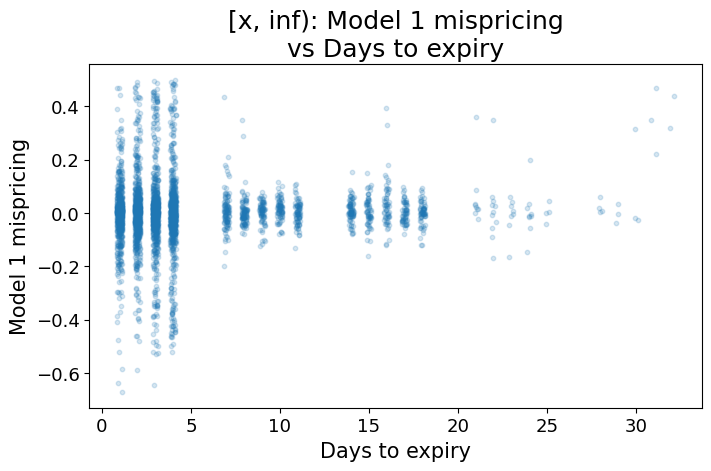

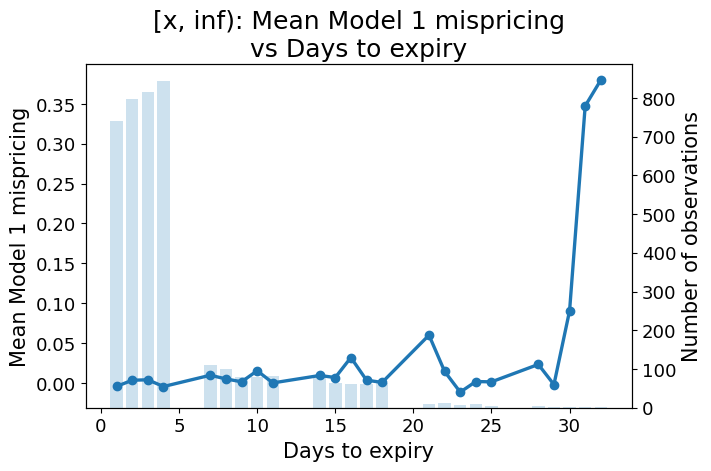

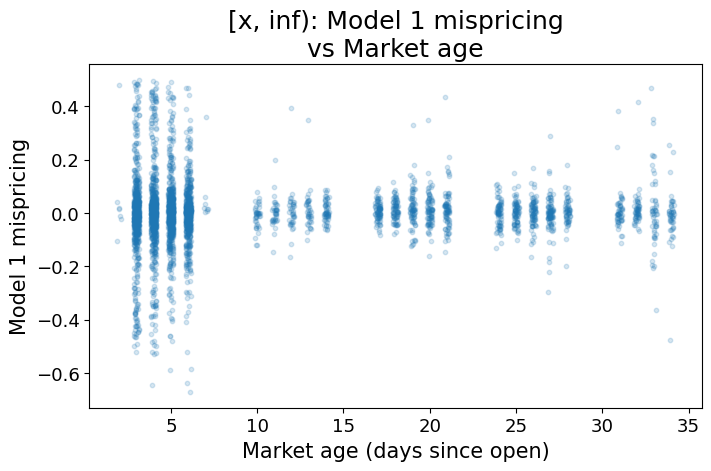

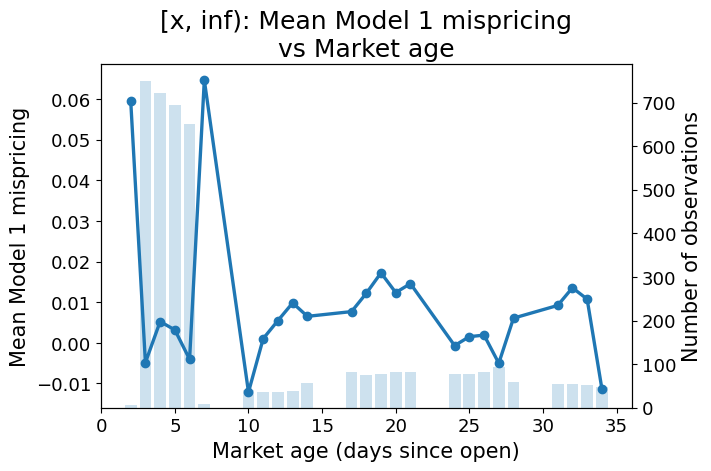

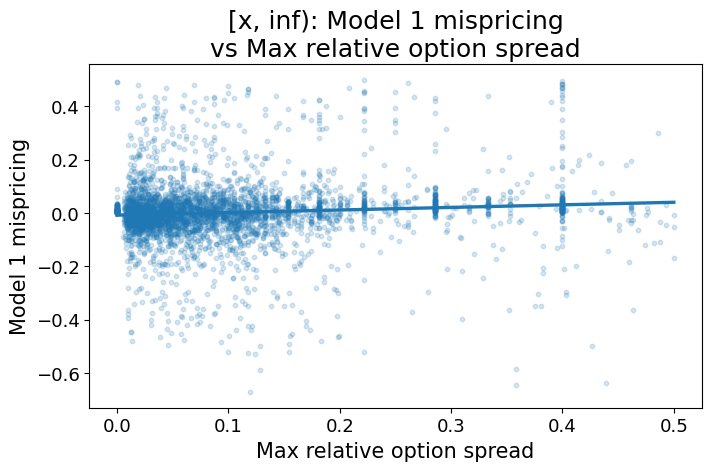

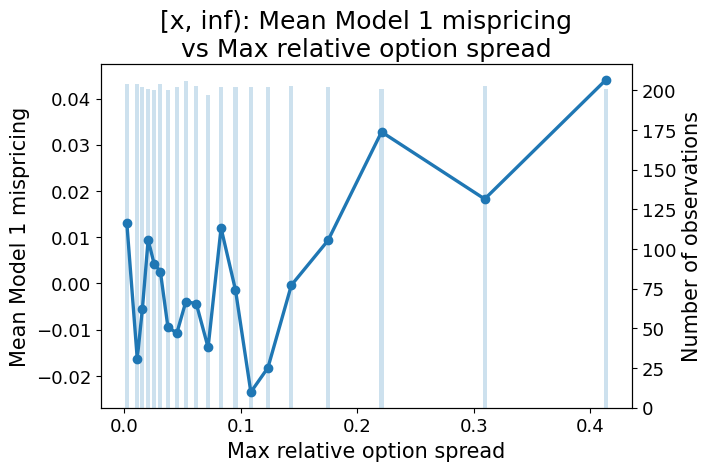

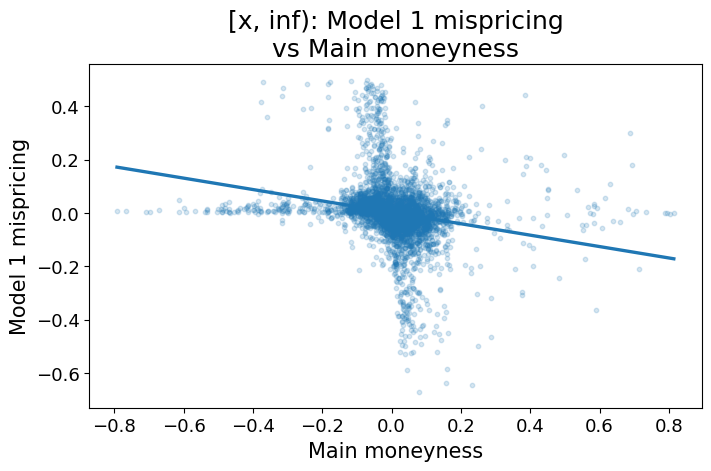

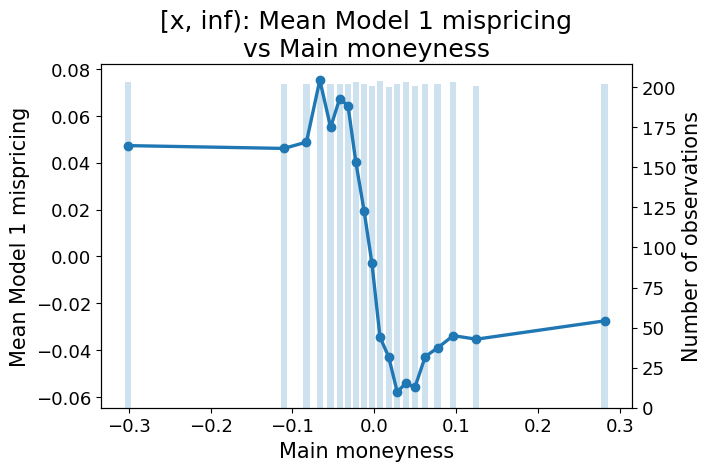

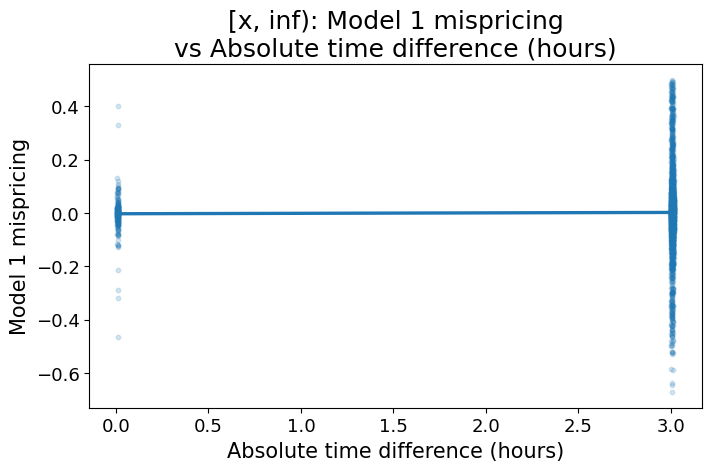

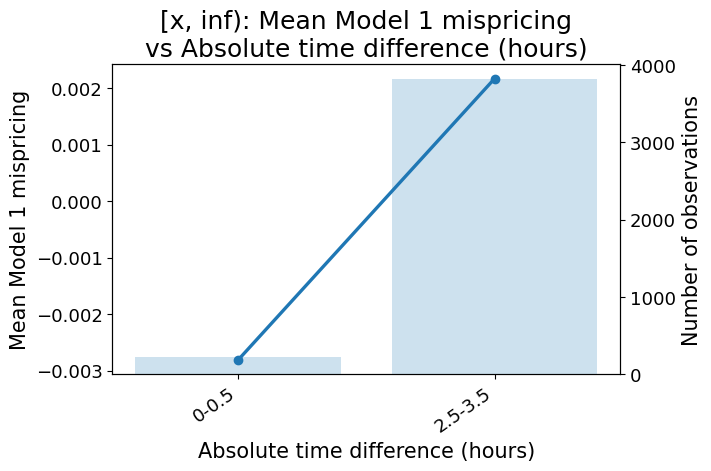

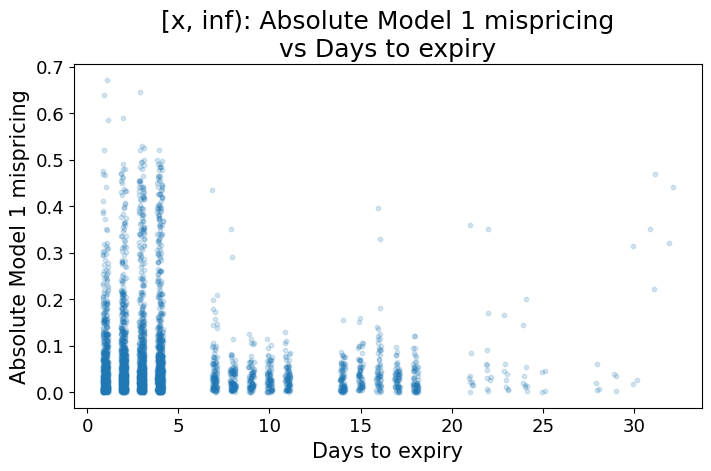

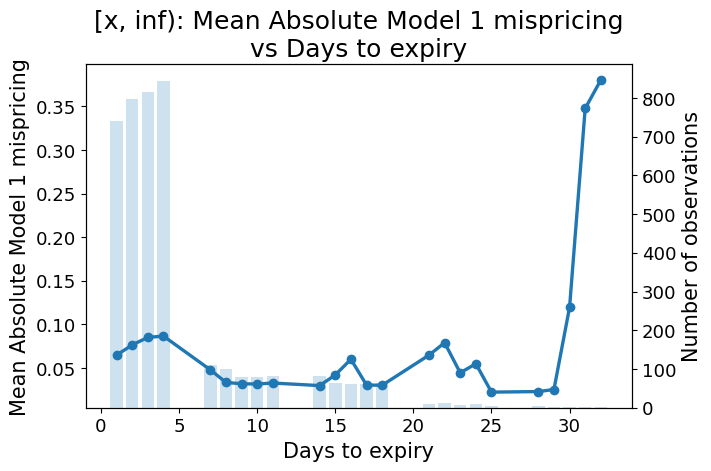

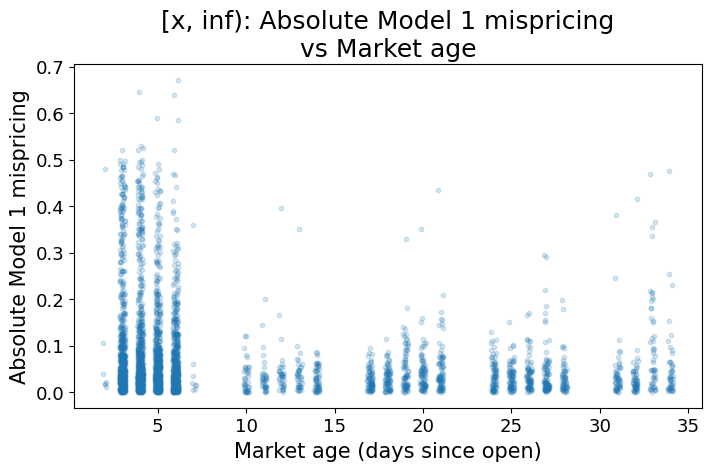

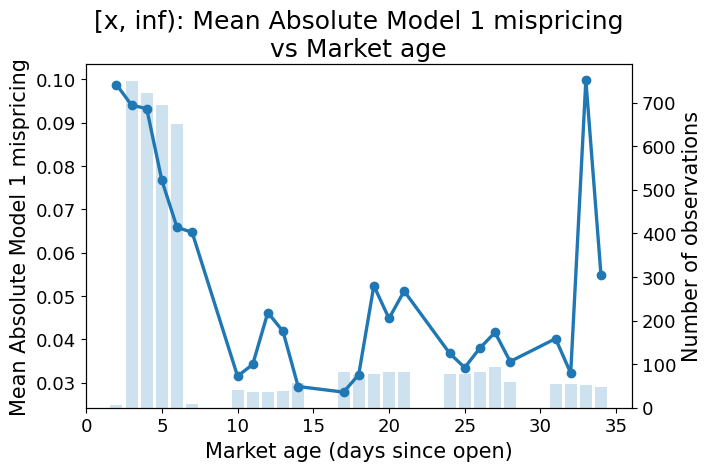

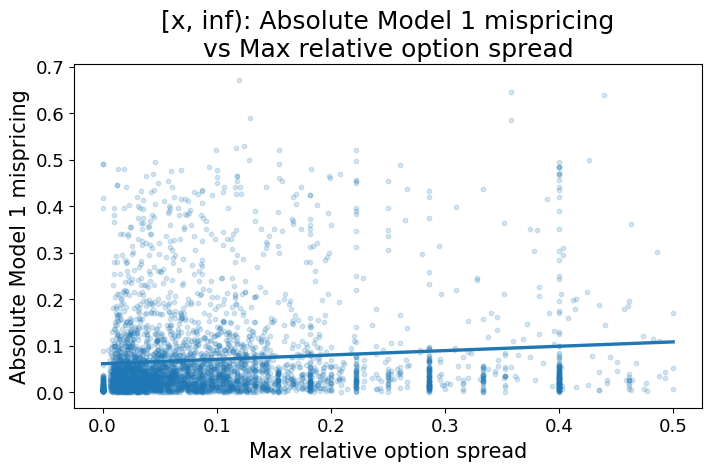

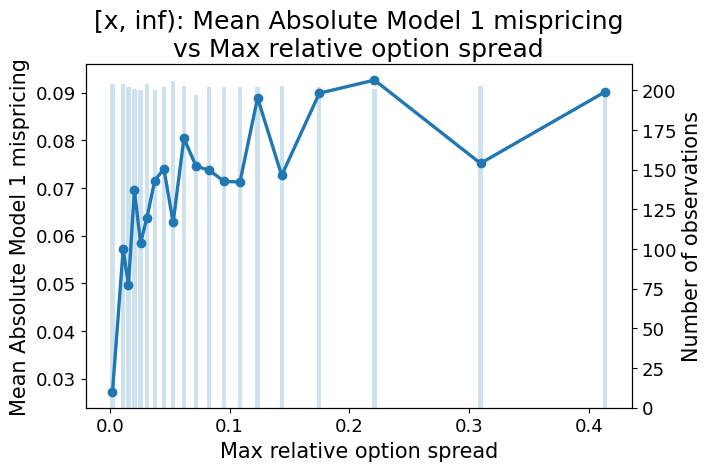

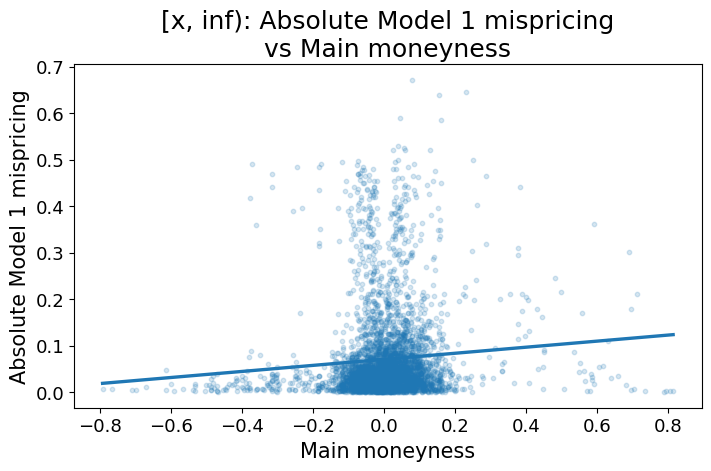

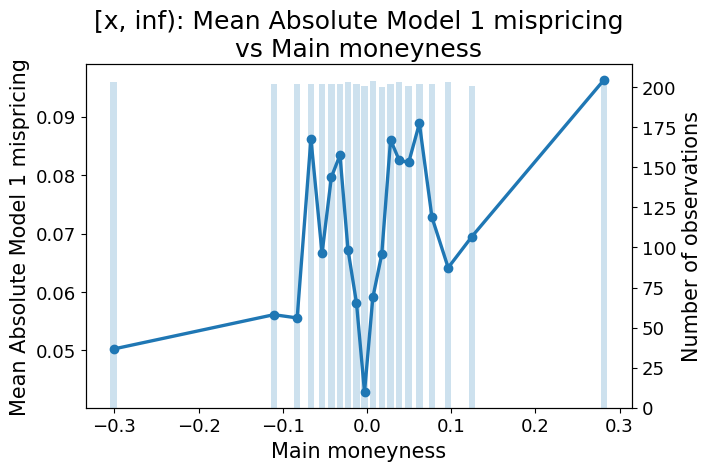

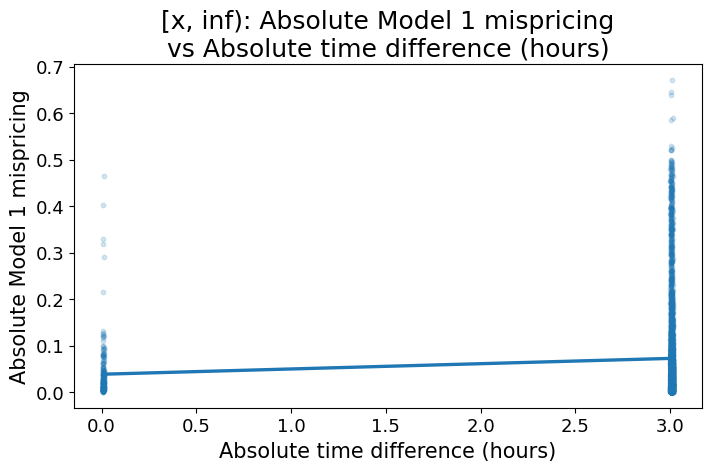

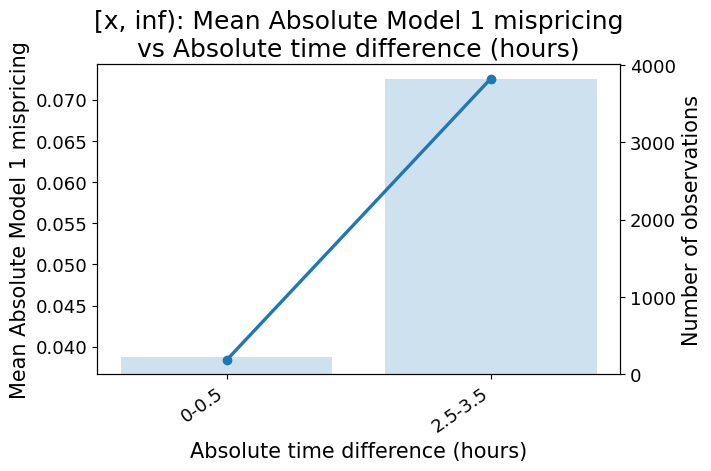

Saved:
- section2_univariate_outputs/tables/s2_x_inf_regression_results.csv
- section2_univariate_outputs/tables/s2_x_inf_binned_results.csv
- section2_univariate_outputs/tables/s2_x_inf_sample_sizes.csv


In [17]:
# --------------------------------------------------
# Run section 2 for [x, inf)
# --------------------------------------------------

section2_x_inf = run_section2_univariate(
    df=base_sample,
    interval_type="[x, inf)",
    y_specs=Y_SPECS,
    x_specs=X_SPECS,
    plot_dir=PLOT_DIR,
    table_dir=TABLE_DIR,
    prefix="s2"
)

In [18]:
# --------------------------------------------------
# Inspect stored results
# --------------------------------------------------

print("Sample sizes:")
display(section2_x_inf["sample_df"])

print("\nRegression results:")
display(section2_x_inf["regression_df"])

print("\nBinned/discrete summaries (first 5 rows):")
display(section2_x_inf["binned_df"].head(5))

Sample sizes:


,interval_type,x_col,y_col,n_obs
0,"[x, inf)",tau_days,mispricing_m1_pm_minus_model1,4041
1,"[x, inf)",market_age_days,mispricing_m1_pm_minus_model1,4041
2,"[x, inf)",max_rel_opt_spread,mispricing_m1_pm_minus_model1,4041
3,"[x, inf)",main_moneyness,mispricing_m1_pm_minus_model1,4041
4,"[x, inf)",abs_diff_hours,mispricing_m1_pm_minus_model1,4041
5,"[x, inf)",tau_days,abs_mispricing_m1,4041
6,"[x, inf)",market_age_days,abs_mispricing_m1,4041
7,"[x, inf)",max_rel_opt_spread,abs_mispricing_m1,4041
8,"[x, inf)",main_moneyness,abs_mispricing_m1,4041
9,"[x, inf)",abs_diff_hours,abs_mispricing_m1,4041



Regression results:


,interval_type,x_col,y_col,n_obs,intercept,slope,se_intercept_hc1,se_slope_hc1,t_slope,p_slope,r2
0,"[x, inf)",max_rel_opt_spread,mispricing_m1_pm_minus_model1,4041,-0.007951,0.096284,0.002457,0.020808,4.627201,3.706403e-06,0.007134
1,"[x, inf)",main_moneyness,mispricing_m1_pm_minus_model1,4041,0.002476,-0.213596,0.001830,0.018729,-11.404634,3.964428e-30,0.046206
2,"[x, inf)",abs_diff_hours,mispricing_m1_pm_minus_model1,4041,-0.002806,0.001655,0.004730,0.001703,0.971815,3.311425e-01,0.000090
3,"[x, inf)",max_rel_opt_spread,abs_mispricing_m1,4041,0.061090,0.093859,0.001982,0.017196,5.458061,4.813617e-08,0.010426
4,"[x, inf)",main_moneyness,abs_mispricing_m1,4041,0.070515,0.065150,0.001509,0.013065,4.986457,6.149644e-07,0.006612
5,"[x, inf)",abs_diff_hours,abs_mispricing_m1,4041,0.038440,0.011347,0.003971,0.001421,7.986860,1.384187e-15,0.006505



Binned/discrete summaries (first 5 rows):


,x_value,y_mean,y_median,y_std,n_obs,interval_type,x_col,y_col,plot_type,bin,x_mean,x_min,x_max
0,1.0,-0.004415,0.003,0.108256,740,"[x, inf)",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
1,2.0,0.003295,0.004,0.121298,797,"[x, inf)",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
2,3.0,0.003855,0.005,0.142607,815,"[x, inf)",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
3,4.0,-0.004614,-0.002,0.142361,844,"[x, inf)",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
4,7.0,0.009573,0.005,0.074338,110,"[x, inf)",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN


Running section 2 for [0, x]
Sample shape: (236, 37)


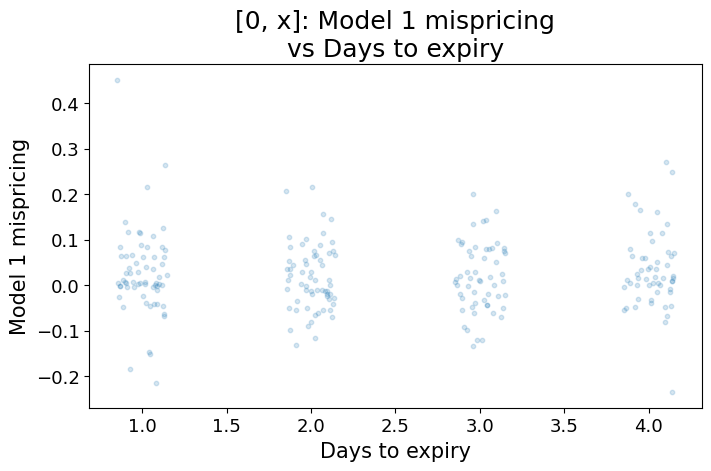

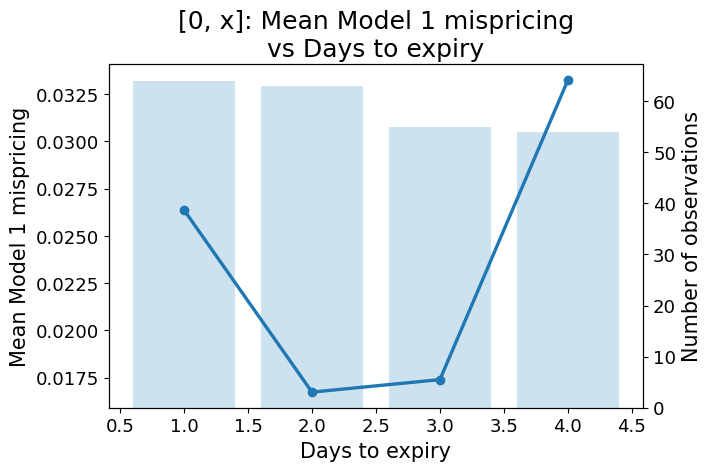

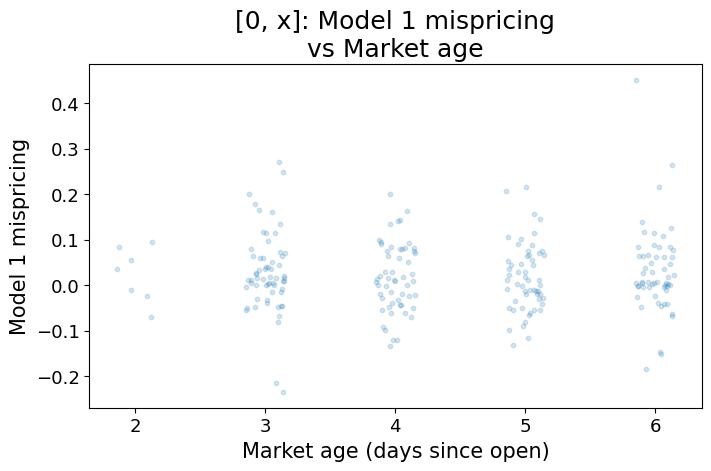

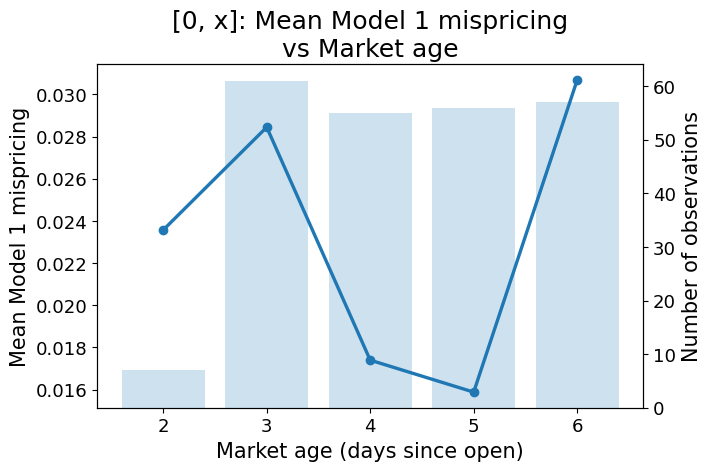

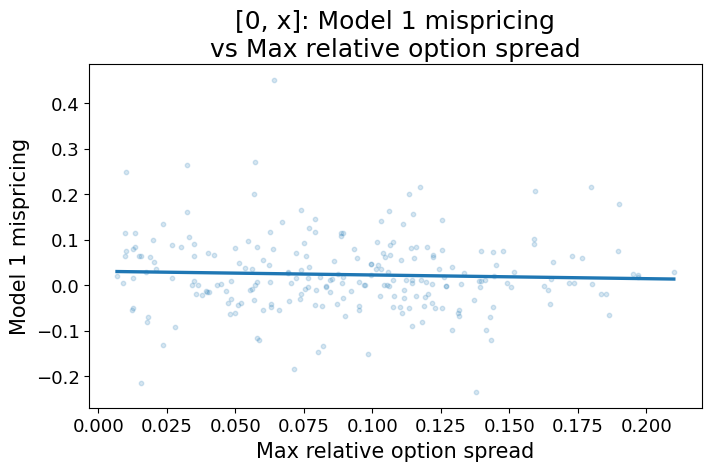

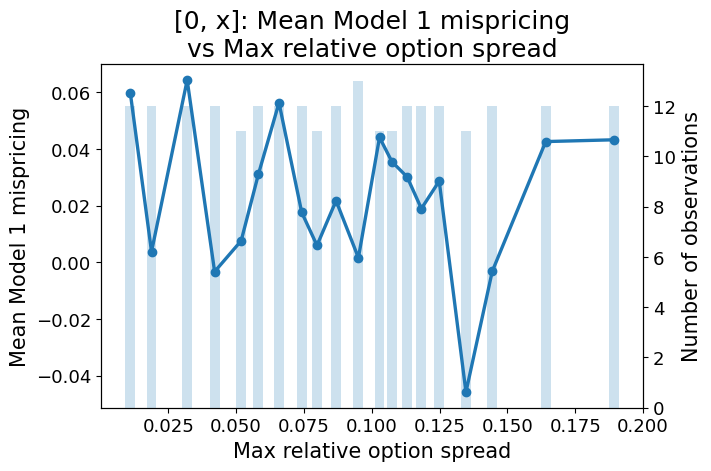

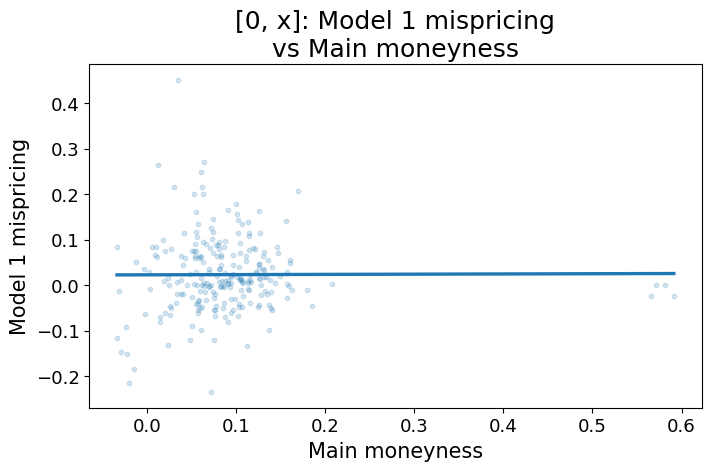

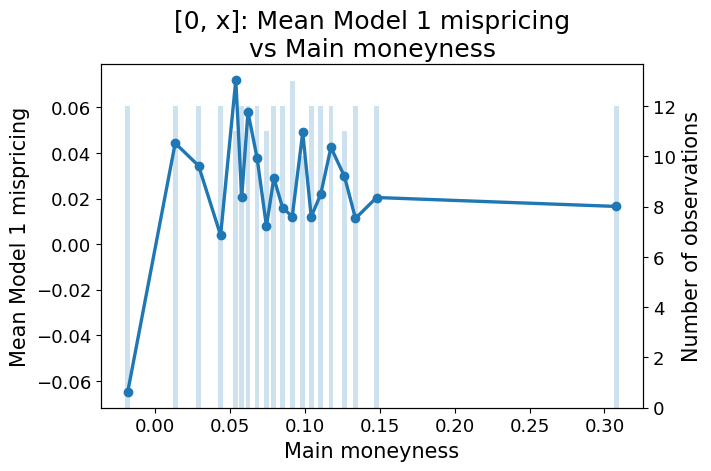

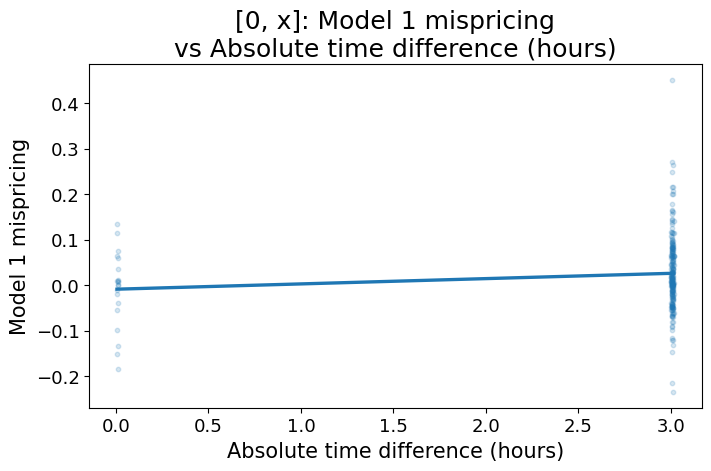

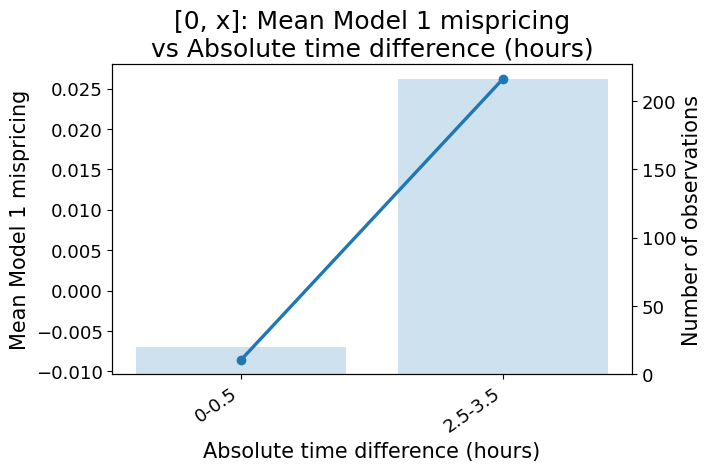

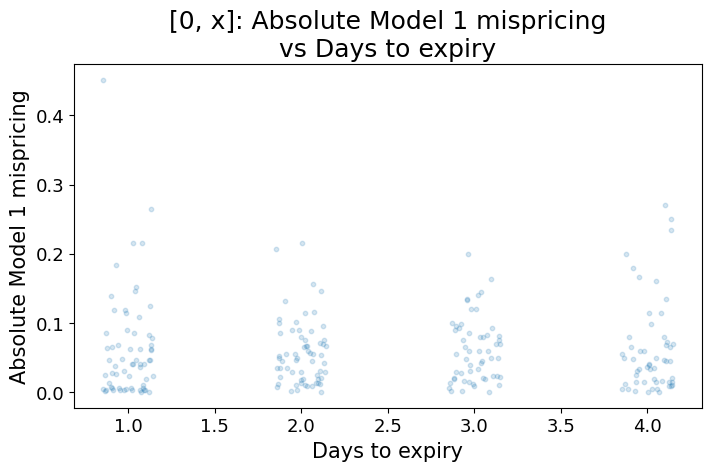

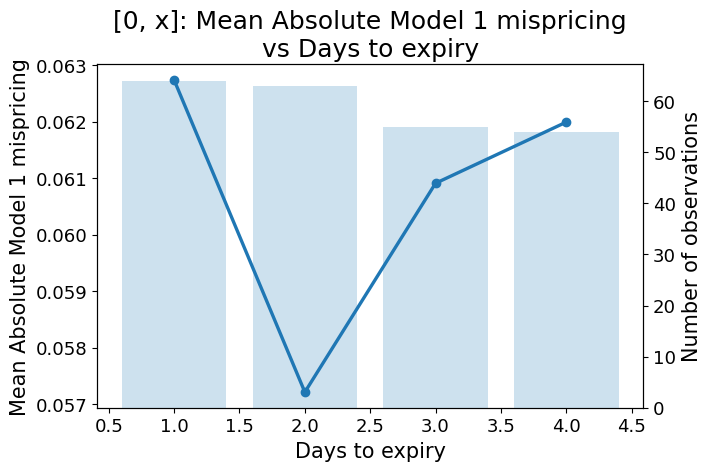

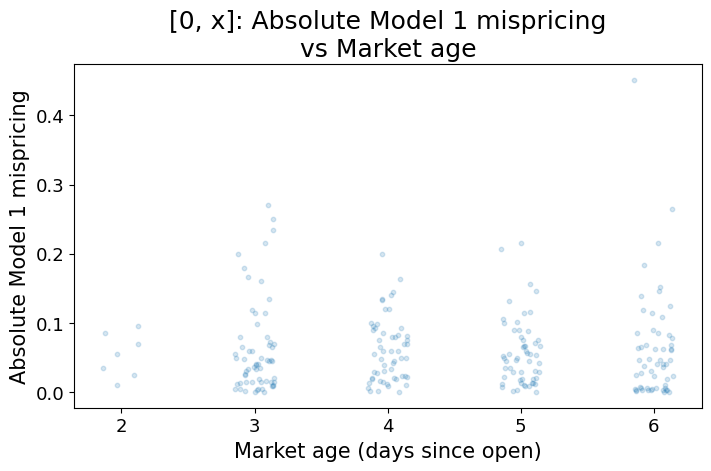

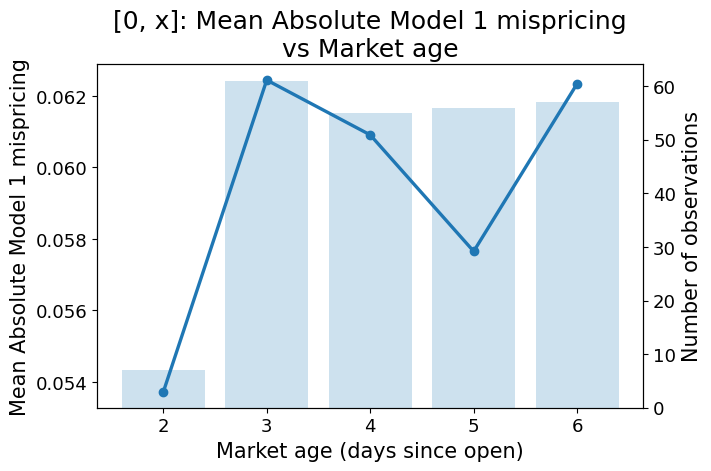

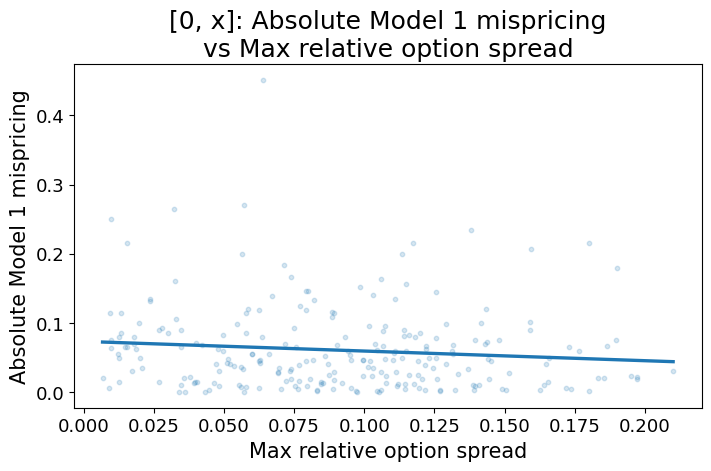

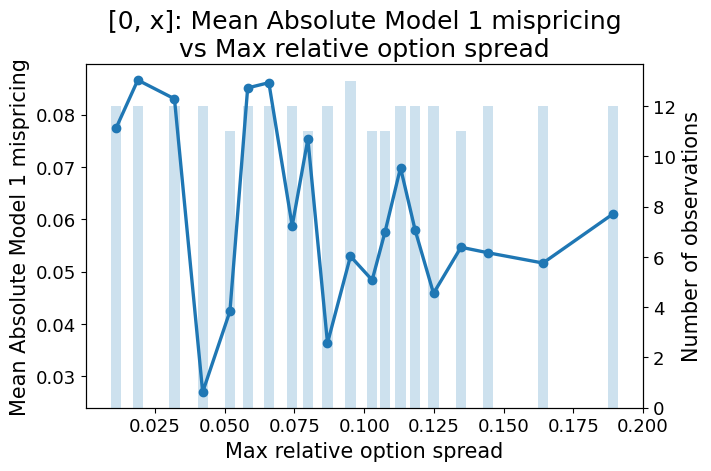

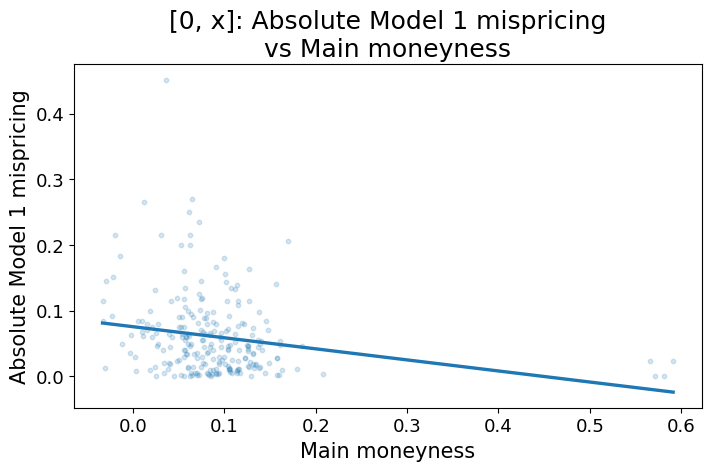

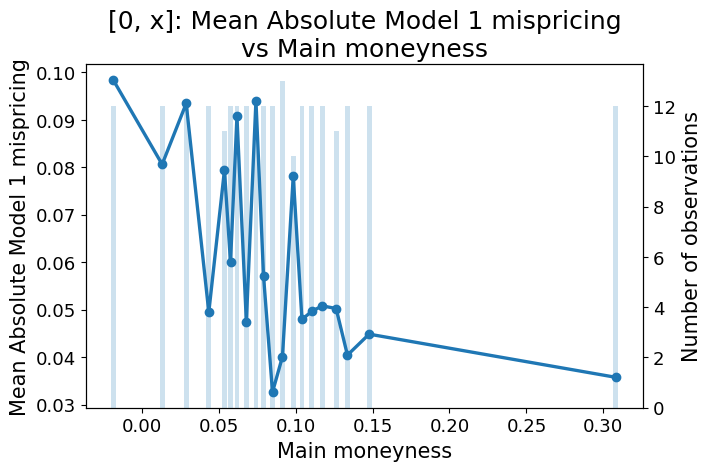

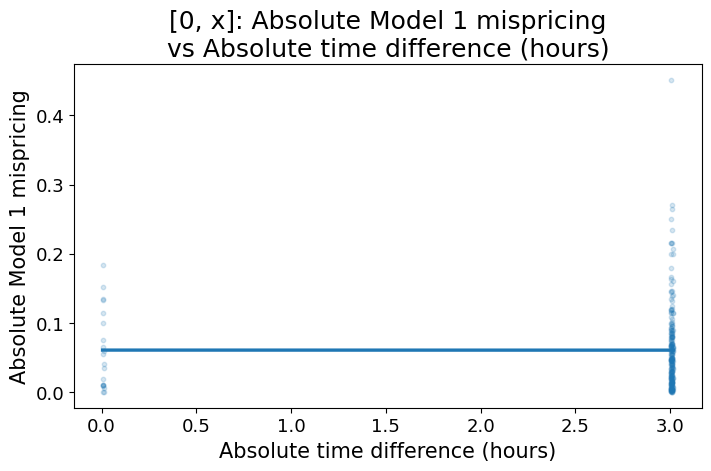

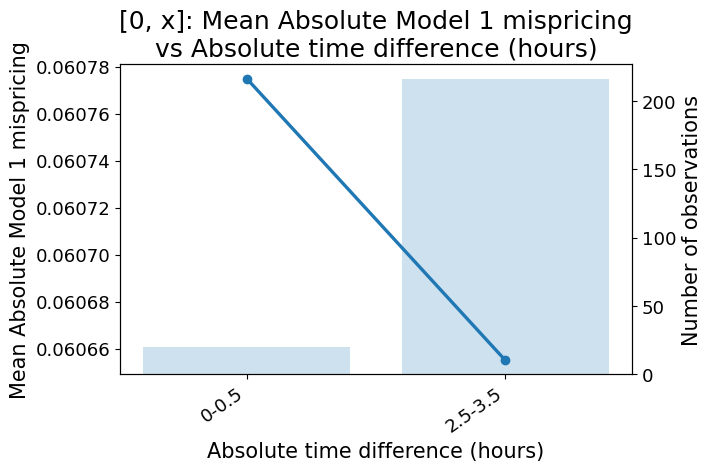

Saved:
- section2_univariate_outputs/tables/s2_0_x_regression_results.csv
- section2_univariate_outputs/tables/s2_0_x_binned_results.csv
- section2_univariate_outputs/tables/s2_0_x_sample_sizes.csv


In [19]:
section2_0_x = run_section2_univariate(
    df=base_sample,
    interval_type="[0, x]",
    y_specs=Y_SPECS,
    x_specs=X_SPECS,
    plot_dir=PLOT_DIR,
    table_dir=TABLE_DIR,
    prefix="s2"
)

In [20]:
# --------------------------------------------------
# Inspect stored results
# --------------------------------------------------

print("Sample sizes:")
display(section2_0_x["sample_df"])

print("\nRegression results:")
display(section2_0_x["regression_df"])

print("\nBinned/discrete summaries (first 5 rows):")
display(section2_0_x["binned_df"].head(5))

Sample sizes:


,interval_type,x_col,y_col,n_obs
0,"[0, x]",tau_days,mispricing_m1_pm_minus_model1,236
1,"[0, x]",market_age_days,mispricing_m1_pm_minus_model1,236
2,"[0, x]",max_rel_opt_spread,mispricing_m1_pm_minus_model1,236
3,"[0, x]",main_moneyness,mispricing_m1_pm_minus_model1,236
4,"[0, x]",abs_diff_hours,mispricing_m1_pm_minus_model1,236
5,"[0, x]",tau_days,abs_mispricing_m1,236
6,"[0, x]",market_age_days,abs_mispricing_m1,236
7,"[0, x]",max_rel_opt_spread,abs_mispricing_m1,236
8,"[0, x]",main_moneyness,abs_mispricing_m1,236
9,"[0, x]",abs_diff_hours,abs_mispricing_m1,236



Regression results:


,interval_type,x_col,y_col,n_obs,intercept,slope,se_intercept_hc1,se_slope_hc1,t_slope,p_slope,r2
0,"[0, x]",max_rel_opt_spread,mispricing_m1_pm_minus_model1,236,0.030644,-0.081184,0.012497,0.114853,-0.706855,0.479657,2.156341e-03
1,"[0, x]",main_moneyness,mispricing_m1_pm_minus_model1,236,0.022853,0.004824,0.008877,0.056354,0.085604,0.931782,2.088114e-05
2,"[0, x]",abs_diff_hours,mispricing_m1_pm_minus_model1,236,-0.008742,0.011631,0.018479,0.006420,1.811617,0.070045,1.392149e-02
3,"[0, x]",max_rel_opt_spread,abs_mispricing_m1,236,0.073316,-0.139536,0.009017,0.083309,-1.674924,0.093949,1.185963e-02
4,"[0, x]",main_moneyness,abs_mispricing_m1,236,0.075686,-0.168317,0.006079,0.039934,-4.214858,0.000025,4.732584e-02
5,"[0, x]",abs_diff_hours,abs_mispricing_m1,236,0.060748,-0.000030,0.012563,0.004400,-0.006791,0.994581,1.710682e-07



Binned/discrete summaries (first 5 rows):


,x_value,y_mean,y_median,y_std,n_obs,interval_type,x_col,y_col,plot_type,bin,x_mean,x_min,x_max
0,1.0,0.026375,0.00650,0.096018,64,"[0, x]",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
1,2.0,0.016738,0.01100,0.072249,63,"[0, x]",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
2,3.0,0.017400,0.01150,0.074830,55,"[0, x]",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
3,4.0,0.033250,0.01575,0.084963,54,"[0, x]",tau_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN
4,2.0,0.023571,0.03500,0.061058,7,"[0, x]",market_age_days,mispricing_m1_pm_minus_model1,discrete_mean_count,NaN,NaN,NaN,NaN


## Key observations from Section 2 and recommended reporting choices

### Main sample: `[x, inf)`

The univariate results for `[x, inf)` show several clear patterns.

**1. Moneyness is one of the strongest correlates of mispricing.**
- In the simple robust regression of signed Model 1 mispricing on `main_moneyness`, the slope is clearly negative and highly statistically significant.
- In the regression of absolute Model 1 mispricing on `main_moneyness`, the slope is positive and also highly significant.
- The binned mean plots show the same broad pattern.
- Interpretation: when the PM boundary becomes more extreme relative to the underlying stock price, both the direction and magnitude of mispricing change systematically.

**2. Option illiquidity is strongly associated with larger mispricing.**
- Using `max_rel_opt_spread` as the measure of option illiquidity, both signed and absolute Model 1 mispricing increase with spread.
- The effect is statistically strong in the main sample.
- Interpretation: when option quotes are wider and less reliable, the option-based benchmark becomes less precise, and observed PM-option differences become larger.

**3. Timing mismatch is associated more with absolute mispricing than with signed mispricing.**
- For `abs_diff_hours`, the regression relationship is weak for signed mispricing.
- But the relationship is positive for absolute mispricing.
- Interpretation: greater timing mismatch mainly increases pricing noise rather than shifting PM prices consistently in one direction.

**4. Days to expiry and market age are useful descriptively, but their tails should not be over-interpreted.**
- The day-based mean plots show some variation over `tau_days` and `market_age_days`.
- However, the number of observations falls sharply in the long-horizon tail.
- Therefore these variables are worth showing descriptively, but extreme-tail patterns should not be emphasized.

### Supplementary sample: `[0, x]`

The `[0, x]` sample is much smaller, so results are naturally less stable.

**1. Most relationships are weaker and noisier than in `[x, inf)`.**
- Signed mispricing shows little robust relation with spread or moneyness.
- The timing result is at most marginal.

**2. The clearest supplementary result is moneyness for absolute mispricing.**
- Absolute Model 1 mispricing is significantly related to `main_moneyness`.
- This is the one `[0, x]` result most worth retaining in the report.

### Recommended reporting choices

Based on the current results, the most useful Section 2 figures/tables for the main report are:

**For `[x, inf)`**
1. signed mispricing vs `main_moneyness`
2. absolute mispricing vs `max_rel_opt_spread`
3. absolute mispricing vs `abs_diff_hours`
4. one descriptive day-based plot:
   - either `tau_days`
   - or `market_age_days`

**For `[0, x]`**
- keep the analysis supplementary
- if included, the most informative item is:
  - absolute mispricing vs `main_moneyness`

### Bottom line

Section 2 supports three main messages:

1. **Moneyness is a strong correlate of mispricing**
2. **Option illiquidity is associated with larger PM-option differences**
3. **Timing mismatch mainly increases noise, not direction**

These findings provide a clean transition into the next section on model comparison.

In [21]:
# ============================================================
# Thesis-style 2x2 mispricing plots:
# scatter + fitted line + binned mean + observation-count bars
# LARGER FONTS FOR THESIS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------------
# 0. Choose sample
# ------------------------------------------------------------
if "analysis_sample" in globals():
    plot_base = analysis_sample.copy()
elif "final_sample" in globals():
    plot_base = final_sample.copy()
else:
    plot_base = pd.read_csv("final_sample.csv")

plot_df = plot_base.loc[plot_base["interval_type"] == "[x, inf)"].copy()

print("Plot sample shape:", plot_df.shape)
display(plot_df["interval_type"].value_counts(dropna=False))


# ------------------------------------------------------------
# 1. Binning helper
# ------------------------------------------------------------
def make_binned_stats(
    df,
    x_col,
    y_col,
    binning="quantile",
    n_bins=12,
    custom_bins=None,
    min_count=1
):
    temp = df[[x_col, y_col]].dropna().copy()
    temp = temp[np.isfinite(temp[x_col]) & np.isfinite(temp[y_col])].copy()

    if temp.empty:
        return pd.DataFrame(columns=["x_plot", "y_mean", "n_obs"])

    if binning == "discrete":
        out = (
            temp.groupby(x_col)[y_col]
            .agg(y_mean="mean", n_obs="size")
            .reset_index()
            .rename(columns={x_col: "x_plot"})
            .sort_values("x_plot")
        )

    else:
        if binning == "custom":
            temp["bin"] = pd.cut(temp[x_col], bins=custom_bins, include_lowest=True)
        elif binning == "equal":
            temp["bin"] = pd.cut(temp[x_col], bins=n_bins)
        else:
            temp["bin"] = pd.qcut(temp[x_col], q=n_bins, duplicates="drop")

        out = (
            temp.groupby("bin", observed=True)
            .agg(
                x_plot=(x_col, "mean"),
                y_mean=(y_col, "mean"),
                n_obs=(y_col, "size")
            )
            .reset_index(drop=True)
            .sort_values("x_plot")
        )

    out = out.loc[out["n_obs"] >= min_count].copy()
    return out


# ------------------------------------------------------------
# 2. Robust OLS fitted line helper
# ------------------------------------------------------------
def robust_fit_line(df, x_col, y_col, n_grid=100):
    temp = df[[x_col, y_col]].dropna().copy()
    temp = temp[np.isfinite(temp[x_col]) & np.isfinite(temp[y_col])].copy()

    if temp.shape[0] < 5 or temp[x_col].nunique() < 2:
        return None, None

    X = sm.add_constant(temp[x_col])
    y = temp[y_col]
    model = sm.OLS(y, X).fit(cov_type="HC1")

    x_grid = np.linspace(temp[x_col].min(), temp[x_col].max(), n_grid)
    X_grid = sm.add_constant(pd.Series(x_grid, name=x_col))
    y_grid = model.predict(X_grid)

    return x_grid, y_grid


# ------------------------------------------------------------
# 3. Single panel helper
# ------------------------------------------------------------
def draw_one_panel(
    ax,
    df,
    x_col,
    y_col,
    x_label,
    y_label,
    title,
    binning="quantile",
    n_bins=12,
    custom_bins=None,
    add_fit=True,
    scatter_alpha=0.12,
    title_fontsize=18,
    axis_label_fontsize=15,
    tick_fontsize=13,
    right_axis_fontsize=13,
    right_tick_fontsize=11,
):
    temp = df[[x_col, y_col]].dropna().copy()
    temp = temp[np.isfinite(temp[x_col]) & np.isfinite(temp[y_col])].copy()

    if temp.empty:
        ax.text(0.5, 0.5, "No valid data", ha="center", va="center", transform=ax.transAxes, fontsize=16)
        ax.set_title(title, fontsize=title_fontsize)
        return

    # Raw scatter
    ax.scatter(
        temp[x_col],
        temp[y_col],
        s=14,
        alpha=scatter_alpha,
        linewidths=0
    )

    # Fitted line
    if add_fit:
        x_fit, y_fit = robust_fit_line(temp, x_col, y_col)
        if x_fit is not None:
            ax.plot(x_fit, y_fit, linewidth=2.4)

    # Binned means
    binned = make_binned_stats(
        temp,
        x_col=x_col,
        y_col=y_col,
        binning=binning,
        n_bins=n_bins,
        custom_bins=custom_bins
    )

    if not binned.empty:
        ax.plot(
            binned["x_plot"],
            binned["y_mean"],
            marker="o",
            linewidth=2.6,
            markersize=5
        )

        # Observation-count bars on secondary axis
        ax2 = ax.twinx()

        x_vals = binned["x_plot"].values
        if len(x_vals) > 1:
            bar_width = 0.65 * np.median(np.diff(np.sort(x_vals)))
            if not np.isfinite(bar_width) or bar_width <= 0:
                bar_width = 0.1
        else:
            bar_width = 0.1

        ax2.bar(
            binned["x_plot"],
            binned["n_obs"],
            width=bar_width,
            alpha=0.08
        )
        ax2.set_ylabel("Number of observations", fontsize=right_axis_fontsize)
        ax2.tick_params(axis="y", labelsize=right_tick_fontsize)

    if "signed" in title.lower():
        ax.axhline(0, linewidth=1.2)

    ax.set_title(title, fontsize=title_fontsize, pad=8)
    ax.set_xlabel(x_label, fontsize=axis_label_fontsize)
    ax.set_ylabel(y_label, fontsize=axis_label_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(alpha=0.25)


# ------------------------------------------------------------
# 4. 2x2 figure helper
# ------------------------------------------------------------
def plot_four_panel_variable(
    df,
    x_col,
    x_label,
    file_stub,
    binning="quantile",
    n_bins=12,
    custom_bins=None,
    add_fit=True,
    output_dir="thesis_figures/four_panel_mispricing",
    sample_label="[x, inf) sample"
):
    panels = [
        ("mispricing_m1_pm_minus_model1", "Method 1 signed mispricing", "Signed mispricing"),
        ("mispricing_m3_pm_minus_model3", "Method 3 signed mispricing", "Signed mispricing"),
        ("abs_mispricing_m1", "Method 1 absolute mispricing", "Absolute mispricing"),
        ("abs_mispricing_m3", "Method 3 absolute mispricing", "Absolute mispricing"),
    ]

    # Larger canvas
    fig, axes = plt.subplots(2, 2, figsize=(18, 13))
    axes = axes.flatten()

    for ax, (y_col, title, y_label) in zip(axes, panels):
        draw_one_panel(
            ax=ax,
            df=df,
            x_col=x_col,
            y_col=y_col,
            x_label=x_label,
            y_label=y_label,
            title=title,
            binning=binning,
            n_bins=n_bins,
            custom_bins=custom_bins,
            add_fit=add_fit,
            scatter_alpha=0.12,
            title_fontsize=18,
            axis_label_fontsize=15,
            tick_fontsize=13,
            right_axis_fontsize=13,
            right_tick_fontsize=11,
        )

    fig.suptitle(
        f"{x_label} and Polymarket Mispricing ({sample_label})",
        fontsize=24,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"{file_stub}_four_panel.png")
    plt.savefig(out_path, dpi=400, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
    return out_path

Plot sample shape: (4041, 37)


interval_type
[x, inf)    4041
Name: count, dtype: int64

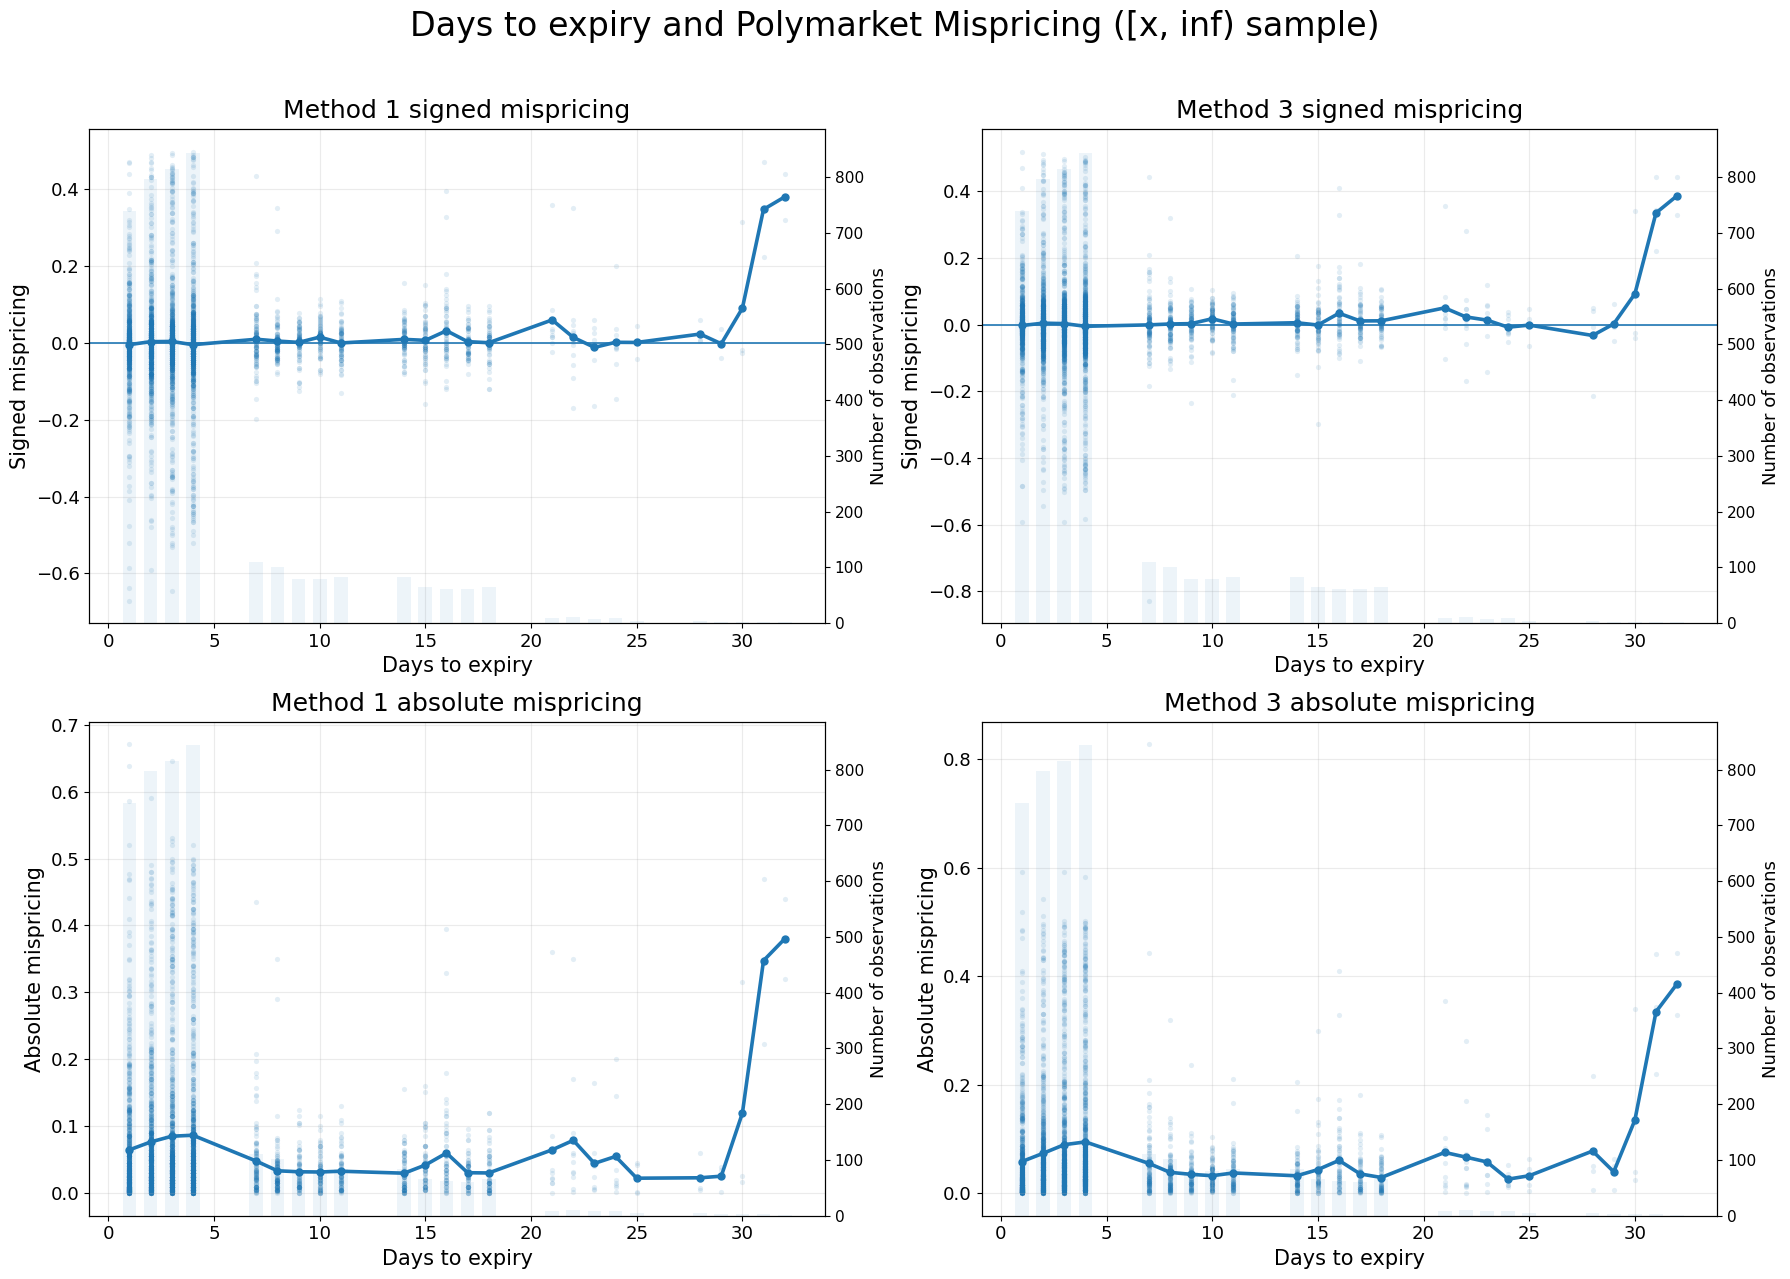

Saved: thesis_figures/four_panel_mispricing/tau_days_four_panel.png


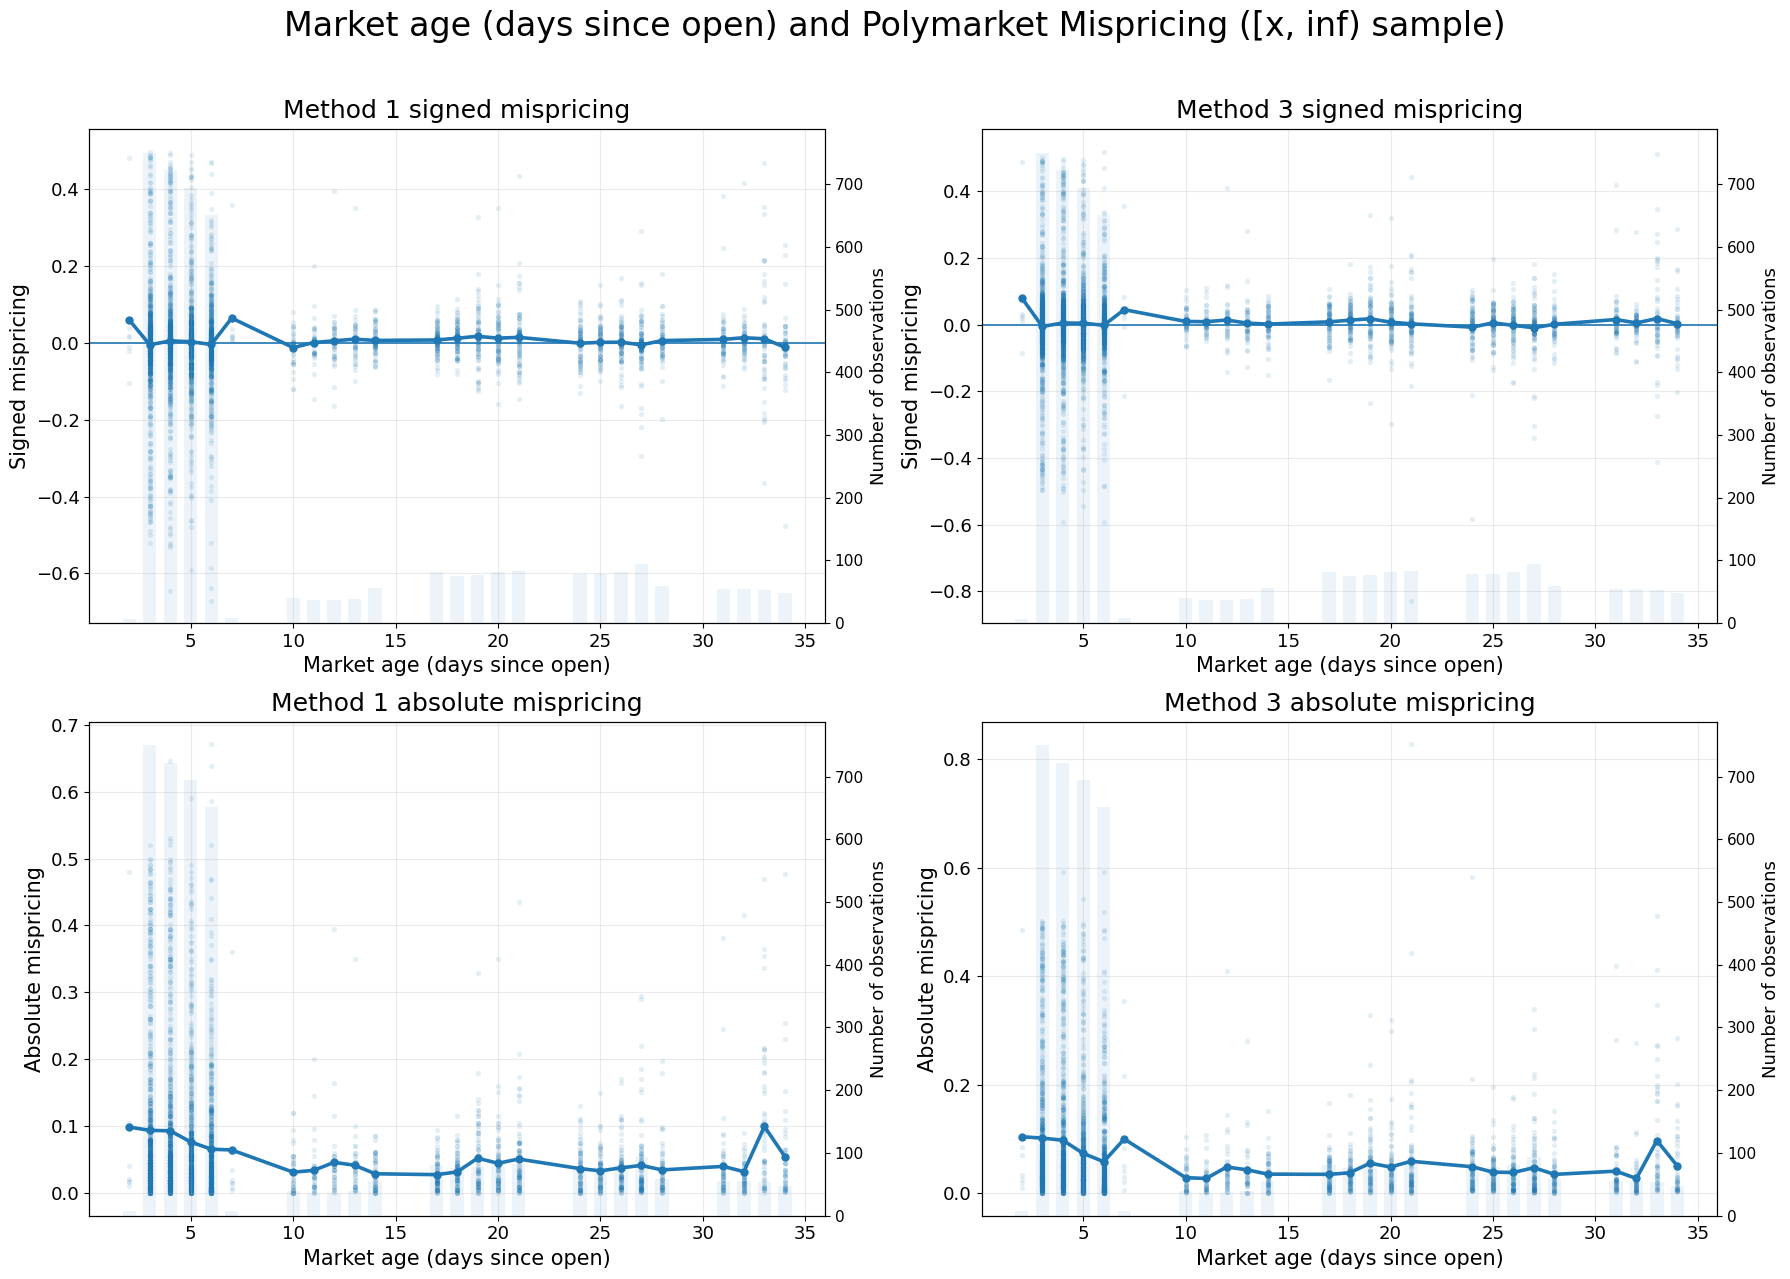

Saved: thesis_figures/four_panel_mispricing/market_age_days_four_panel.png


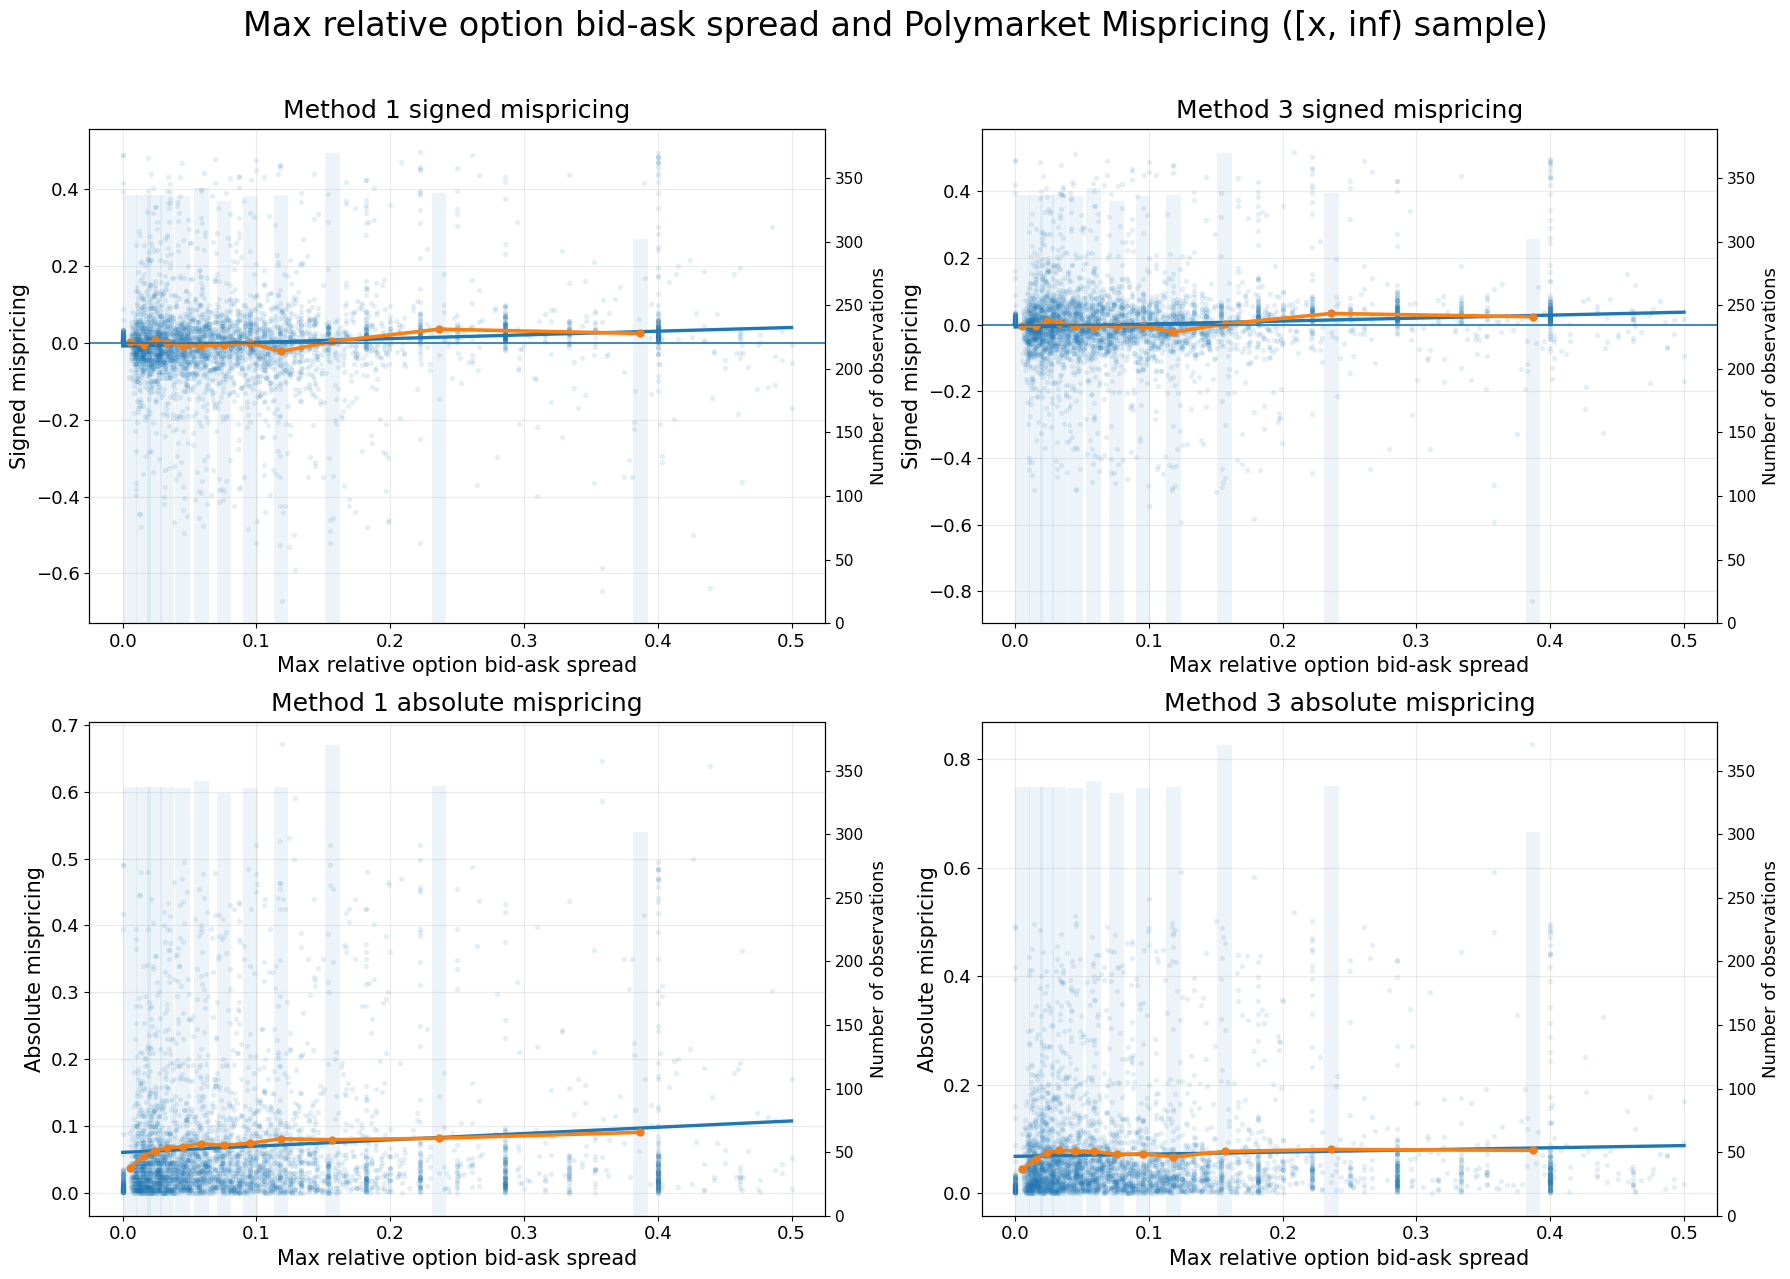

Saved: thesis_figures/four_panel_mispricing/max_rel_opt_spread_four_panel.png


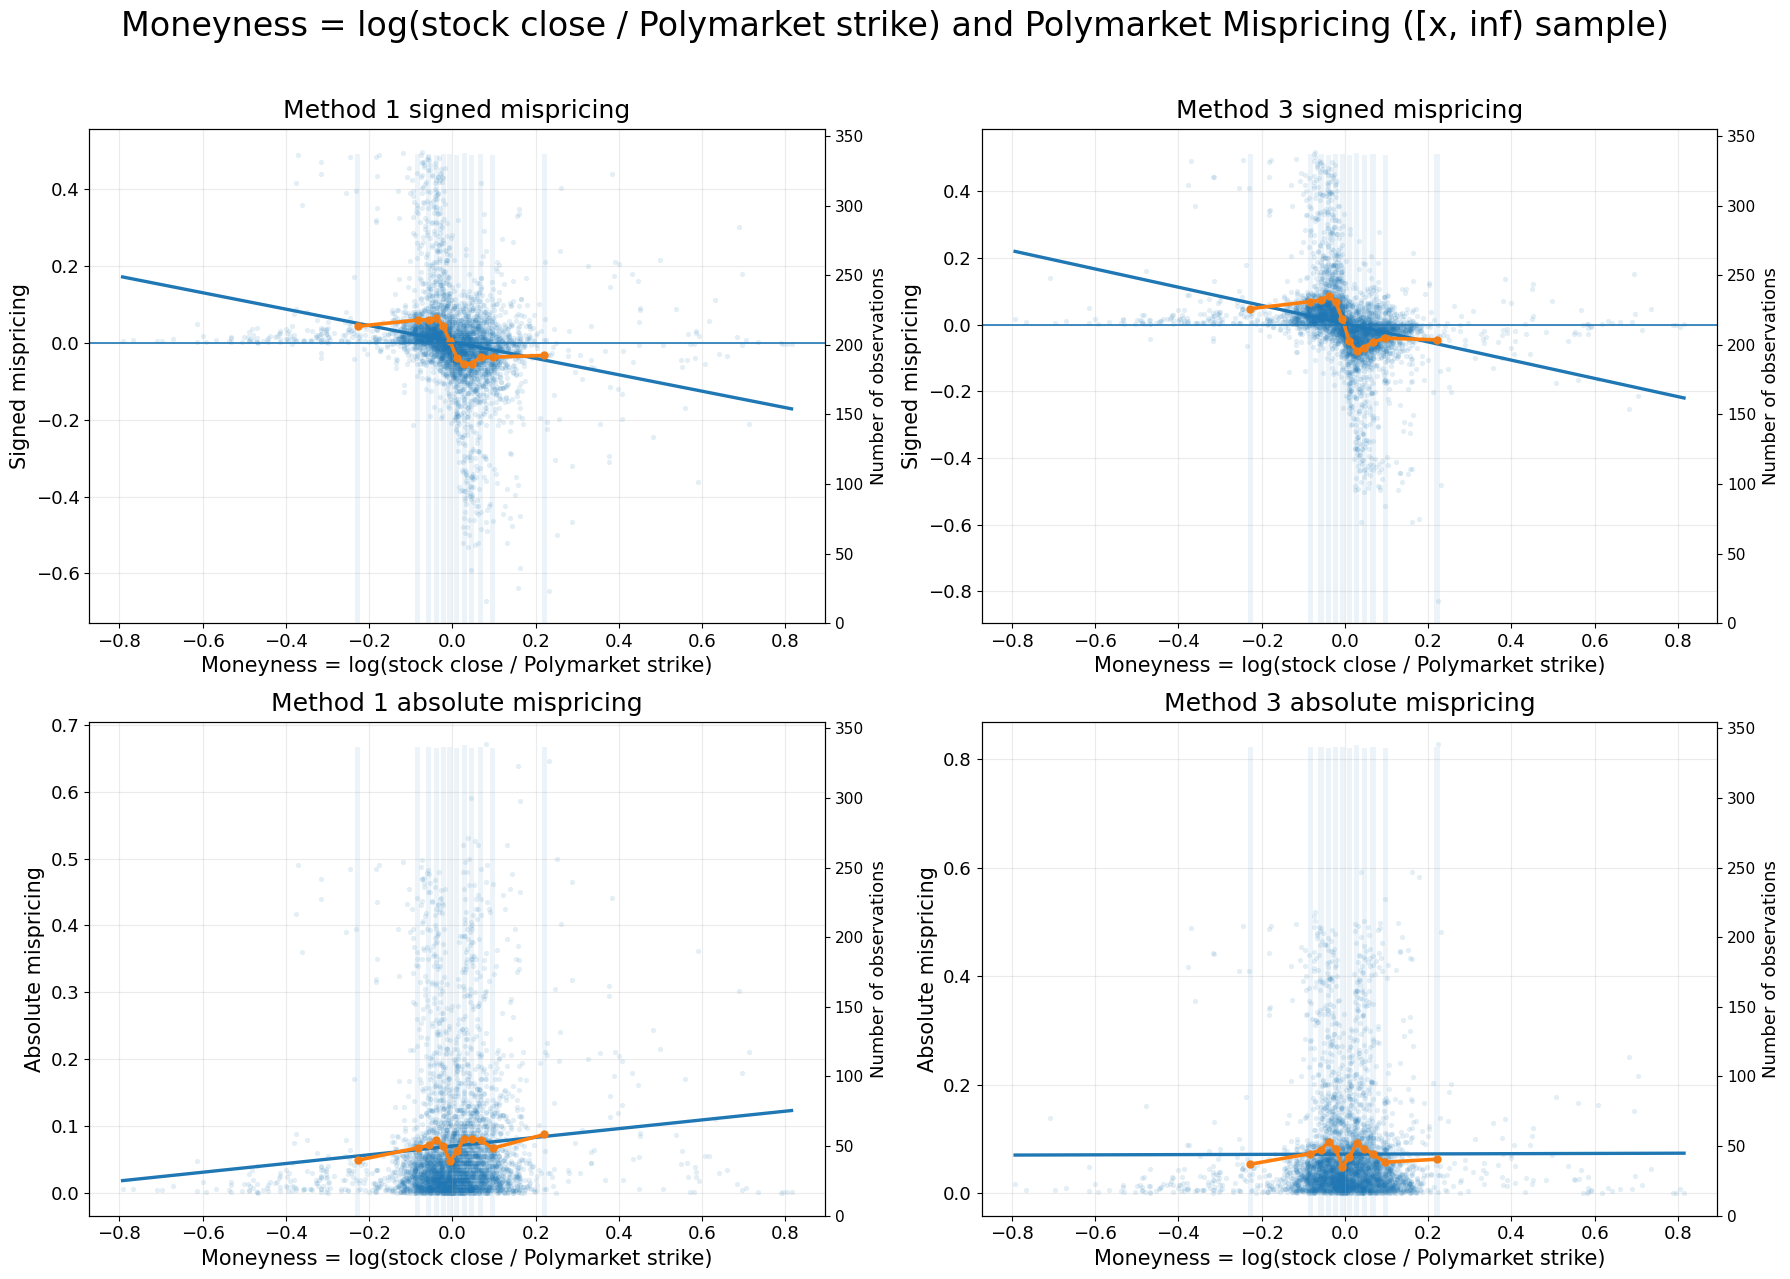

Saved: thesis_figures/four_panel_mispricing/main_moneyness_four_panel.png


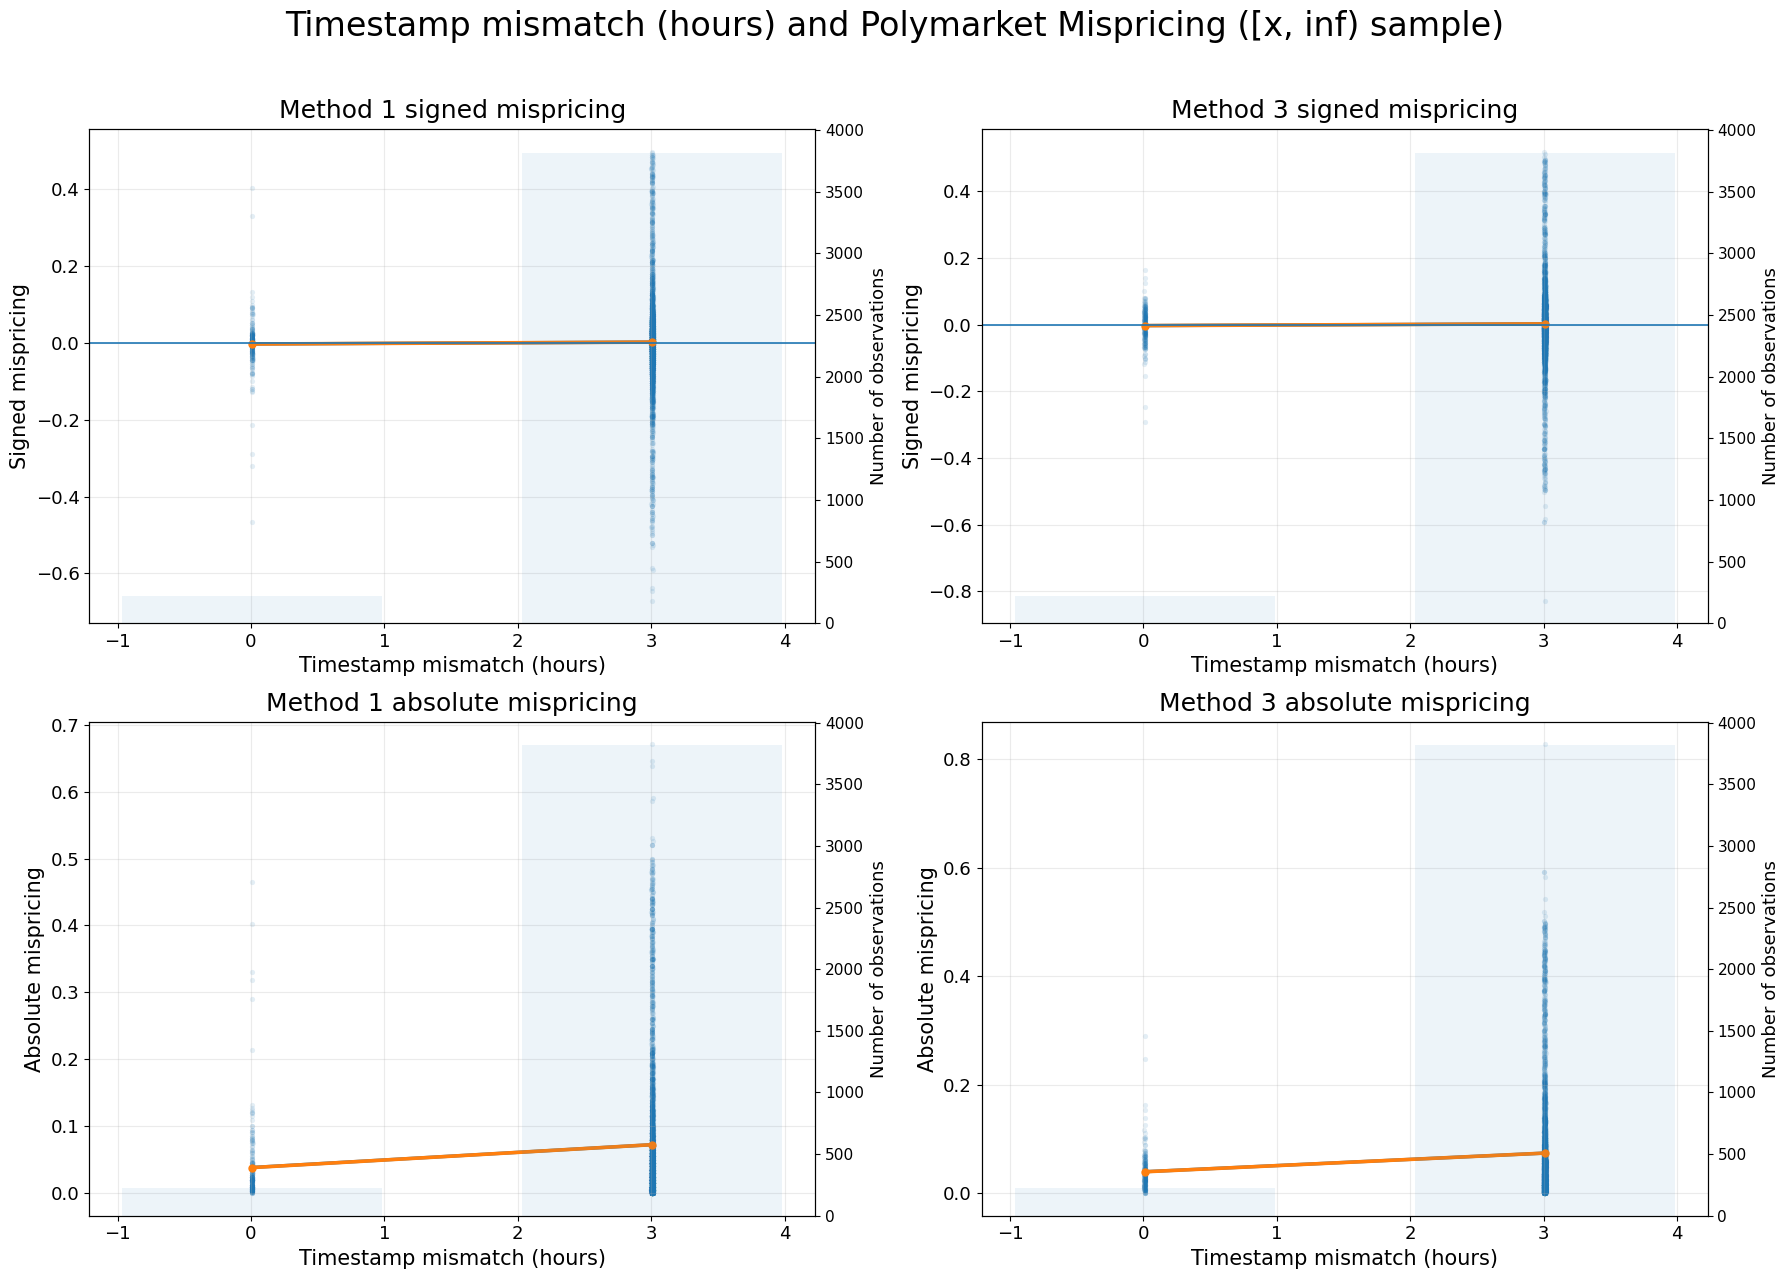

Saved: thesis_figures/four_panel_mispricing/abs_diff_hours_four_panel.png

All saved files:
thesis_figures/four_panel_mispricing/tau_days_four_panel.png
thesis_figures/four_panel_mispricing/market_age_days_four_panel.png
thesis_figures/four_panel_mispricing/max_rel_opt_spread_four_panel.png
thesis_figures/four_panel_mispricing/main_moneyness_four_panel.png
thesis_figures/four_panel_mispricing/abs_diff_hours_four_panel.png


In [22]:
saved_paths = []

saved_paths.append(
    plot_four_panel_variable(
        df=plot_df,
        x_col="tau_days",
        x_label="Days to expiry",
        file_stub="tau_days",
        binning="discrete",
        add_fit=False
    )
)

saved_paths.append(
    plot_four_panel_variable(
        df=plot_df,
        x_col="market_age_days",
        x_label="Market age (days since open)",
        file_stub="market_age_days",
        binning="discrete",
        add_fit=False
    )
)

saved_paths.append(
    plot_four_panel_variable(
        df=plot_df,
        x_col="max_rel_opt_spread",
        x_label="Max relative option bid-ask spread",
        file_stub="max_rel_opt_spread",
        binning="quantile",
        n_bins=12,
        add_fit=True
    )
)

saved_paths.append(
    plot_four_panel_variable(
        df=plot_df,
        x_col="main_moneyness",
        x_label="Moneyness = log(stock close / Polymarket strike)",
        file_stub="main_moneyness",
        binning="quantile",
        n_bins=12,
        add_fit=True
    )
)

abs_diff_bins = [-0.01, 0.5, 1.5, 2.5, 3.5, 6.5]

saved_paths.append(
    plot_four_panel_variable(
        df=plot_df,
        x_col="abs_diff_hours",
        x_label="Timestamp mismatch (hours)",
        file_stub="abs_diff_hours",
        binning="custom",
        custom_bins=abs_diff_bins,
        add_fit=True
    )
)

print("\nAll saved files:")
for p in saved_paths:
    print(p)

## 3. Model comparison

This section compares the three pricing models on the final common sample.

Main components:

1. Choose a representative market from `[x, inf)` and plot:
   - PM price
   - Model 1 price
   - Model 3 price
   - Model 2 range

2. Compare Model 1 and Model 3 mispricing across observations:
   - signed mispricing
   - absolute mispricing
   - summary tables and distribution plots

3. Summarize Model 2 as an interval benchmark:
   - inside-range share
   - below-range share
   - above-range share
   - range width

All outputs are saved for later use in the report.

In [23]:
# --------------------------------------------------
# Choose working sample and output folders
# --------------------------------------------------

if "analysis_sample" in globals():
    s3_sample = analysis_sample.copy()
else:
    s3_sample = final_sample.copy()

SECTION3_DIR = "section3_model_comparison_outputs"
S3_PLOT_DIR = os.path.join(SECTION3_DIR, "plots")
S3_TABLE_DIR = os.path.join(SECTION3_DIR, "tables")

os.makedirs(S3_PLOT_DIR, exist_ok=True)
os.makedirs(S3_TABLE_DIR, exist_ok=True)

print("s3_sample shape:", s3_sample.shape)
print("Plot folder :", S3_PLOT_DIR)
print("Table folder:", S3_TABLE_DIR)

s3_sample shape: (6136, 37)
Plot folder : section3_model_comparison_outputs/plots
Table folder: section3_model_comparison_outputs/tables


### 3.1 Choose a representative `[x, inf)` market

We rank candidate markets using:
- longer valid history
- lower median option spread
- lower mean absolute Model 1 mispricing

This gives a short list of representative markets for plotting.

In [24]:
# --------------------------------------------------
# Representative market selection
# Prefer markets with longer history, moderate PM prices,
# tighter spreads, and lower abs mispricing
# --------------------------------------------------

def build_market_candidate_table(df, interval_type="[x, inf)"):
    temp = df.loc[df["interval_type"] == interval_type].copy()

    cand = (
        temp.groupby(["pm_market_id", "stock_ticker", "event_id", "event_slug", "event_title"])
        .agg(
            n_obs=("date", "size"),
            date_min=("date", "min"),
            date_max=("date", "max"),
            median_pm_price=("pm_price_yes", "median"),
            mean_pm_price=("pm_price_yes", "mean"),
            median_tau_days=("tau_days", "median"),
            median_market_age_days=("market_age_days", "median"),
            median_max_rel_opt_spread=("max_rel_opt_spread", "median"),
            mean_abs_mispricing_m1=("abs_mispricing_m1", "mean"),
            mean_abs_mispricing_m3=("abs_mispricing_m3", "mean"),
            mean_model2_range_width=("model2_range_width", "mean"),
            mean_pm_inside_model2_range=("pm_inside_model2_range", "mean"),
            mean_abs_diff_hours=("abs_diff_hours", "mean"),
        )
        .reset_index()
    )

    # Distance from the center 0.5; smaller is better
    cand["dist_from_0_5"] = (cand["median_pm_price"] - 0.5).abs()

    # Prefer long history, moderate PM prices, tighter spreads, lower abs mispricing
    cand["rank_n_obs"] = cand["n_obs"].rank(method="min", ascending=False)
    cand["rank_center"] = cand["dist_from_0_5"].rank(method="min", ascending=True)
    cand["rank_spread"] = cand["median_max_rel_opt_spread"].rank(method="min", ascending=True)
    cand["rank_abs_m1"] = cand["mean_abs_mispricing_m1"].rank(method="min", ascending=True)

    cand["representative_score"] = (
        0.45 * cand["rank_n_obs"] +
        0.30 * cand["rank_center"] +
        0.15 * cand["rank_spread"] +
        0.10 * cand["rank_abs_m1"]
    )

    # Main preferred band: avoid markets too close to 0 or 1
    preferred = cand.loc[
        cand["median_pm_price"].between(0.20, 0.80, inclusive="both")
    ].copy()

    if len(preferred) > 0:
        out = preferred.sort_values(
            ["representative_score", "n_obs", "dist_from_0_5"],
            ascending=[True, False, True]
        ).reset_index(drop=True)
    else:
        out = cand.sort_values(
            ["representative_score", "n_obs", "dist_from_0_5"],
            ascending=[True, False, True]
        ).reset_index(drop=True)

    return out

candidate_markets_x_inf = build_market_candidate_table(s3_sample, interval_type="[x, inf)")

display(candidate_markets_x_inf.head(20))

candidate_markets_x_inf.to_csv(
    os.path.join(S3_TABLE_DIR, "s3_candidate_markets_x_inf.csv"),
    index=False
)
print("Saved: s3_candidate_markets_x_inf.csv")

,pm_market_id,stock_ticker,event_id,event_slug,event_title,n_obs,date_min,date_max,median_pm_price,mean_pm_price,median_tau_days,median_market_age_days,median_max_rel_opt_spread,mean_abs_mispricing_m1,mean_abs_mispricing_m3,mean_model2_range_width,mean_pm_inside_model2_range,mean_abs_diff_hours,dist_from_0_5,rank_n_obs,rank_center,rank_spread,rank_abs_m1,representative_score
0,1301882,NVDA,193977,nvda-above-in-february-2026,Will NVIDIA (NVDA) close above ___ end of Febr...,14,2026-02-09,2026-02-26,0.4800,0.479643,9.5,18.5,0.019618,0.022357,0.030058,0.035429,0.571429,3.005099,0.0200,8.0,25.0,129.0,160.0,46.45
1,1031713,TSLA,125816,tsla-above-in-january-2026,Will Tesla (TSLA) close above ___ end of January?,14,2026-01-12,2026-01-29,0.4950,0.476929,9.5,25.5,0.012442,0.043929,0.045807,0.058286,0.571429,3.008433,0.0050,8.0,9.0,72.0,409.0,58.00
2,1301834,TSLA,193971,tsla-above-in-february-2026,Will Tesla (TSLA) close above ___ end of Febru...,14,2026-02-09,2026-02-26,0.5650,0.547500,9.5,18.5,0.012232,0.036143,0.027553,0.056714,0.571429,3.010694,0.0650,8.0,73.0,70.0,327.0,68.70
3,1301737,GOOGL,193955,googl-above-in-february-2026,Will Google (GOOGL) close above ___ end of Feb...,14,2026-02-09,2026-02-26,0.5050,0.506429,9.5,18.5,0.046905,0.025071,0.028096,0.129000,0.714286,3.007877,0.0050,8.0,9.0,318.0,193.0,73.30
4,1031759,NVDA,125819,nvda-above-in-january-2026,Will NVIDIA (NVDA) close above ___ end of Janu...,14,2026-01-12,2026-01-29,0.4100,0.414286,9.5,25.5,0.018525,0.031786,0.043633,0.019000,0.142857,3.004544,0.0900,8.0,106.0,116.0,267.0,79.50
5,1031715,TSLA,125816,tsla-above-in-january-2026,Will Tesla (TSLA) close above ___ end of January?,14,2026-01-12,2026-01-29,0.3950,0.367536,9.5,25.5,0.012175,0.034536,0.037716,0.051143,0.500000,3.006012,0.1050,8.0,120.0,69.0,305.0,80.45
6,1031572,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,14,2026-01-12,2026-01-29,0.4800,0.450143,9.5,25.5,0.017651,0.062214,0.057458,0.097286,0.571429,3.008254,0.0200,8.0,25.0,104.0,555.0,82.20
7,1301837,TSLA,193971,tsla-above-in-february-2026,Will Tesla (TSLA) close above ___ end of Febru...,14,2026-02-09,2026-02-26,0.4075,0.389643,9.5,18.5,0.013544,0.040071,0.039397,0.038857,0.428571,3.007996,0.0925,8.0,107.0,78.0,363.0,83.70
8,1031685,META,125813,meta-above-in-january-2026,Will Meta (META) close above ___ end of January?,14,2026-01-12,2026-01-29,0.4825,0.543107,9.5,25.5,0.019046,0.070107,0.041478,0.409286,1.000000,3.009960,0.0175,8.0,23.0,121.0,605.0,89.15
9,1301776,META,193963,meta-above-in-february-2026,Will Meta (META) close above ___ end of February?,14,2026-02-09,2026-02-26,0.5950,0.636071,9.5,18.5,0.017755,0.042857,0.032156,0.189286,0.857143,3.006667,0.0950,8.0,113.0,106.0,400.0,93.40


Saved: s3_candidate_markets_x_inf.csv


Choose one market from the candidate table above.

By default, the first row is used automatically, but this can be changed manually.

In [25]:
# --------------------------------------------------
# Pick two representative markets
# --------------------------------------------------

# Default choice: top 2 ranked candidates
#chosen_market_ids = candidate_markets_x_inf["pm_market_id"].head(2).astype(int).tolist()

# If you want to override manually later, replace chosen_market_ids above.

chosen_market_ids = [1301882, 1031572]

chosen_market_meta = candidate_markets_x_inf.loc[
    candidate_markets_x_inf["pm_market_id"].isin(chosen_market_ids)
].copy()

display(chosen_market_meta)

chosen_market_dfs = {}
for mid in chosen_market_ids:
    chosen_market_dfs[mid] = (
        s3_sample.loc[s3_sample["pm_market_id"] == mid]
        .sort_values("date")
        .copy()
    )

for mid in chosen_market_ids:
    print(f"\nChosen market {mid} rows:", len(chosen_market_dfs[mid]))
    display(
        chosen_market_dfs[mid][
            [
                "pm_market_id", "date", "stock_ticker", "event_slug", "interval_type",
                "pm_price_yes", "model1_price", "model2_low", "model2_high", "model3_price",
                "abs_mispricing_m1", "abs_mispricing_m3", "tau_days", "market_age_days",
                "max_rel_opt_spread"
            ]
        ]
    )

,pm_market_id,stock_ticker,event_id,event_slug,event_title,n_obs,date_min,date_max,median_pm_price,mean_pm_price,median_tau_days,median_market_age_days,median_max_rel_opt_spread,mean_abs_mispricing_m1,mean_abs_mispricing_m3,mean_model2_range_width,mean_pm_inside_model2_range,mean_abs_diff_hours,dist_from_0_5,rank_n_obs,rank_center,rank_spread,rank_abs_m1,representative_score
0,1301882,NVDA,193977,nvda-above-in-february-2026,Will NVIDIA (NVDA) close above ___ end of Febr...,14,2026-02-09,2026-02-26,0.48,0.479643,9.5,18.5,0.019618,0.022357,0.030058,0.035429,0.571429,3.005099,0.02,8.0,25.0,129.0,160.0,46.45
6,1031572,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,14,2026-01-12,2026-01-29,0.48,0.450143,9.5,25.5,0.017651,0.062214,0.057458,0.097286,0.571429,3.008254,0.02,8.0,25.0,104.0,555.0,82.20



Chosen market 1301882 rows: 14


,pm_market_id,date,stock_ticker,event_slug,interval_type,pm_price_yes,model1_price,model2_low,model2_high,model3_price,abs_mispricing_m1,abs_mispricing_m3,tau_days,market_age_days,max_rel_opt_spread
4401,1301882,2026-02-09,NVDA,nvda-above-in-february-2026,"[x, inf)",0.520,0.520,0.490,0.55,0.519961,1.110223e-16,0.000039,18,10,0.020067
4423,1301882,2026-02-10,NVDA,nvda-above-in-february-2026,"[x, inf)",0.465,0.490,0.470,0.51,0.499374,2.500000e-02,0.034374,17,11,0.015873
4445,1301882,2026-02-11,NVDA,nvda-above-in-february-2026,"[x, inf)",0.515,0.530,0.510,0.55,0.538747,1.500000e-02,0.023747,16,12,0.014599
4467,1301882,2026-02-12,NVDA,nvda-above-in-february-2026,"[x, inf)",0.465,0.475,0.460,0.49,0.484987,1.000000e-02,0.019987,15,13,0.012422
4490,1301882,2026-02-13,NVDA,nvda-above-in-february-2026,"[x, inf)",0.365,0.380,0.360,0.40,0.384149,1.500000e-02,0.019149,14,14,0.026667
4496,1301882,2026-02-16,NVDA,nvda-above-in-february-2026,"[x, inf)",0.345,0.380,0.360,0.40,0.363119,3.500000e-02,0.018119,11,17,0.026667
4520,1301882,2026-02-17,NVDA,nvda-above-in-february-2026,"[x, inf)",0.450,0.425,0.410,0.44,0.407922,2.500000e-02,0.042078,10,18,0.025641
4535,1301882,2026-02-18,NVDA,nvda-above-in-february-2026,"[x, inf)",0.495,0.485,0.470,0.50,0.476680,1.000000e-02,0.018320,9,19,0.021277
4550,1301882,2026-02-19,NVDA,nvda-above-in-february-2026,"[x, inf)",0.435,0.480,0.460,0.50,0.483839,4.500000e-02,0.048839,8,20,0.023256
4566,1301882,2026-02-20,NVDA,nvda-above-in-february-2026,"[x, inf)",0.545,0.535,0.520,0.55,0.529337,1.000000e-02,0.015663,7,21,0.013605



Chosen market 1031572 rows: 14


,pm_market_id,date,stock_ticker,event_slug,interval_type,pm_price_yes,model1_price,model2_low,model2_high,model3_price,abs_mispricing_m1,abs_mispricing_m3,tau_days,market_age_days,max_rel_opt_spread
3189,1031572,2026-01-12,MSFT,msft-above-in-january-2026,"[x, inf)",0.670,0.650,0.60,0.700,0.663203,0.020,0.006797,18,17,0.012422
3205,1031572,2026-01-13,MSFT,msft-above-in-january-2026,"[x, inf)",0.605,0.575,0.53,0.620,0.545447,0.030,0.059553,17,18,0.014948
3221,1031572,2026-01-14,MSFT,msft-above-in-january-2026,"[x, inf)",0.540,0.450,0.40,0.500,0.473202,0.090,0.066798,16,19,0.021505
3235,1031572,2026-01-15,MSFT,msft-above-in-january-2026,"[x, inf)",0.395,0.410,0.38,0.440,0.415790,0.015,0.020790,15,20,0.014963
3247,1031572,2026-01-16,MSFT,msft-above-in-january-2026,"[x, inf)",0.440,0.415,0.28,0.550,0.455512,0.025,0.015512,14,21,0.117647
3250,1031572,2026-01-19,MSFT,msft-above-in-january-2026,"[x, inf)",0.520,0.415,0.28,0.550,0.446810,0.105,0.073190,11,24,0.117647
3264,1031572,2026-01-20,MSFT,msft-above-in-january-2026,"[x, inf)",0.385,0.400,0.36,0.440,0.387447,0.015,0.002447,10,25,0.025974
3276,1031572,2026-01-21,MSFT,msft-above-in-january-2026,"[x, inf)",0.250,0.250,0.23,0.270,0.243664,0.000,0.006336,9,26,0.021978
3290,1031572,2026-01-22,MSFT,msft-above-in-january-2026,"[x, inf)",0.270,0.325,0.30,0.350,0.316473,0.055,0.046473,8,27,0.020339
3308,1031572,2026-01-23,MSFT,msft-above-in-january-2026,"[x, inf)",0.545,0.495,0.47,0.520,0.501241,0.050,0.043759,7,28,0.010363


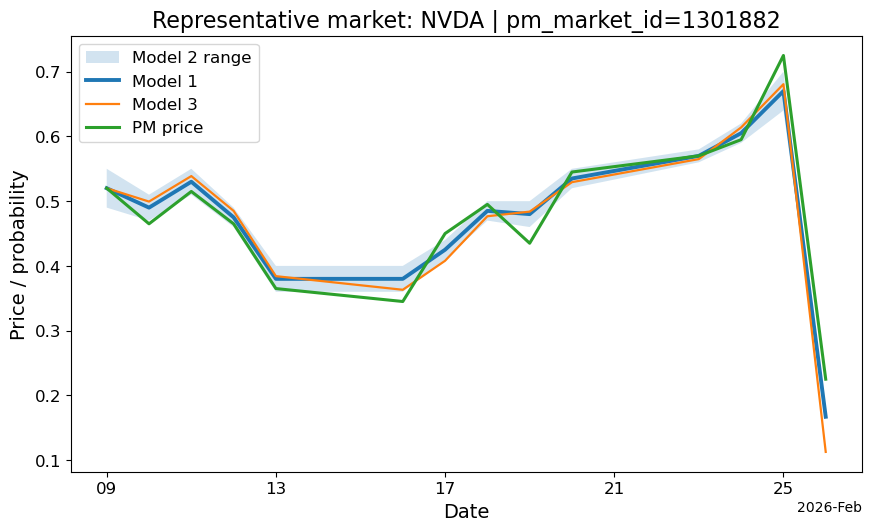

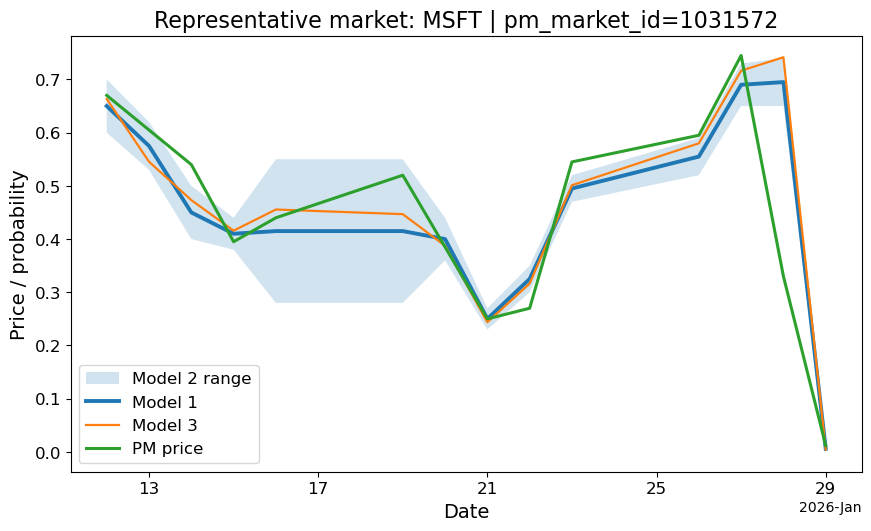

Saved:
- section3_model_comparison_outputs/plots/s3_representative_market_1301882.png
- section3_model_comparison_outputs/plots/s3_representative_market_1031572.png


In [26]:
# --------------------------------------------------
# Plot two representative markets through time
# --------------------------------------------------

import matplotlib.dates as mdates

def plot_market_models_over_time(df_market, out_path):
    temp = df_market.sort_values("date").copy()

    fig, ax = plt.subplots(figsize=(8.6, 5.2), constrained_layout=True)

    # Model 2 range as shaded band
    ax.fill_between(
        temp["date"],
        temp["model2_low"],
        temp["model2_high"],
        alpha=0.20,
        label="Model 2 range"
    )

    # Model 1, Model 3, PM
    ax.plot(temp["date"], temp["model1_price"], linewidth=2.8, label="Model 1")
    ax.plot(temp["date"], temp["model3_price"], linewidth=1.6, label="Model 3")
    ax.plot(temp["date"], temp["pm_price_yes"], linewidth=2.2, label="PM price")

    title_text = (
        f"Representative market: {temp['stock_ticker'].iloc[0]} | "
        f"pm_market_id={int(temp['pm_market_id'].iloc[0])}"
    )
    ax.set_title(title_text, fontsize=16)
    ax.set_xlabel("Date", fontsize=14)
    ax.set_ylabel("Price / probability", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)

    # Cleaner date axis
    locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    ax.legend(fontsize=12)

    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

market_plot_paths = []

for mid in chosen_market_ids:
    out_path = os.path.join(S3_PLOT_DIR, f"s3_representative_market_{mid}.png")
    plot_market_models_over_time(chosen_market_dfs[mid], out_path)
    market_plot_paths.append(out_path)

print("Saved:")
for p in market_plot_paths:
    print("-", p)

Representative market rows: (14, 37)


,pm_market_id,date,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_price_yes,stock_close_nocp,abs_diff_hours,fidelity_used,data_regime,model1_price,model2_low,model2_high,model3_price,mispricing_m1_pm_minus_model1,mispricing_m3_pm_minus_model3,abs_mispricing_m1,abs_mispricing_m3,pm_inside_model2_range,pm_below_model2_range,pm_above_model2_range,model2_range_width,pm_minus_model2_low,pm_minus_model2_high,tau_days,market_age_days,max_rel_opt_spread,main_moneyness,boundary_moneyness_b1,boundary_moneyness_b2,pm_boundary_strike,pm_boundary_strike_b1,pm_boundary_strike_b2,n_boundaries_present
3189,1031572,2026-01-12,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,"[x, inf)",2026-01-30,0.670,477.18,3.006111,720,pre_2026_03_20_halfday,0.650,0.60,0.70,0.663203,0.020,0.006797,0.020,0.006797,True,False,False,0.10,0.070,-0.030,18,17,0.012422,0.025856,0.025856,NaN,465.0,NaN,NaN,1
3205,1031572,2026-01-13,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,"[x, inf)",2026-01-30,0.605,470.67,3.006389,720,pre_2026_03_20_halfday,0.575,0.53,0.62,0.545447,0.030,0.059553,0.030,0.059553,True,False,False,0.09,0.075,-0.015,17,18,0.014948,0.012120,0.012120,NaN,465.0,NaN,NaN,1
3221,1031572,2026-01-14,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,"[x, inf)",2026-01-30,0.540,459.38,3.006944,720,pre_2026_03_20_halfday,0.450,0.40,0.50,0.473202,0.090,0.066798,0.090,0.066798,False,False,True,0.10,0.140,0.040,16,19,0.021505,-0.012160,-0.012160,NaN,465.0,NaN,NaN,1
3235,1031572,2026-01-15,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,"[x, inf)",2026-01-30,0.395,456.66,3.007778,720,pre_2026_03_20_halfday,0.410,0.38,0.44,0.415790,-0.015,-0.020790,0.015,0.020790,True,False,False,0.06,0.015,-0.045,15,20,0.014963,-0.018098,-0.018098,NaN,465.0,NaN,NaN,1
3247,1031572,2026-01-16,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,"[x, inf)",2026-01-30,0.440,459.86,3.006667,720,pre_2026_03_20_halfday,0.415,0.28,0.55,0.455512,0.025,-0.015512,0.025,0.015512,True,False,False,0.27,0.160,-0.110,14,21,0.117647,-0.011115,-0.011115,NaN,465.0,NaN,NaN,1



Market information:


,pm_market_id,stock_ticker,event_id,event_slug,event_title,interval_type,option_expiry,pm_boundary_strike,pm_boundary_strike_b1,pm_boundary_strike_b2,n_boundaries_present
0,1031572,MSFT,125801,msft-above-in-january-2026,Will Microsoft (MSFT) close above ___ end of J...,"[x, inf)",2026-01-30,465.0,NaN,NaN,1



Representative market summary:


,pm_market_id,stock_ticker,interval_type,n_obs,date_min,date_max,option_expiry,mean_pm_price,mean_model1_price,mean_model3_price,mean_abs_mispricing_m1,mean_abs_mispricing_m3,inside_model2_share,mean_model2_range_width,median_max_rel_opt_spread,mean_abs_diff_hours
0,1031572,MSFT,"[x, inf)",14,2026-01-12,2026-01-29,2026-01-30,0.450143,0.452214,0.463675,0.062214,0.057458,0.571429,0.097286,0.017651,3.008254


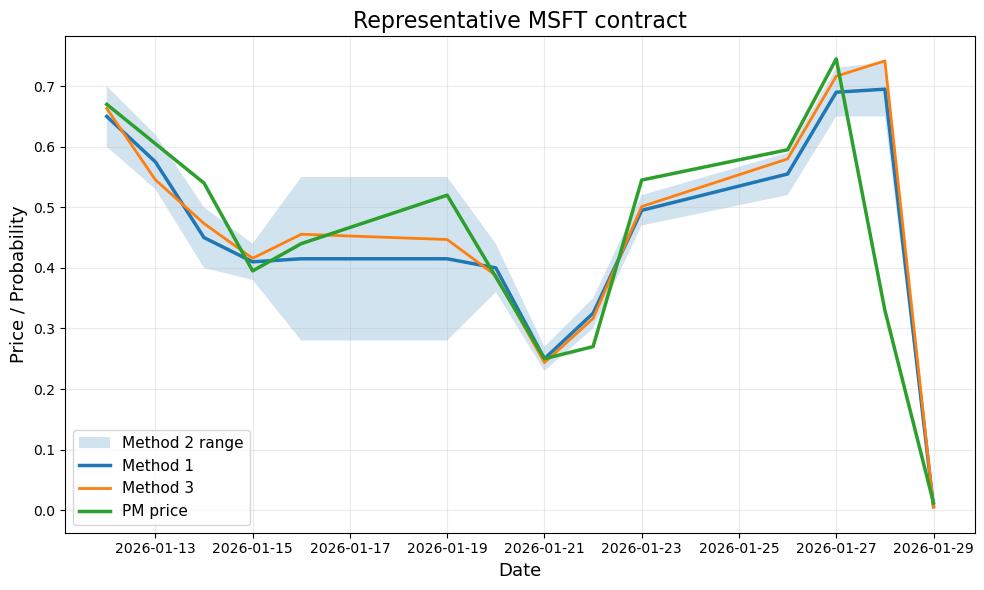

Saved figure to: thesis_figures/representative_contract_MSFT_1031572.png


In [27]:
# ============================================================
# Representative contract plot for thesis
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare sample
# ------------------------------------------------------------
if "analysis_sample" in globals():
    plot_sample = analysis_sample.copy()
elif "final_sample" in globals():
    plot_sample = final_sample.copy()
else:
    final_sample = pd.read_csv("final_sample.csv")
    plot_sample = final_sample.copy()

# Parse dates
for c in ["date", "option_expiry"]:
    if c in plot_sample.columns:
        plot_sample[c] = pd.to_datetime(plot_sample[c], errors="coerce")

# ------------------------------------------------------------
# 2. Choose representative market
# ------------------------------------------------------------
REP_MARKET_ID = 1031572   # the MSFT example used in presentation

rep_df = (
    plot_sample.loc[plot_sample["pm_market_id"] == REP_MARKET_ID]
    .copy()
    .sort_values("date")
)

print("Representative market rows:", rep_df.shape)
display(rep_df.head())

if rep_df.empty:
    raise ValueError(f"No observations found for pm_market_id={REP_MARKET_ID}")

# ------------------------------------------------------------
# 3. Market information table
# ------------------------------------------------------------
info_cols = [
    "pm_market_id",
    "stock_ticker",
    "event_id",
    "event_slug",
    "event_title",
    "interval_type",
    "option_expiry",
    "pm_boundary_strike",
    "pm_boundary_strike_b1",
    "pm_boundary_strike_b2",
    "n_boundaries_present",
]

info_cols = [c for c in info_cols if c in rep_df.columns]

market_info = rep_df[info_cols].drop_duplicates().reset_index(drop=True)

print("\nMarket information:")
display(market_info)

# ------------------------------------------------------------
# 4. Market-level summary statistics
# ------------------------------------------------------------
rep_summary = pd.DataFrame([{
    "pm_market_id": REP_MARKET_ID,
    "stock_ticker": rep_df["stock_ticker"].iloc[0] if "stock_ticker" in rep_df.columns else None,
    "interval_type": rep_df["interval_type"].iloc[0] if "interval_type" in rep_df.columns else None,
    "n_obs": len(rep_df),
    "date_min": rep_df["date"].min(),
    "date_max": rep_df["date"].max(),
    "option_expiry": rep_df["option_expiry"].iloc[0] if "option_expiry" in rep_df.columns else None,
    "mean_pm_price": rep_df["pm_price_yes"].mean(),
    "mean_model1_price": rep_df["model1_price"].mean(),
    "mean_model3_price": rep_df["model3_price"].mean(),
    "mean_abs_mispricing_m1": rep_df["abs_mispricing_m1"].mean() if "abs_mispricing_m1" in rep_df.columns else None,
    "mean_abs_mispricing_m3": rep_df["abs_mispricing_m3"].mean() if "abs_mispricing_m3" in rep_df.columns else None,
    "inside_model2_share": rep_df["pm_inside_model2_range"].mean() if "pm_inside_model2_range" in rep_df.columns else None,
    "mean_model2_range_width": rep_df["model2_range_width"].mean() if "model2_range_width" in rep_df.columns else None,
    "median_max_rel_opt_spread": rep_df["max_rel_opt_spread"].median() if "max_rel_opt_spread" in rep_df.columns else None,
    "mean_abs_diff_hours": rep_df["abs_diff_hours"].mean() if "abs_diff_hours" in rep_df.columns else None,
}])

print("\nRepresentative market summary:")
display(rep_summary)

# ------------------------------------------------------------
# 5. Plot PM price, Method 1, Method 3, and Method 2 range
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Method 2 bid-ask range
ax.fill_between(
    rep_df["date"],
    rep_df["model2_low"],
    rep_df["model2_high"],
    alpha=0.2,
    label="Method 2 range"
)

# Point benchmarks and PM price
ax.plot(rep_df["date"], rep_df["model1_price"], linewidth=2.5, label="Method 1")
ax.plot(rep_df["date"], rep_df["model3_price"], linewidth=2.0, label="Method 3")
ax.plot(rep_df["date"], rep_df["pm_price_yes"], linewidth=2.5, label="PM price")

stock = rep_df["stock_ticker"].iloc[0] if "stock_ticker" in rep_df.columns else ""
interval_type = rep_df["interval_type"].iloc[0] if "interval_type" in rep_df.columns else ""

ax.set_title(
    f"Representative {stock} contract",
    fontsize=16
)
ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Price / Probability", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.25)

plt.tight_layout()

# ------------------------------------------------------------
# 6. Save figure
# ------------------------------------------------------------
out_dir = "thesis_figures"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(
    out_dir,
    f"representative_contract_{stock}_{REP_MARKET_ID}.png"
)

plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", out_path)

### 3.2 Compare Model 1 and Model 3 benchmark prices

Rather than asking which point model is closer to PM, we directly compare the two
option-based benchmark prices themselves in the main sample `[x, inf)`.

This addresses the more meaningful question:

- how different is the IV-based benchmark from the mid-price-based benchmark?

We focus on:
- the signed difference:
  $$
  model3\_price - model1\_price
  $$
- the absolute difference:
  $$
  |model3\_price - model1\_price|
  $$

If these differences are generally small, then the IV-based adjustment does not
materially change the benchmark in most observations.

In [28]:
# --------------------------------------------------
# Summary table for Model 1 vs Model 3 benchmark prices
# Put signed diff and absolute diff in separate rows
# [x, inf) only
# --------------------------------------------------

s3_x_inf = s3_sample.loc[s3_sample["interval_type"] == "[x, inf)"].copy()

s3_x_inf["model3_minus_model1"] = s3_x_inf["model3_price"] - s3_x_inf["model1_price"]
s3_x_inf["abs_model3_minus_model1"] = s3_x_inf["model3_minus_model1"].abs()

s3_model13_price_diff_summary = pd.DataFrame([
    {
        "sample": "[x, inf)",
        "difference_type": "signed_diff_m3_minus_m1",
        "n_obs": len(s3_x_inf),
        "mean": s3_x_inf["model3_minus_model1"].mean(),
        "median": s3_x_inf["model3_minus_model1"].median(),
        "std": s3_x_inf["model3_minus_model1"].std(),
        "p10": s3_x_inf["model3_minus_model1"].quantile(0.10),
        "p90": s3_x_inf["model3_minus_model1"].quantile(0.90),
        "share_le_0_01": np.nan,
        "share_le_0_02": np.nan,
        "share_le_0_05": np.nan,
    },
    {
        "sample": "[x, inf)",
        "difference_type": "abs_diff_m3_minus_m1",
        "n_obs": len(s3_x_inf),
        "mean": s3_x_inf["abs_model3_minus_model1"].mean(),
        "median": s3_x_inf["abs_model3_minus_model1"].median(),
        "std": s3_x_inf["abs_model3_minus_model1"].std(),
        "p10": s3_x_inf["abs_model3_minus_model1"].quantile(0.10),
        "p90": s3_x_inf["abs_model3_minus_model1"].quantile(0.90),
        "share_le_0_01": (s3_x_inf["abs_model3_minus_model1"] <= 0.01).mean(),
        "share_le_0_02": (s3_x_inf["abs_model3_minus_model1"] <= 0.02).mean(),
        "share_le_0_05": (s3_x_inf["abs_model3_minus_model1"] <= 0.05).mean(),
    },
])

display(s3_model13_price_diff_summary)

s3_model13_price_diff_summary.to_csv(
    os.path.join(S3_TABLE_DIR, "s3_model13_price_diff_summary_x_inf.csv"),
    index=False
)
print("Saved: s3_model13_price_diff_summary_x_inf.csv")

,sample,difference_type,n_obs,mean,median,std,p10,p90,share_le_0_01,share_le_0_02,share_le_0_05
0,"[x, inf)",signed_diff_m3_minus_m1,4041,0.000133,-0.003326,0.057728,-0.043357,0.049423,NaN,NaN,NaN
1,"[x, inf)",abs_diff_m3_minus_m1,4041,0.032988,0.019993,0.047372,0.002113,0.075209,0.315268,0.500124,0.828508


Saved: s3_model13_price_diff_summary_x_inf.csv


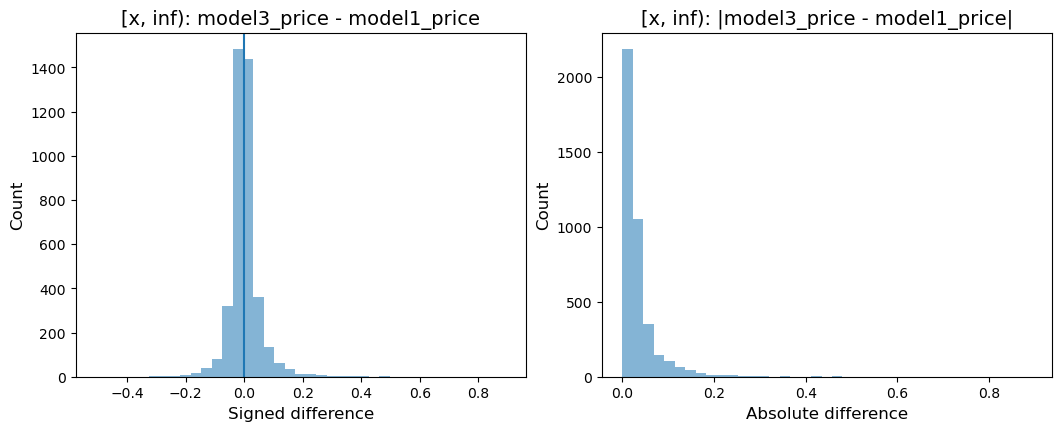

Saved:
- section3_model_comparison_outputs/plots/s3_model13_price_differences_x_inf.png


In [29]:
# --------------------------------------------------
# Distribution plots: model3_price - model1_price
# [x, inf) only
# --------------------------------------------------

def plot_model13_price_differences(df, out_prefix):
    temp = df.copy()

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)

    # Signed difference
    signed = temp["model3_minus_model1"]
    bins_signed = np.linspace(signed.min(), signed.max(), 40)
    axes[0].hist(signed, bins=bins_signed, alpha=0.55)
    axes[0].axvline(0, linewidth=1.5)
    axes[0].set_title("[x, inf): model3_price - model1_price", fontsize=14)
    axes[0].set_xlabel("Signed difference", fontsize=12)
    axes[0].set_ylabel("Count", fontsize=12)

    # Absolute difference
    absdiff = temp["abs_model3_minus_model1"]
    bins_abs = np.linspace(0, absdiff.max(), 40)
    axes[1].hist(absdiff, bins=bins_abs, alpha=0.55)
    axes[1].set_title("[x, inf): |model3_price - model1_price|", fontsize=14)
    axes[1].set_xlabel("Absolute difference", fontsize=12)
    axes[1].set_ylabel("Count", fontsize=12)

    out_path = os.path.join(S3_PLOT_DIR, f"{out_prefix}.png")
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    return out_path

plot_model13_diff_hist = plot_model13_price_differences(
    s3_x_inf,
    out_prefix="s3_model13_price_differences_x_inf"
)

print("Saved:")
print("-", plot_model13_diff_hist)

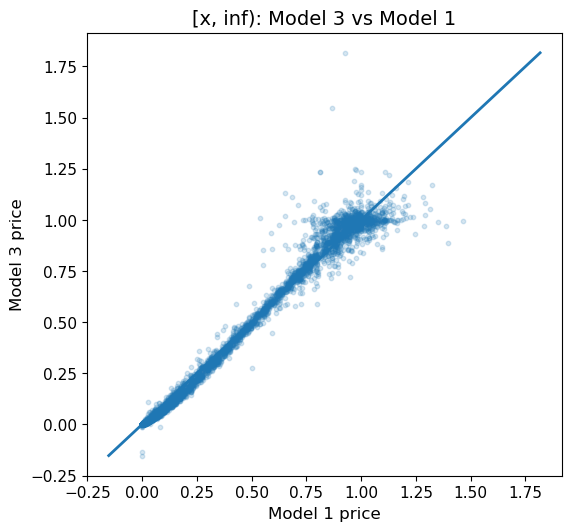

Saved:
- section3_model_comparison_outputs/plots/s3_model13_price_scatter_x_inf.png


In [30]:
# --------------------------------------------------
# Scatter: Model 1 price vs Model 3 price with 45-degree line
# [x, inf) only
# --------------------------------------------------

def plot_model13_price_scatter(df, out_prefix):
    temp = df[["model1_price", "model3_price"]].dropna().copy()

    lo = min(temp["model1_price"].min(), temp["model3_price"].min())
    hi = max(temp["model1_price"].max(), temp["model3_price"].max())

    fig, ax = plt.subplots(figsize=(5.6, 5.2), constrained_layout=True)
    ax.scatter(temp["model1_price"], temp["model3_price"], alpha=0.18, s=10)
    ax.plot([lo, hi], [lo, hi], linewidth=2.0)

    ax.set_title("[x, inf): Model 3 vs Model 1", fontsize=14)
    ax.set_xlabel("Model 1 price", fontsize=12)
    ax.set_ylabel("Model 3 price", fontsize=12)
    ax.tick_params(axis="both", labelsize=11)

    out_path = os.path.join(S3_PLOT_DIR, f"{out_prefix}.png")
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    return out_path

plot_model13_scatter = plot_model13_price_scatter(
    s3_x_inf,
    out_prefix="s3_model13_price_scatter_x_inf"
)

print("Saved:")
print("-", plot_model13_scatter)

### 3.3 Model 2 as an interval benchmark

We summarize:
- inside-range share
- below-range share
- above-range share
- range width

for the full sample and key subsamples.

In [31]:
# --------------------------------------------------
# Model 2 summary helpers
# --------------------------------------------------

def summarize_model2_interval(df, label):
    return pd.DataFrame({
        "sample": [label],
        "n_obs": [len(df)],
        "inside_range_share": [df["pm_inside_model2_range"].mean()],
        "below_range_share": [df["pm_below_model2_range"].mean()],
        "above_range_share": [df["pm_above_model2_range"].mean()],
        "mean_range_width": [df["model2_range_width"].mean()],
        "median_range_width": [df["model2_range_width"].median()],
        "p90_range_width": [df["model2_range_width"].quantile(0.90)],
    })

def grouped_model2_summary(df, group_col):
    out = (
        df.groupby(group_col)
        .agg(
            n_obs=("pm_market_id", "size"),
            inside_range_share=("pm_inside_model2_range", "mean"),
            below_range_share=("pm_below_model2_range", "mean"),
            above_range_share=("pm_above_model2_range", "mean"),
            mean_range_width=("model2_range_width", "mean"),
            median_range_width=("model2_range_width", "median"),
        )
        .reset_index()
        .sort_values("n_obs", ascending=False)
    )
    return out

In [32]:
# --------------------------------------------------
# Model 2 summary: overall table only
# --------------------------------------------------

def summarize_model2_interval(df, label):
    return pd.DataFrame({
        "sample": [label],
        "n_obs": [len(df)],
        "inside_range_share": [df["pm_inside_model2_range"].mean()],
        "below_range_share": [df["pm_below_model2_range"].mean()],
        "above_range_share": [df["pm_above_model2_range"].mean()],
        "mean_range_width": [df["model2_range_width"].mean()],
        "median_range_width": [df["model2_range_width"].median()],
        "p90_range_width": [df["model2_range_width"].quantile(0.90)],
    })

s3_model2_summary = pd.concat([
    summarize_model2_interval(s3_sample, "full_final_sample"),
    summarize_model2_interval(s3_sample.loc[s3_sample["interval_type"] == "[x, inf)"], "[x, inf)"),
    summarize_model2_interval(s3_sample.loc[s3_sample["interval_type"] == "[0, x]"], "[0, x]"),
    summarize_model2_interval(s3_sample.loc[s3_sample["interval_type"] == "[x, y]"], "[x, y]"),
], ignore_index=True)

display(s3_model2_summary)

s3_model2_summary.to_csv(os.path.join(S3_TABLE_DIR, "s3_model2_summary.csv"), index=False)
print("Saved: s3_model2_summary.csv")

,sample,n_obs,inside_range_share,below_range_share,above_range_share,mean_range_width,median_range_width,p90_range_width
0,full_final_sample,6136,0.562256,0.139668,0.298077,0.436712,0.080,1.31
1,"[x, inf)",4041,0.496164,0.166543,0.337293,0.312689,0.060,0.98
2,"[0, x]",236,0.868644,0.055085,0.076271,0.855797,0.810,1.47
3,"[x, y]",1859,0.667025,0.091985,0.240990,0.653104,0.154,2.02


Saved: s3_model2_summary.csv


In [33]:
SECTION3_RESULTS = {
    "candidate_markets_x_inf": candidate_markets_x_inf,
    "chosen_market_meta": chosen_market_meta,
    "chosen_market_ids": chosen_market_ids,
    "model13_price_diff_summary_x_inf": s3_model13_price_diff_summary,
    "model2_summary": s3_model2_summary,
}

print("Stored section 3 results in SECTION3_RESULTS.")
print("Chosen representative market IDs:", chosen_market_ids)

Stored section 3 results in SECTION3_RESULTS.
Chosen representative market IDs: [1301882, 1031572]


### 3.2 Model 1 vs Model 3 benchmark prices

Rather than asking which point model is closer to PM on each observation, this subsection compares the two option-based benchmark prices directly in the main sample `[x, inf)`.

This addresses the more relevant question:

- how different is the IV-based benchmark from the mid-price-based benchmark itself?

We focus on:

- the signed benchmark difference  
  $$
  \text{Model 3 price} - \text{Model 1 price}
  $$

- the absolute benchmark difference  
  $$
  \left| \text{Model 3 price} - \text{Model 1 price} \right|
  $$

If these differences are generally small, then the IV-based European adjustment does not materially change the option-implied benchmark in most observations.

#### Main result

The two point benchmarks are broadly similar in the `[x, inf)` sample.

- The **mean signed difference** is close to zero, implying no strong systematic level shift between Model 3 and Model 1.
- The **mean absolute difference** is about **0.033**, and the **median absolute difference** is about **0.020**.
- About **83%** of observations have absolute benchmark difference no larger than **0.05**.

So while the IV-based adjustment does move the benchmark in some cases, it does **not** appear to be the main driver of the PM-option pricing gap in the bulk of the sample.

The figures below show:
1. the distribution of `Model 3 price - Model 1 price`,
2. the distribution of `|Model 3 price - Model 1 price|`,
3. a scatter plot of Model 3 price against Model 1 price with the 45-degree line.

## 4. Stock-level comparison on the main sample `[x, inf)`

This table summarizes cross-stock differences in:
- sample size
- Model 1 signed mispricing
- Model 1 absolute mispricing
- Model 2 inside-range share
- Model 2 range width
- option spread

We focus only on `[x, inf)`, which is the main analysis sample.

In [34]:
# --------------------------------------------------
# Section 4: stock-level comparison
# Main sample only: [x, inf)
# --------------------------------------------------

s4_x_inf = analysis_sample.loc[
    analysis_sample["interval_type"] == "[x, inf)"
].copy()

stock_summary_x_inf = (
    s4_x_inf.groupby("stock_ticker")
    .agg(
        n_obs=("pm_market_id", "size"),
        n_markets=("pm_market_id", "nunique"),
        n_events=("event_id", "nunique"),

        mean_signed_mispricing_m1=("mispricing_m1_pm_minus_model1", "mean"),
        median_signed_mispricing_m1=("mispricing_m1_pm_minus_model1", "median"),

        mean_abs_mispricing_m1=("abs_mispricing_m1", "mean"),
        median_abs_mispricing_m1=("abs_mispricing_m1", "median"),

        inside_range_share_m2=("pm_inside_model2_range", "mean"),

        mean_model2_range_width=("model2_range_width", "mean"),
        median_model2_range_width=("model2_range_width", "median"),

        median_max_rel_opt_spread=("max_rel_opt_spread", "median"),
    )
    .reset_index()
    .sort_values("n_obs", ascending=False)
)

display(stock_summary_x_inf)

stock_summary_x_inf.to_csv(
    os.path.join(S3_TABLE_DIR, "s4_stock_summary_x_inf.csv"),
    index=False
)
print("Saved: s4_stock_summary_x_inf.csv")

,stock_ticker,n_obs,n_markets,n_events,mean_signed_mispricing_m1,median_signed_mispricing_m1,mean_abs_mispricing_m1,median_abs_mispricing_m1,inside_range_share_m2,mean_model2_range_width,median_model2_range_width,median_max_rel_opt_spread
8,TSLA,680,141,24,0.018896,5.000000e-03,0.073965,0.04500,0.358824,0.116426,0.040,0.026110
2,GOOGL,532,129,22,0.007546,6.250000e-03,0.062405,0.03375,0.560150,0.299827,0.070,0.083640
6,NVDA,500,119,22,-0.004584,1.500000e-03,0.059942,0.03150,0.466000,0.213160,0.040,0.042553
0,AAPL,481,120,21,-0.007080,-5.000000e-03,0.061970,0.03400,0.544699,0.294183,0.090,0.080000
1,AMZN,472,112,19,-0.009946,-4.440892e-16,0.073234,0.03825,0.510593,0.298047,0.078,0.081081
3,META,454,112,20,0.006910,5.000000e-03,0.084209,0.04500,0.557269,0.495568,0.090,0.065995
4,MSFT,401,96,17,-0.019100,0.000000e+00,0.062883,0.03500,0.543641,0.348214,0.070,0.068966
7,OPEN,366,115,13,0.014903,1.075000e-02,0.088395,0.03500,0.398907,0.292432,0.050,0.222222
5,NFLX,155,35,13,0.001710,-1.500000e-03,0.077574,0.03250,0.709677,1.061194,0.225,0.106870


Saved: s4_stock_summary_x_inf.csv


In [35]:
# Optional: cleaner display copy
stock_summary_x_inf_display = stock_summary_x_inf.copy()

round_cols = [
    "mean_signed_mispricing_m1",
    "median_signed_mispricing_m1",
    "mean_abs_mispricing_m1",
    "median_abs_mispricing_m1",
    "inside_range_share_m2",
    "mean_model2_range_width",
    "median_model2_range_width",
    "median_max_rel_opt_spread",
]

stock_summary_x_inf_display[round_cols] = stock_summary_x_inf_display[round_cols].round(4)

display(stock_summary_x_inf_display)

,stock_ticker,n_obs,n_markets,n_events,mean_signed_mispricing_m1,median_signed_mispricing_m1,mean_abs_mispricing_m1,median_abs_mispricing_m1,inside_range_share_m2,mean_model2_range_width,median_model2_range_width,median_max_rel_opt_spread
8,TSLA,680,141,24,0.0189,0.0050,0.0740,0.0450,0.3588,0.1164,0.040,0.0261
2,GOOGL,532,129,22,0.0075,0.0062,0.0624,0.0338,0.5602,0.2998,0.070,0.0836
6,NVDA,500,119,22,-0.0046,0.0015,0.0599,0.0315,0.4660,0.2132,0.040,0.0426
0,AAPL,481,120,21,-0.0071,-0.0050,0.0620,0.0340,0.5447,0.2942,0.090,0.0800
1,AMZN,472,112,19,-0.0099,-0.0000,0.0732,0.0382,0.5106,0.2980,0.078,0.0811
3,META,454,112,20,0.0069,0.0050,0.0842,0.0450,0.5573,0.4956,0.090,0.0660
4,MSFT,401,96,17,-0.0191,0.0000,0.0629,0.0350,0.5436,0.3482,0.070,0.0690
7,OPEN,366,115,13,0.0149,0.0107,0.0884,0.0350,0.3989,0.2924,0.050,0.2222
5,NFLX,155,35,13,0.0017,-0.0015,0.0776,0.0325,0.7097,1.0612,0.225,0.1069


In [36]:
SECTION4_RESULTS = {
    "stock_summary_x_inf": stock_summary_x_inf
}

print("Stored section 4 results in SECTION4_RESULTS.")

Stored section 4 results in SECTION4_RESULTS.


## 5. Supplementary interval-type results

This section stays short and supplementary.

- For `[0, x]`, we retain only the most informative one-boundary supplementary result:
  - absolute mispricing vs moneyness
- For `[x, y]`, we do not repeat the full univariate analysis.
  Instead, we use a compact cross-interval comparison table.

The purpose is to see which main-sample findings extend beyond `[x, inf)`,
while keeping `[x, y]` clearly separate as a structurally different case.

In [37]:
# --------------------------------------------------
# Section 5 setup
# --------------------------------------------------

from IPython.display import Image, display

if "analysis_sample" in globals():
    s5_sample = analysis_sample.copy()
else:
    s5_sample = final_sample.copy()

SECTION5_DIR = "section5_supplementary_outputs"
os.makedirs(SECTION5_DIR, exist_ok=True)

print("s5_sample shape:", s5_sample.shape)

s5_sample shape: (6136, 37)


### 5.1 `[0, x]`: targeted supplementary check

We retain only one key univariate result from Section 2:

- absolute mispricing vs `main_moneyness`

This is the clearest supplementary result for `[0, x]`.

Displaying:
- section2_univariate_outputs/plots/s2_0_x_scatter_main_moneyness_abs_mispricing_m1.png
- section2_univariate_outputs/plots/s2_0_x_binmean_main_moneyness_abs_mispricing_m1.png


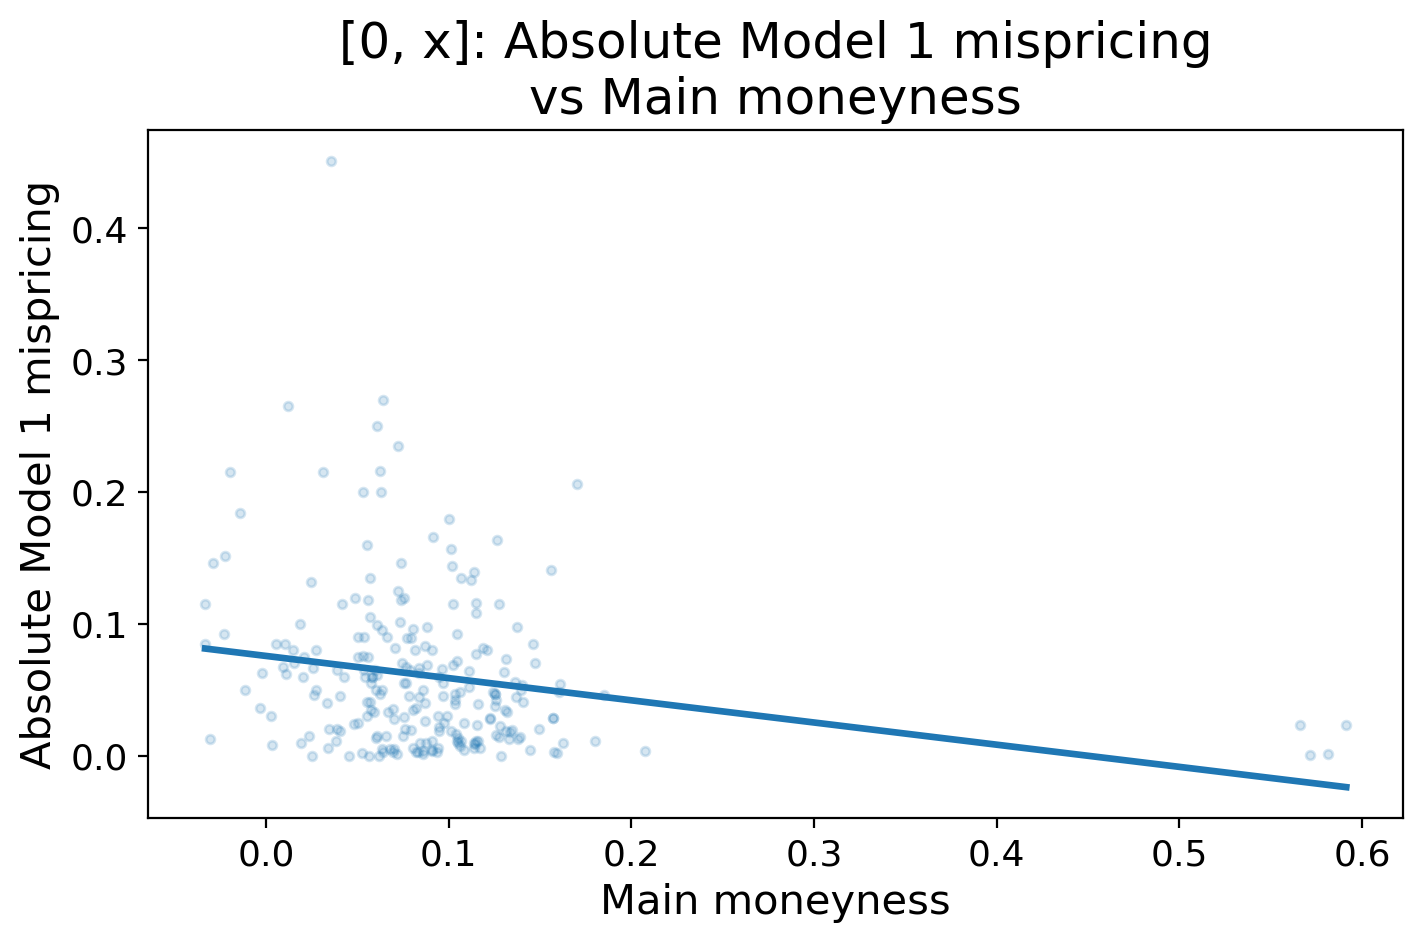

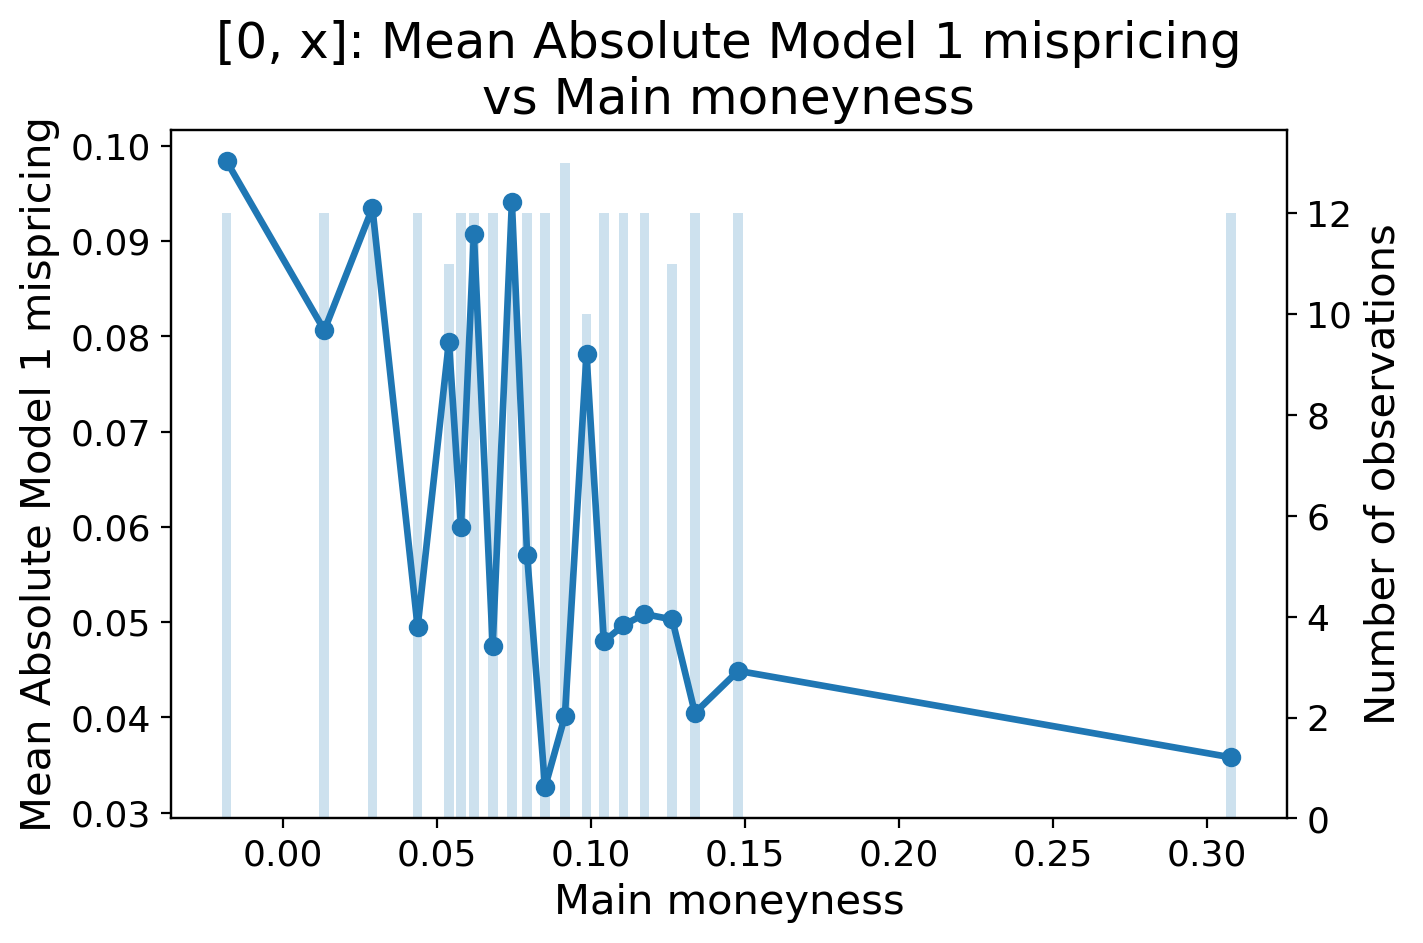

In [38]:
# --------------------------------------------------
# Display the saved [0, x] plots from Section 2
# --------------------------------------------------

plot_0x_scatter = os.path.join(
    PLOT_DIR, "s2_0_x_scatter_main_moneyness_abs_mispricing_m1.png"
)
plot_0x_binmean = os.path.join(
    PLOT_DIR, "s2_0_x_binmean_main_moneyness_abs_mispricing_m1.png"
)

print("Displaying:")
print("-", plot_0x_scatter)
print("-", plot_0x_binmean)

display(Image(filename=plot_0x_scatter))
display(Image(filename=plot_0x_binmean))

In [39]:
# --------------------------------------------------
# Compact summary table for [0, x]
# --------------------------------------------------

s5_0x = s5_sample.loc[s5_sample["interval_type"] == "[0, x]"].copy()

s5_0x_summary = pd.DataFrame({
    "sample": ["[0, x]"],
    "n_obs": [len(s5_0x)],
    "n_markets": [s5_0x["pm_market_id"].nunique()],
    "n_events": [s5_0x["event_id"].nunique()],
    "mean_signed_mispricing_m1": [s5_0x["mispricing_m1_pm_minus_model1"].mean()],
    "median_signed_mispricing_m1": [s5_0x["mispricing_m1_pm_minus_model1"].median()],
    "mean_abs_mispricing_m1": [s5_0x["abs_mispricing_m1"].mean()],
    "median_abs_mispricing_m1": [s5_0x["abs_mispricing_m1"].median()],
    "inside_range_share_m2": [s5_0x["pm_inside_model2_range"].mean()],
    "mean_model2_range_width": [s5_0x["model2_range_width"].mean()],
    "median_model2_range_width": [s5_0x["model2_range_width"].median()],
})

display(s5_0x_summary.round(4))

s5_0x_summary.to_csv(
    os.path.join(SECTION5_DIR, "s5_0x_summary.csv"),
    index=False
)
print("Saved: s5_0x_summary.csv")

,sample,n_obs,n_markets,n_events,mean_signed_mispricing_m1,median_signed_mispricing_m1,mean_abs_mispricing_m1,median_abs_mispricing_m1,inside_range_share_m2,mean_model2_range_width,median_model2_range_width
0,"[0, x]",236,64,64,0.0233,0.0115,0.0607,0.0465,0.8686,0.8558,0.81


Saved: s5_0x_summary.csv


### 5.2 Compact cross-interval comparison

The table below compares the three interval types using only a few core metrics:

- `n_obs`
- mean / median absolute mispricing
- inside-range share under Model 2
- mean / median Model 2 range width

This is the main descriptive comparison for `[x, y]`.

In [40]:
# --------------------------------------------------
# Compact cross-interval comparison table
# --------------------------------------------------

s5_cross_interval = (
    s5_sample.groupby("interval_type")
    .agg(
        n_obs=("pm_market_id", "size"),
        mean_abs_mispricing_m1=("abs_mispricing_m1", "mean"),
        median_abs_mispricing_m1=("abs_mispricing_m1", "median"),
        inside_range_share_m2=("pm_inside_model2_range", "mean"),
        mean_model2_range_width=("model2_range_width", "mean"),
        median_model2_range_width=("model2_range_width", "median"),
    )
    .reset_index()
)

# Put rows in preferred order
interval_order = pd.Categorical(
    s5_cross_interval["interval_type"],
    categories=["[x, inf)", "[0, x]", "[x, y]"],
    ordered=True
)
s5_cross_interval = (
    s5_cross_interval.assign(interval_order=interval_order)
    .sort_values("interval_order")
    .drop(columns="interval_order")
    .reset_index(drop=True)
)

display(s5_cross_interval.round(4))

s5_cross_interval.to_csv(
    os.path.join(SECTION5_DIR, "s5_cross_interval_comparison.csv"),
    index=False
)
print("Saved: s5_cross_interval_comparison.csv")

,interval_type,n_obs,mean_abs_mispricing_m1,median_abs_mispricing_m1,inside_range_share_m2,mean_model2_range_width,median_model2_range_width
0,"[x, inf)",4041,0.0707,0.0360,0.4962,0.3127,0.060
1,"[0, x]",236,0.0607,0.0465,0.8686,0.8558,0.810
2,"[x, y]",1859,0.0698,0.0380,0.6670,0.6531,0.154


Saved: s5_cross_interval_comparison.csv


In [41]:
SECTION5_RESULTS = {
    "summary_0_x": s5_0x_summary,
    "cross_interval_comparison": s5_cross_interval,
    "plot_0x_scatter": plot_0x_scatter,
    "plot_0x_binmean": plot_0x_binmean,
}

print("Stored section 5 results in SECTION5_RESULTS.")

Stored section 5 results in SECTION5_RESULTS.


## Key findings from Section 5

Section 5 provides short supplementary comparisons for the other interval types.

### `[0, x]`

The most informative supplementary result remains the relationship between **absolute mispricing** and **moneyness**.

The compact summary table also shows that `[0, x]` has:

- a much higher inside-range share under Model 2,
- but also a much wider Model 2 executable range.

Although mean absolute mispricing in `[0, x]` is slightly lower than in `[x, inf)`, the median absolute mispricing is not lower in the same way. Therefore, the evidence does **not** support interpreting `[0, x]` as clearly better priced overall.

Interpretation: the high inside-range share in `[0, x]` should not be interpreted as tighter pricing by itself. It must be read together with the much wider executable option band.

### `[x, y]`

`[x, y]` is best treated as a structurally distinct case.

Its mean absolute mispricing is similar to `[x, inf)`, but:

- its inside-range share is higher,
- and its Model 2 range is also much wider.

This suggests that the higher inside-range share in `[x, y]` is at least partly mechanical, reflecting a wider executable option band rather than clearly tighter PM-option alignment.

### Bottom line

Section 5 supports two main conclusions:

1. The key one-boundary supplementary result for `[0, x]` is consistent with the idea that moneyness still matters.
2. Across interval types, inside-range share must always be interpreted jointly with Model 2 range width.

Therefore, `[x, inf)` remains the most informative main sample, while `[0, x]` and `[x, y]` are best used as supplementary reference cases.

## 6. Combined regressions

### Purpose

This section moves from the univariate evidence in Section 2 to a multivariate setting.

The goal is not to estimate a fully structural pricing model. Instead, the purpose is to ask which variables remain associated with mispricing after controlling for the others in the **main sample** `[x, inf)`.

To keep the analysis simple and focused, Section 6 uses **only** the `[x, inf)` sample, which contains **4,041** market-day observations. This is the largest and most informative interval type in the final dataset, and it is also the one for which `main_moneyness` is naturally defined. :contentReference[oaicite:0]{index=0}

### Dependent variables

We run two separate regressions:

1. **Signed mispricing**
   - dependent variable: `mispricing_m1_pm_minus_model1`

2. **Absolute mispricing**
   - dependent variable: `abs_mispricing_m1`

The first regression studies direction:
- positive values mean PM is above the Model 1 benchmark
- negative values mean PM is below the Model 1 benchmark

The second regression studies magnitude:
- larger values mean a larger PM–Model 1 gap regardless of direction

### Regressors

Both regressions include the same core controls:

- `tau_days`
- `market_age_days`
- `max_rel_opt_spread`
- `abs_diff_hours`
- stock fixed effects

Moneyness is included as follows:

- in the **signed mispricing** regression:
  - `main_moneyness`

- in the **absolute mispricing** regression:
  - `abs_main_moneyness = abs(main_moneyness)`

This keeps the interpretation clean:
- signed moneyness is appropriate for directional mispricing
- absolute moneyness is more natural for the size of the pricing gap

### Estimation choice

We use:
- OLS
- HC1 robust standard errors
- no additional weighting
- no additional filters beyond the final common sample

### Interpretation goal

Section 6 mainly asks whether the main univariate results from Section 2 survive jointly in the main `[x, inf)` sample.

The primary candidates are:
- moneyness
- option illiquidity
- timing mismatch
- and, more descriptively, time to expiry and market age

## 6. Combined regressions

### 6.1 Dependent variables

We run two separate regressions for each interval type:

- **signed mispricing**: `mispricing_m1_pm_minus_model1`
- **absolute mispricing**: `abs_mispricing_m1`

### 6.2 Regressors

Common controls:
- `tau_days`
- `market_age_days`
- `max_rel_opt_spread`
- `abs_diff_hours`
- stock fixed effects

Moneyness treatment:
- for `[x, inf)`:
  - signed-mispricing regression uses `main_moneyness`
  - absolute-mispricing regression uses `abs_main_moneyness = abs(main_moneyness)`

In [42]:
# --------------------------------------------------
# Section 6 setup
# --------------------------------------------------

if "analysis_sample" in globals():
    s6_sample = analysis_sample.copy()
else:
    s6_sample = final_sample.copy()

SECTION6_DIR = "section6_regressions_outputs"
os.makedirs(SECTION6_DIR, exist_ok=True)

print("s6_sample shape:", s6_sample.shape)
print("interval counts:")
display(
    s6_sample["interval_type"]
    .value_counts(dropna=False)
    .rename_axis("interval_type")
    .reset_index(name="n_obs")
)

s6_sample shape: (6136, 37)
interval counts:


,interval_type,n_obs
0,"[x, inf)",4041
1,"[x, y]",1859
2,"[0, x]",236


In [43]:
# --------------------------------------------------
# Construct regression variables
# --------------------------------------------------

s6_sample["abs_main_moneyness"] = s6_sample["main_moneyness"].abs()

# For [x, y] robustness only
s6_sample["avg_abs_boundary_moneyness"] = (
    s6_sample[["boundary_moneyness_b1", "boundary_moneyness_b2"]]
    .abs()
    .mean(axis=1)
)

# Useful stock FE variable
s6_sample["stock_ticker_fe"] = s6_sample["stock_ticker"].astype("category")

# Quick check
s6_var_check = pd.DataFrame({
    "variable": [
        "mispricing_m1_pm_minus_model1",
        "abs_mispricing_m1",
        "tau_days",
        "market_age_days",
        "max_rel_opt_spread",
        "abs_diff_hours",
        "main_moneyness",
        "abs_main_moneyness",
        "avg_abs_boundary_moneyness",
    ],
    "missing_share": [
        s6_sample["mispricing_m1_pm_minus_model1"].isna().mean(),
        s6_sample["abs_mispricing_m1"].isna().mean(),
        s6_sample["tau_days"].isna().mean(),
        s6_sample["market_age_days"].isna().mean(),
        s6_sample["max_rel_opt_spread"].isna().mean(),
        s6_sample["abs_diff_hours"].isna().mean(),
        s6_sample["main_moneyness"].isna().mean(),
        s6_sample["abs_main_moneyness"].isna().mean(),
        s6_sample["avg_abs_boundary_moneyness"].isna().mean(),
    ]
})

display(s6_var_check)

,variable,missing_share
0,mispricing_m1_pm_minus_model1,0.000000
1,abs_mispricing_m1,0.000000
2,tau_days,0.000000
3,market_age_days,0.000000
4,max_rel_opt_spread,0.000000
5,abs_diff_hours,0.000000
6,main_moneyness,0.302966
7,abs_main_moneyness,0.302966
8,avg_abs_boundary_moneyness,0.000000


In [44]:
# --------------------------------------------------
# Dependent-variable and regressor specs
# --------------------------------------------------

S6_Y_SPECS = {
    "signed_mispricing": "mispricing_m1_pm_minus_model1",
    "abs_mispricing": "abs_mispricing_m1",
}

S6_COMMON_X = [
    "tau_days",
    "market_age_days",
    "max_rel_opt_spread",
    "abs_diff_hours",
]

# Baseline specs by interval type
S6_X_SPECS = {
    "[x, inf)": {
        "signed_mispricing": S6_COMMON_X + ["main_moneyness"],
        "abs_mispricing": S6_COMMON_X + ["abs_main_moneyness"],
    },
    "[0, x]": {
        "signed_mispricing": S6_COMMON_X + ["main_moneyness"],
        "abs_mispricing": S6_COMMON_X + ["abs_main_moneyness"],
    },
    "[x, y]": {
        "signed_mispricing": S6_COMMON_X.copy(),
        "abs_mispricing": S6_COMMON_X.copy(),
    },
}

# Optional robustness spec for [x, y]
S6_XY_ROBUST_X_SPECS = {
    "signed_mispricing": S6_COMMON_X + ["avg_abs_boundary_moneyness"],
    "abs_mispricing": S6_COMMON_X + ["avg_abs_boundary_moneyness"],
}

print("Dependent variables:")
display(pd.DataFrame(S6_Y_SPECS.items(), columns=["label", "column"]))

print("Baseline regressors by interval type:")
for k, v in S6_X_SPECS.items():
    print(f"\n{k}")
    for yy, xx in v.items():
        print(f"  {yy}: {xx}")

print("\nOptional [x, y] robustness regressors:")
for yy, xx in S6_XY_ROBUST_X_SPECS.items():
    print(f"  {yy}: {xx}")

Dependent variables:


,label,column
0,signed_mispricing,mispricing_m1_pm_minus_model1
1,abs_mispricing,abs_mispricing_m1


Baseline regressors by interval type:

[x, inf)
  signed_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'main_moneyness']
  abs_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'abs_main_moneyness']

[0, x]
  signed_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'main_moneyness']
  abs_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'abs_main_moneyness']

[x, y]
  signed_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours']
  abs_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours']

Optional [x, y] robustness regressors:
  signed_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'avg_abs_boundary_moneyness']
  abs_mispricing: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'avg_abs_boundary_moneyness']


In [45]:
# --------------------------------------------------
# Preview regression-ready samples by interval
# --------------------------------------------------

s6_sample_preview_rows = []

for interval_type, spec_dict in S6_X_SPECS.items():
    df_int = s6_sample.loc[s6_sample["interval_type"] == interval_type].copy()

    for y_label, y_col in S6_Y_SPECS.items():
        x_cols = spec_dict[y_label]
        needed_cols = [y_col] + x_cols + ["stock_ticker"]
        n_complete = df_int[needed_cols].dropna().shape[0]

        s6_sample_preview_rows.append({
            "interval_type": interval_type,
            "y_label": y_label,
            "y_col": y_col,
            "x_cols": ", ".join(x_cols),
            "n_total_interval": len(df_int),
            "n_complete_case": n_complete,
        })

s6_sample_preview = pd.DataFrame(s6_sample_preview_rows)
display(s6_sample_preview)

,interval_type,y_label,y_col,x_cols,n_total_interval,n_complete_case
0,"[x, inf)",signed_mispricing,mispricing_m1_pm_minus_model1,"tau_days, market_age_days, max_rel_opt_spread,...",4041,4041
1,"[x, inf)",abs_mispricing,abs_mispricing_m1,"tau_days, market_age_days, max_rel_opt_spread,...",4041,4041
2,"[0, x]",signed_mispricing,mispricing_m1_pm_minus_model1,"tau_days, market_age_days, max_rel_opt_spread,...",236,236
3,"[0, x]",abs_mispricing,abs_mispricing_m1,"tau_days, market_age_days, max_rel_opt_spread,...",236,236
4,"[x, y]",signed_mispricing,mispricing_m1_pm_minus_model1,"tau_days, market_age_days, max_rel_opt_spread,...",1859,1859
5,"[x, y]",abs_mispricing,abs_mispricing_m1,"tau_days, market_age_days, max_rel_opt_spread,...",1859,1859


### 6.3 Estimation on the main sample `[x, inf)`

To keep the regression section simple and focused, we estimate multivariate regressions only on `[x, inf)`.

We run two specifications:

1. **Signed mispricing regression**
   - dependent variable: `mispricing_m1_pm_minus_model1`
   - moneyness regressor: `main_moneyness`

2. **Absolute mispricing regression**
   - dependent variable: `abs_mispricing_m1`
   - moneyness regressor: `abs_main_moneyness`

Both regressions include:
- `tau_days`
- `market_age_days`
- `max_rel_opt_spread`
- `abs_diff_hours`
- stock fixed effects

Standard errors are HC1 robust.

In [46]:
# --------------------------------------------------
# Restrict Section 6 to the main sample: [x, inf)
# --------------------------------------------------

s6_x_inf = s6_sample.loc[s6_sample["interval_type"] == "[x, inf)"].copy()

print("s6_x_inf shape:", s6_x_inf.shape)

display(
    s6_x_inf[
        [
            "pm_market_id",
            "date",
            "stock_ticker",
            "mispricing_m1_pm_minus_model1",
            "abs_mispricing_m1",
            "tau_days",
            "market_age_days",
            "max_rel_opt_spread",
            "abs_diff_hours",
            "main_moneyness",
            "abs_main_moneyness",
        ]
    ].head(3)
)

s6_x_inf shape: (4041, 40)


,pm_market_id,date,stock_ticker,mispricing_m1_pm_minus_model1,abs_mispricing_m1,tau_days,market_age_days,max_rel_opt_spread,abs_diff_hours,main_moneyness,abs_main_moneyness
0,974364,2025-12-22,AAPL,-0.1205,0.1205,4,3,0.113935,3.006667,0.100750,0.100750
1,974365,2025-12-22,AAPL,-0.0250,0.0250,4,3,0.124481,3.005833,0.080547,0.080547
2,974366,2025-12-22,AAPL,0.0660,0.0660,4,3,0.124481,3.002222,0.060745,0.060745


In [47]:
# --------------------------------------------------
# Regression specs for [x, inf)
# --------------------------------------------------

S6_XINF_SPECS = {
    "signed_mispricing": {
        "y_col": "mispricing_m1_pm_minus_model1",
        "x_cols": [
            "tau_days",
            "market_age_days",
            "max_rel_opt_spread",
            "abs_diff_hours",
            "main_moneyness",
        ],
    },
    "abs_mispricing": {
        "y_col": "abs_mispricing_m1",
        "x_cols": [
            "tau_days",
            "market_age_days",
            "max_rel_opt_spread",
            "abs_diff_hours",
            "abs_main_moneyness",
        ],
    },
}

for k, v in S6_XINF_SPECS.items():
    print(f"\n{k}")
    print("y_col :", v["y_col"])
    print("x_cols:", v["x_cols"])


signed_mispricing
y_col : mispricing_m1_pm_minus_model1
x_cols: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'main_moneyness']

abs_mispricing
y_col : abs_mispricing_m1
x_cols: ['tau_days', 'market_age_days', 'max_rel_opt_spread', 'abs_diff_hours', 'abs_main_moneyness']


In [48]:
# --------------------------------------------------
# Estimation helpers
# --------------------------------------------------

import statsmodels.formula.api as smf

def run_s6_formula_regression(df, y_col, x_cols, fe_col="stock_ticker"):
    rhs = x_cols + [f"C({fe_col})"]
    formula = f"{y_col} ~ " + " + ".join(rhs)

    needed = [y_col] + x_cols + [fe_col]
    reg_df = df[needed].dropna().copy()

    model = smf.ols(formula=formula, data=reg_df).fit(cov_type="HC1")
    return model, reg_df, formula


def tidy_s6_main_coefs(model, spec_label):
    out = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "se_hc1": model.bse.values,
        "t_value": model.tvalues.values,
        "p_value": model.pvalues.values,
    })

    # Keep only main regressors, not FE dummies
    out = out.loc[~out["term"].str.startswith("C(stock_ticker)")].copy()
    out.insert(0, "spec", spec_label)
    return out


def s6_model_summary_row(model, spec_label, formula, reg_df):
    return pd.DataFrame({
        "spec": [spec_label],
        "formula": [formula],
        "n_obs": [int(model.nobs)],
        "n_stocks": [reg_df["stock_ticker"].nunique()],
        "adj_r2": [model.rsquared_adj],
    })

In [49]:
# --------------------------------------------------
# Run the two [x, inf) regressions
# --------------------------------------------------

s6_models = {}
s6_coef_tables = []
s6_model_summary_tables = []

for spec_label, spec in S6_XINF_SPECS.items():
    model, reg_df, formula = run_s6_formula_regression(
        df=s6_x_inf,
        y_col=spec["y_col"],
        x_cols=spec["x_cols"],
        fe_col="stock_ticker",
    )

    s6_models[spec_label] = {
        "model": model,
        "reg_df": reg_df,
        "formula": formula,
    }

    s6_coef_tables.append(tidy_s6_main_coefs(model, spec_label))
    s6_model_summary_tables.append(s6_model_summary_row(model, spec_label, formula, reg_df))

    print(f"\n=== {spec_label} ===")
    print(formula)
    print(model.summary().tables[1])

s6_xinf_coefs = pd.concat(s6_coef_tables, ignore_index=True)
s6_xinf_model_summary = pd.concat(s6_model_summary_tables, ignore_index=True)

display(s6_xinf_coefs)
display(s6_xinf_model_summary)


=== signed_mispricing ===
mispricing_m1_pm_minus_model1 ~ tau_days + market_age_days + max_rel_opt_spread + abs_diff_hours + main_moneyness + C(stock_ticker)
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -0.0290      0.007     -4.280      0.000      -0.042      -0.016
C(stock_ticker)[T.AMZN]     -0.0050      0.007     -0.700      0.484      -0.019       0.009
C(stock_ticker)[T.GOOGL]     0.0121      0.006      1.881      0.060      -0.001       0.025
C(stock_ticker)[T.META]      0.0108      0.008      1.369      0.171      -0.005       0.026
C(stock_ticker)[T.MSFT]     -0.0128      0.007     -1.853      0.064      -0.026       0.001
C(stock_ticker)[T.NFLX]      0.0101      0.012      0.808      0.419      -0.014       0.035
C(stock_ticker)[T.NVDA]      0.0071      0.006      1.115      0.265      -0.005       0.020
C(st

,spec,term,coef,se_hc1,t_value,p_value
0,signed_mispricing,Intercept,-0.028955,0.006765,-4.279878,1.869959e-05
1,signed_mispricing,tau_days,0.000985,0.000354,2.780188,5.432748e-03
2,signed_mispricing,market_age_days,0.000095,0.000186,0.512429,6.083511e-01
3,signed_mispricing,max_rel_opt_spread,0.147025,0.019964,7.364390,1.779585e-13
4,signed_mispricing,abs_diff_hours,0.001984,0.001767,1.123203,2.613514e-01
5,signed_mispricing,main_moneyness,-0.219850,0.019112,-11.503401,1.268174e-30
6,abs_mispricing,Intercept,0.035826,0.005673,6.314674,2.707322e-10
7,abs_mispricing,tau_days,-0.001447,0.000323,-4.485948,7.259031e-06
8,abs_mispricing,market_age_days,-0.001704,0.000155,-10.986090,4.458254e-28
9,abs_mispricing,max_rel_opt_spread,0.073326,0.017581,4.170673,3.037012e-05


,spec,formula,n_obs,n_stocks,adj_r2
0,signed_mispricing,mispricing_m1_pm_minus_model1 ~ tau_days + mar...,4041,9,0.064696
1,abs_mispricing,abs_mispricing_m1 ~ tau_days + market_age_days...,4041,9,0.061748


In [50]:
# --------------------------------------------------
# Save Section 6 regression outputs
# --------------------------------------------------

s6_xinf_coefs.to_csv(
    os.path.join(SECTION6_DIR, "s6_xinf_main_coefficients.csv"),
    index=False
)

s6_xinf_model_summary.to_csv(
    os.path.join(SECTION6_DIR, "s6_xinf_model_summary.csv"),
    index=False
)

print("Saved:")
print("- s6_xinf_main_coefficients.csv")
print("- s6_xinf_model_summary.csv")

Saved:
- s6_xinf_main_coefficients.csv
- s6_xinf_model_summary.csv


In [51]:
SECTION6_RESULTS = {
    "x_inf_coefficients": s6_xinf_coefs,
    "x_inf_model_summary": s6_xinf_model_summary,
    "x_inf_models": s6_models,
}

print("Stored section 6 results in SECTION6_RESULTS.")

Stored section 6 results in SECTION6_RESULTS.


## Key findings from Section 6

Section 6 estimates multivariate regressions on the main sample `[x, inf)`.

### Signed mispricing
In the signed-mispricing regression, three variables stand out:

- `main_moneyness` is strongly negative
- `max_rel_opt_spread` is strongly positive
- `tau_days` is positive but smaller in magnitude

By contrast, `market_age_days` and `abs_diff_hours` are not statistically important once the other controls and stock fixed effects are included.

Interpretation: after controlling for the other factors jointly, the direction of PM mispricing is most strongly associated with moneyness and option illiquidity.

### Absolute mispricing
In the absolute-mispricing regression, the clearest joint correlates are:

- `max_rel_opt_spread` is positive
- `abs_diff_hours` is strongly positive
- `tau_days` is negative
- `market_age_days` is negative

Interpretation: larger PM–option gaps are associated with noisier option quotes, greater timing mismatch, shorter time to expiry, and younger markets.

### Caution on moneyness in the absolute-mispricing regression
The coefficient on `abs_main_moneyness` is negative in the multivariate regression, even though the univariate Section 2 evidence suggested a positive relation between moneyness and absolute mispricing.

This should be interpreted cautiously. It is best viewed as a conditional partial-correlation result after controlling jointly for timing, liquidity, market age, and stock fixed effects, rather than as a structural claim.

### Bottom line
Section 6 supports three main conclusions:

1. The direction of mispricing is most strongly related to moneyness and option illiquidity.
2. The magnitude of mispricing is most strongly related to option illiquidity, timing mismatch, short maturity, and young market age.
3. The multivariate regressions have modest explanatory power, which is consistent with the idea that these are reduced-form summary regressions rather than a full pricing model.

In [53]:
# ============================================================
# Thesis regression table: Combined regressions for [x, inf)
# Include signed moneyness and absolute moneyness in abs regression
# ============================================================

import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# 1. Prepare regression sample
# ------------------------------------------------------------
if "analysis_sample" in globals():
    reg_base = analysis_sample.copy()
elif "final_sample" in globals():
    reg_base = final_sample.copy()
else:
    reg_base = pd.read_csv("final_sample.csv")

reg_df = reg_base.loc[reg_base["interval_type"] == "[x, inf)"].copy()

# Construct absolute moneyness
reg_df["abs_main_moneyness"] = reg_df["main_moneyness"].abs()

# Required variables
reg_vars = [
    "mispricing_m1_pm_minus_model1",
    "abs_mispricing_m1",
    "tau_days",
    "market_age_days",
    "max_rel_opt_spread",
    "abs_diff_hours",
    "main_moneyness",
    "abs_main_moneyness",
    "stock_ticker",
]

reg_df = reg_df[reg_vars].dropna().copy()

print("Regression sample shape:", reg_df.shape)
display(reg_df.head())

# ------------------------------------------------------------
# 2. Run regressions
# ------------------------------------------------------------

# Signed mispricing: signed moneyness only
formula_signed = (
    "mispricing_m1_pm_minus_model1 ~ "
    "tau_days + market_age_days + max_rel_opt_spread + "
    "abs_diff_hours + main_moneyness + C(stock_ticker)"
)

# Absolute mispricing: both signed moneyness and absolute moneyness
formula_abs = (
    "abs_mispricing_m1 ~ "
    "tau_days + market_age_days + max_rel_opt_spread + "
    "abs_diff_hours + main_moneyness + abs_main_moneyness + C(stock_ticker)"
)

reg_signed = smf.ols(formula_signed, data=reg_df).fit(cov_type="HC1")
reg_abs = smf.ols(formula_abs, data=reg_df).fit(cov_type="HC1")

print(reg_signed.summary())
print(reg_abs.summary())

# ------------------------------------------------------------
# 3. Build academic-style table
# ------------------------------------------------------------

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

def coef_with_t(model, term, digits=4):
    if term not in model.params.index:
        return ""
    coef = model.params[term]
    tval = model.tvalues[term]
    pval = model.pvalues[term]
    return f"{coef:.{digits}f}{stars(pval)}\n({tval:.2f})"

rows = [
    ("Days to expiry", "tau_days", "tau_days"),
    ("Market age", "market_age_days", "market_age_days"),
    ("Max relative option spread", "max_rel_opt_spread", "max_rel_opt_spread"),
    ("Timestamp mismatch", "abs_diff_hours", "abs_diff_hours"),
    ("Moneyness", "main_moneyness", "main_moneyness"),
    ("Absolute moneyness", None, "abs_main_moneyness"),
]

table_rows = []
for label, term_signed, term_abs in rows:
    table_rows.append({
        "Variable": label,
        "Signed mispricing": coef_with_t(reg_signed, term_signed) if term_signed else "",
        "Absolute mispricing": coef_with_t(reg_abs, term_abs) if term_abs else "",
    })

# Add fixed effects and model statistics
table_rows.extend([
    {
        "Variable": "Stock fixed effects",
        "Signed mispricing": "Yes",
        "Absolute mispricing": "Yes",
    },
    {
        "Variable": "Observations",
        "Signed mispricing": f"{int(reg_signed.nobs):,}",
        "Absolute mispricing": f"{int(reg_abs.nobs):,}",
    },
    {
        "Variable": "Adjusted R-squared",
        "Signed mispricing": f"{reg_signed.rsquared_adj:.3f}",
        "Absolute mispricing": f"{reg_abs.rsquared_adj:.3f}",
    },
])

reg_table = pd.DataFrame(table_rows)

print("\nThesis regression table:")
display(reg_table)

# ------------------------------------------------------------
# 4. Save outputs
# ------------------------------------------------------------
out_dir = "thesis_regression_outputs"
os.makedirs(out_dir, exist_ok=True)

reg_table.to_csv(
    os.path.join(out_dir, "combined_regression_table_formatted_with_signed_abs_moneyness.csv"),
    index=False
)

# Save raw coefficient table for checking
raw_rows = []
for spec_name, model in [
    ("signed_mispricing", reg_signed),
    ("absolute_mispricing", reg_abs),
]:
    for term in model.params.index:
        raw_rows.append({
            "spec": spec_name,
            "term": term,
            "coef": model.params[term],
            "se_hc1": model.bse[term],
            "t_value": model.tvalues[term],
            "p_value": model.pvalues[term],
            "nobs": model.nobs,
            "adj_r2": model.rsquared_adj,
        })

raw_reg_table = pd.DataFrame(raw_rows)
raw_reg_table.to_csv(
    os.path.join(out_dir, "combined_regression_table_raw_with_signed_abs_moneyness.csv"),
    index=False
)

print("Saved formatted table and raw regression output to:", out_dir)

Regression sample shape: (4041, 9)


,mispricing_m1_pm_minus_model1,abs_mispricing_m1,tau_days,market_age_days,max_rel_opt_spread,abs_diff_hours,main_moneyness,abs_main_moneyness,stock_ticker
0,-0.1205,0.1205,4,3,0.113935,3.006667,0.100750,0.100750,AAPL
1,-0.0250,0.0250,4,3,0.124481,3.005833,0.080547,0.080547,AAPL
2,0.0660,0.0660,4,3,0.124481,3.002222,0.060745,0.060745,AAPL
3,-0.0400,0.0400,4,3,0.046243,3.003889,0.041326,0.041326,AAPL
4,-0.0150,0.0150,4,3,0.046243,3.003333,0.022278,0.022278,AAPL


                                  OLS Regression Results                                 
Dep. Variable:     mispricing_m1_pm_minus_model1   R-squared:                       0.068
Model:                                       OLS   Adj. R-squared:                  0.065
Method:                            Least Squares   F-statistic:                     19.51
Date:                           Fri, 01 May 2026   Prob (F-statistic):           3.69e-45
Time:                                   23:03:31   Log-Likelihood:                 2993.4
No. Observations:                           4041   AIC:                            -5959.
Df Residuals:                               4027   BIC:                            -5871.
Df Model:                                     13                                         
Covariance Type:                             HC1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-------

,Variable,Signed mispricing,Absolute mispricing
0,Days to expiry,0.0010***\n(2.78),-0.0013***\n(-4.13)
1,Market age,0.0001\n(0.51),-0.0017***\n(-10.71)
2,Max relative option spread,0.1470***\n(7.36),0.0661***\n(3.82)
3,Timestamp mismatch,0.0020\n(1.12),0.0162***\n(11.20)
4,Moneyness,-0.2198***\n(-11.50),0.0714***\n(5.59)
5,Absolute moneyness,,-0.0926***\n(-4.58)
6,Stock fixed effects,Yes,Yes
7,Observations,"4,041","4,041"
8,Adjusted R-squared,0.065,0.069


Saved formatted table and raw regression output to: thesis_regression_outputs
